# Main Multimodal Modeling and Evaluation Experiments

Primary modeling notebook containing text baselines, image-only, fusion, voting, failure analysis, and final diagnostics.

---

## Legacy Source: `03_Multimodal_Model_Training_FINAL_Enhanced.ipynb`

The following cells are preserved from the original notebook during GitHub reorganization.

# Project 11 - Multimodal Fake News Detection
## Notebook 3:  Modeling and Evaluation Workflow

**Project title:** Fake-news classification with text, image, and image-text consistency signals.

This notebook is organized as two clearly separated parts:

1. **Legacy MS1 diagnostic workflow** - retained for reproducibility and milestone comparison. It uses all rows and may use gray image placeholders, so it is not the headline evaluation.
2. **Final  workflow** - uses credibility checks, valid-image-only/de-leaked splits, strong text baselines, optional pretrained text and CLIP alignment baselines, multimodal ablations, statistical comparison, and report artifacts.

**Important task note:** FakeNewsNet provides `fake`/`real` labels, not direct `consistent`/`inconsistent` labels. Therefore, image-text consistency features are used as evidence for fake/real classification, but the project should not claim direct inconsistency detection unless a dataset explicitly labels inconsistency.


## Notebook Outputs

Running the final workflow saves the most important report artifacts under `final_artifacts/`, including:

- `final_text_baselines_results.csv`
- `final_clip_alignment_results.csv` when CLIP is available
- `final_deep_ablation_results_all_seeds.csv`
- `final_deep_ablation_results_mean_std.csv`
- `final_image_content_leakage_audit.csv`
- `final_image_deleakage_split_filter_audit.csv`
- `final_valid_image_only_model_results.csv`
- `final_per_source_metrics.csv`
- `final_bootstrap_ci_macro_f1.csv`
- `final_mcnemar_tests.csv`
- `FINAL_REPORT_TABLE_model_comparison.csv`

The earlier MS1 outputs are still produced for reproducibility, but they should be presented as diagnostic/legacy results.


---
# Part I - Legacy MS1 Diagnostic Workflow

This section satisfies the original milestone flow: text-only baseline, simple multimodal CNN + text fusion, and qualitative failure cases. Because it can use placeholder images for missing visual data, use it as a diagnostic baseline, not the final claim.


In [11]:
# Optional install command, run only if the environment is missing packages:
# !pip install pandas numpy matplotlib seaborn scikit-learn Pillow torch torchvision tqdm --quiet

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)


Device: cuda
PyTorch: 2.12.0+cu132


In [12]:
# Experiment configuration
DATA_SPLIT_DIR = Path('data_splits')
SPLITS = ['train', 'val', 'test']
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

MAX_TEXT_FEATURES = 512
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_EPOCHS = 12
PATIENCE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# The original MS1 workflow uses all rows and gray placeholders for missing images.
# Keep it as a diagnostic/reproducibility experiment only. The final report should
# use the FINAL-UPGRADE valid-image-only section below for headline multimodal claims.
RUN_MULTIMODAL_TRAINING = True
MS1_PLACEHOLDER_DIAGNOSTIC_ONLY = True

print('Configuration loaded.')
if MS1_PLACEHOLDER_DIAGNOSTIC_ONLY:
    print('Note: the early MS1 multimodal run is diagnostic because it uses placeholder images for missing image paths.')


Configuration loaded.
Note: the early MS1 multimodal run is diagnostic because it uses placeholder images for missing image paths.


## Legacy Data Loading

In [13]:
def load_prepared_split(split_name: str, valid_only: bool = False) -> pd.DataFrame:
    """Load prepared splits.

    valid_only=False keeps the original all-sample MS1 diagnostic workflow.
    valid_only=True loads *_valid_images_only.csv for fair final multimodal claims.
    """
    candidates = []
    if valid_only:
        candidates.append(DATA_SPLIT_DIR / f'{split_name}_valid_images_only.csv')
    candidates.extend([
        DATA_SPLIT_DIR / f'{split_name}_multimodal.csv',
        DATA_SPLIT_DIR / f'{split_name}.csv',
    ])
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        raise FileNotFoundError(
            f'Missing prepared split for {split_name}. Run Notebook 01, then Notebook 02 if using images.'
        )

    df = pd.read_csv(path)
    df['split'] = split_name
    df['id'] = df['id'].astype(str)
    df['title'] = df['title'].fillna('').astype(str)
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df = df[df['label'].isin(LABEL_TO_ID)].copy()

    if 'image_path_primary' not in df.columns:
        df['image_path_primary'] = np.nan
    if 'has_image' not in df.columns:
        df['has_image'] = df['image_path_primary'].notna()
    if 'source' not in df.columns:
        df['source'] = 'unknown'

    df.attrs['loaded_from'] = str(path)
    return df.reset_index(drop=True)

train_df = load_prepared_split('train', valid_only=False)
val_df = load_prepared_split('val', valid_only=False)
test_df = load_prepared_split('test', valid_only=False)

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s}: {len(df):4d} rows | labels: {df["label"].value_counts().to_dict()} | loaded_from: {df.attrs.get("loaded_from", "unknown")}')


train: 8843 rows | labels: {'real': 4498, 'fake': 4345} | loaded_from: data_splits\train_multimodal.csv
val  : 1016 rows | labels: {'real': 539, 'fake': 477} | loaded_from: data_splits\val_multimodal.csv
test : 1005 rows | labels: {'real': 528, 'fake': 477} | loaded_from: data_splits\test_multimodal.csv


## Legacy Dataset Audit

In [14]:
def image_path_exists(path_value) -> bool:
    if not isinstance(path_value, str) or not path_value.strip():
        return False
    return Path(path_value).exists()

for df in [train_df, val_df, test_df]:
    df['label_id'] = df['label'].map(LABEL_TO_ID)
    unmapped_count = df['label_id'].isna().sum()
    if unmapped_count > 0:
        print(f'Warning: {unmapped_count} rows have unmapped labels. Dropping them.')
        df.drop(df[df['label_id'].isna()].index, inplace=True)
        df.reset_index(drop=True, inplace=True)
    df['label_id'] = df['label_id'].astype(int)
    df['valid_image_path'] = df['image_path_primary'].apply(image_path_exists)
    df['has_image'] = df['valid_image_path']

summary_rows = []
source_label_rows = []
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    summary_rows.append({
        'split': split_name,
        'n_rows': len(df),
        'fake': int((df['label'] == 'fake').sum()),
        'real': int((df['label'] == 'real').sum()),
        'valid_images': int(df['valid_image_path'].sum()),
        'image_coverage_%': round(100 * df['valid_image_path'].mean(), 2),
        'unique_sources': int(df['source'].nunique()),
        'data_policy': 'all_samples_with_gray_placeholder_for_missing_images',
    })
    grp = df.groupby(['source','label']).agg(
        n_rows=('id','size'),
        valid_images=('valid_image_path','sum')
    ).reset_index()
    grp['split'] = split_name
    grp['image_coverage_%'] = (100 * grp['valid_images'] / grp['n_rows']).round(2)
    source_label_rows.append(grp[['split','source','label','n_rows','valid_images','image_coverage_%']])

audit_df = pd.DataFrame(summary_rows)
display(audit_df)
audit_df.to_csv('ms1_dataset_audit.csv', index=False)
pd.concat(source_label_rows, ignore_index=True).to_csv('final_artifacts/ms1_placeholder_image_coverage_by_split_source_label.csv', index=False)

print('\nImportant for report: this early MS1 run is diagnostic. Missing images are handled with a neutral gray placeholder, and EDA shows image availability is uneven by source/label.')
print('Use the FINAL-UPGRADE valid-image-only section for headline multimodal image-evidence claims.')


,split,n_rows,fake,real,valid_images,image_coverage_%,unique_sources,data_policy
0,train,8843,4345,4498,4553,51.49,2,all_samples_with_gray_placeholder_for_missing_images
1,val,1016,477,539,540,53.15,2,all_samples_with_gray_placeholder_for_missing_images
2,test,1005,477,528,514,51.14,2,all_samples_with_gray_placeholder_for_missing_images



Important for report: this early MS1 run is diagnostic. Missing images are handled with a neutral gray placeholder, and EDA shows image availability is uneven by source/label.
Use the FINAL-UPGRADE valid-image-only section for headline multimodal image-evidence claims.


## Legacy Text-Only Baseline

In [15]:
# This baseline is intentionally simple, fast, and strong enough for comparison.
# It directly addresses the deliverable: "text-only baseline".

vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2),
    max_features=MAX_TEXT_FEATURES,
    min_df=1,
    stop_words='english',
)

X_train_text = vectorizer.fit_transform(train_df['title'])
X_val_text = vectorizer.transform(val_df['title'])
X_test_text = vectorizer.transform(test_df['title'])
y_train = train_df['label_id'].to_numpy()
y_val = val_df['label_id'].to_numpy()
y_test = test_df['label_id'].to_numpy()

text_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    solver='liblinear',
)
text_clf.fit(X_train_text, y_train)

text_val_pred = text_clf.predict(X_val_text)
text_test_pred = text_clf.predict(X_test_text)
text_test_proba = text_clf.predict_proba(X_test_text).max(axis=1)

def compute_metrics(y_true, y_pred, prefix):
    return {
        f'{prefix}_accuracy': accuracy_score(y_true, y_pred),
        f'{prefix}_macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}_precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}_recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

text_metrics = {}
text_metrics.update(compute_metrics(y_val, text_val_pred, 'val'))
text_metrics.update(compute_metrics(y_test, text_test_pred, 'test'))
print('Text-only baseline metrics:')
for k, v in text_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\nText-only test classification report:')
print(classification_report(y_test, text_test_pred, target_names=['real', 'fake'], zero_division=0))

text_predictions_df = test_df[['id', 'source', 'title', 'label']].copy()
text_predictions_df['text_pred_label'] = [ID_TO_LABEL[i] for i in text_test_pred]
text_predictions_df['text_confidence'] = text_test_proba
text_predictions_df['text_correct'] = text_predictions_df['label'].eq(text_predictions_df['text_pred_label'])
text_predictions_df.to_csv('ms1_text_only_test_predictions.csv', index=False)

display(text_predictions_df.head())


Text-only baseline metrics:
  val_accuracy: 0.7411
  val_macro_f1: 0.7397
  val_precision_macro: 0.7403
  val_recall_macro: 0.7394
  test_accuracy: 0.7473
  test_macro_f1: 0.7464
  test_precision_macro: 0.7467
  test_recall_macro: 0.7462

Text-only test classification report:
              precision    recall  f1-score   support

        real       0.76      0.77      0.76       528
        fake       0.74      0.73      0.73       477

    accuracy                           0.75      1005
   macro avg       0.75      0.75      0.75      1005
weighted avg       0.75      0.75      0.75      1005



,id,source,title,label,text_pred_label,text_confidence,text_correct
0,gossipcop-921650,gossipcop,Megan Fox gets emotional on Hollywood Medium,real,real,0.703957,True
1,gossipcop-2502492072,gossipcop,Kylie Jenner: Why She’s Crying Herself To Sleep Over Delivery Room Drama,fake,fake,0.553284,True
2,gossipcop-3349415808,gossipcop,8 Juiciest Celebrity Feuds of 2017,fake,fake,0.601461,True
3,gossipcop-943749,gossipcop,2018 MTV Movie and TV Awards: Complete List of Winners,real,real,0.769012,True
4,gossipcop-7661930332,gossipcop,Angela Kardashian Angela Kardashian,fake,fake,0.690736,True


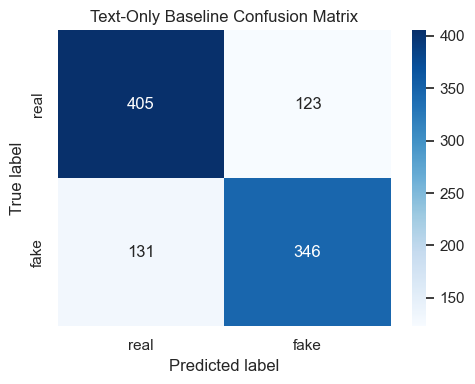

In [16]:
cm_text = confusion_matrix(y_test, text_test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Text-Only Baseline Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig('plot_10_text_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


## Legacy Multimodal Dataset Preparation

In [17]:
# Convert TF-IDF vectors to dense text embeddings for the PyTorch fusion model.
# This is a lightweight embedding representation suitable for MS1.

X_train_dense = X_train_text.astype(np.float32).toarray()
X_val_dense = X_val_text.astype(np.float32).toarray()
X_test_dense = X_test_text.astype(np.float32).toarray()

print('Text embedding dimension:', X_train_dense.shape[1])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FakeNewsMultimodalDataset(Dataset):
    """Returns a title embedding, an image tensor, label, and metadata.

    If an image is missing or unreadable, the dataset returns a neutral gray image.
    This keeps the experiment reproducible even when image coverage is incomplete.
    """
    def __init__(self, dataframe, text_features, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.text_features = text_features.astype(np.float32)
        self.transform = transform
        # Store metadata separately for later retrieval (not used in training loop)
        self.metadata = dataframe[['id', 'title', 'label', 'source']].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def _load_image(self, path_value):
        if isinstance(path_value, str) and path_value.strip() and Path(path_value).exists():
            try:
                return Image.open(path_value).convert('RGB')
            except Exception:
                pass
        return Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row.get('image_path_primary', np.nan))
        img = self.transform(img)
        text_vec = torch.tensor(self.text_features[idx], dtype=torch.float32)
        label = torch.tensor(int(row['label_id']), dtype=torch.long)
        # Return only tensor data; metadata is stored separately
        return {
            'text': text_vec,
            'image': img,
            'label': label,
        }

train_dataset = FakeNewsMultimodalDataset(train_df, X_train_dense, train_transform)
val_dataset = FakeNewsMultimodalDataset(val_df, X_val_dense, eval_transform)
test_dataset = FakeNewsMultimodalDataset(test_df, X_test_dense, eval_transform)

class_counts = np.bincount(y_train, minlength=2)
class_weights_np = len(y_train) / (2 * np.maximum(class_counts, 1))
sample_weights = class_weights_np[y_train]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Class counts:', dict(zip(['real', 'fake'], class_counts.tolist())))
print('Class weights:', class_weights_np.round(3).tolist())
print('Batches:', {'train': len(train_loader), 'val': len(val_loader), 'test': len(test_loader)})

Text embedding dimension: 512
Class counts: {'real': 4498, 'fake': 4345}
Class weights: [0.983, 1.018]
Batches: {'train': 553, 'val': 64, 'test': 63}


## Legacy CNN + Text Fusion Model

In [18]:
class SmallCNNEncoder(nn.Module):
    """A lightweight CNN image encoder suitable for a small MS1 dataset."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.proj(x)


class ConsistencyFusionNet(nn.Module):
    """Fuse text and image features using explicit cross-modal consistency terms.

    The model projects image and text into the same latent dimension, then uses:
    - text vector
    - image vector
    - absolute difference |text - image|
    - element-wise product text * image

    The difference and product terms encourage the classifier to learn agreement or
    mismatch between the headline/text representation and the visual representation.
    """
    def __init__(self, text_dim, latent_dim=128, num_classes=2, dropout=0.35):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.image_encoder = SmallCNNEncoder(out_dim=latent_dim)
        self.image_proj = nn.Sequential(
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        fusion_dim = latent_dim * 4
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, text, image):
        text_z = self.text_proj(text)
        image_z = self.image_proj(self.image_encoder(image))
        diff = torch.abs(text_z - image_z)
        prod = text_z * image_z
        fused = torch.cat([text_z, image_z, diff, prod], dim=1)
        return self.classifier(fused)

model = ConsistencyFusionNet(text_dim=X_train_dense.shape[1]).to(DEVICE)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {trainable_params:,}')


ConsistencyFusionNet(
  (text_proj): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
  )
  (image_encoder): SmallCNNEncoder(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2

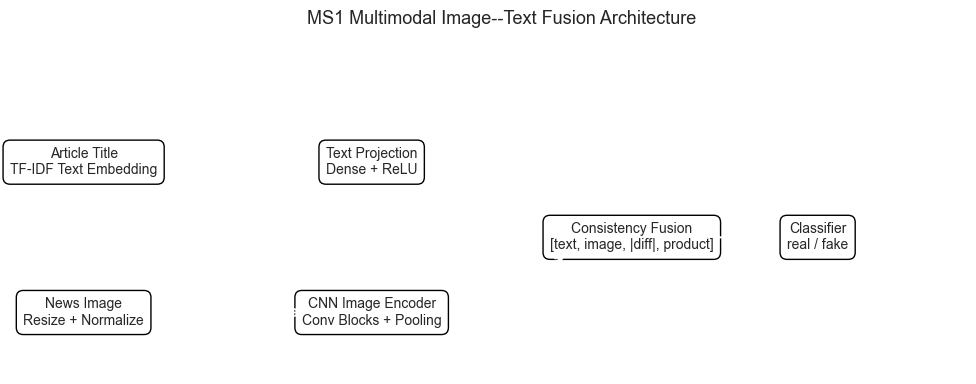

In [19]:
# Architecture diagram for the Methodology section of the report.
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
boxes = [
    (0.05, 0.62, 'Article Title\nTF-IDF Text Embedding'),
    (0.05, 0.18, 'News Image\nResize + Normalize'),
    (0.36, 0.62, 'Text Projection\nDense + ReLU'),
    (0.36, 0.18, 'CNN Image Encoder\nConv Blocks + Pooling'),
    (0.64, 0.40, 'Consistency Fusion\n[text, image, |diff|, product]'),
    (0.84, 0.40, 'Classifier\nreal / fake'),
]
for x, y, label in boxes:
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black'))

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.5))
arrow(0.18, 0.62, 0.29, 0.62)
arrow(0.18, 0.18, 0.29, 0.18)
arrow(0.48, 0.62, 0.57, 0.47)
arrow(0.48, 0.18, 0.57, 0.35)
arrow(0.73, 0.40, 0.79, 0.40)
ax.set_title('MS1 Multimodal Image--Text Fusion Architecture', fontsize=13)
plt.tight_layout()
plt.savefig('plot_11_model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


## Legacy Training Loop

In [20]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


def run_epoch(model, dataloader, criterion=None, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, all_preds, all_labels, all_probs = [], [], [], []

    for batch in dataloader:
        text = batch['text'].to(DEVICE)
        image = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(text, image)
            loss = criterion(logits, labels) if criterion is not None else None
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        if loss is not None:
            losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.max(dim=1).values.detach().cpu().numpy().tolist())

    metrics = {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'accuracy': accuracy_score(all_labels, all_preds),
        'macro_f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    return metrics, np.array(all_preds), np.array(all_labels), np.array(all_probs)

history = []
best_val_f1 = -1.0  # Initialize as float
best_epoch = 0
patience_counter = 0
best_path = Path('best_ms1_multimodal_model.pt')

if RUN_MULTIMODAL_TRAINING:
    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics, _, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_metrics['macro_f1'])

        row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
        history.append(row)
        print(f"Epoch {epoch:02d} | train loss={train_metrics['loss']:.4f}, train F1={train_metrics['macro_f1']:.3f} | val F1={val_metrics['macro_f1']:.3f}, val acc={val_metrics['accuracy']:.3f}")

        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'text_dim': X_train_dense.shape[1],
                'vectorizer_vocabulary': vectorizer.vocabulary_,
                'label_to_id': LABEL_TO_ID,
                'config': {
                    'image_size': IMAGE_SIZE,
                    'max_text_features': MAX_TEXT_FEATURES,
                    'latent_dim': 128,
                }
            }, best_path)
            print('  saved best model')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                break
else:
    print('RUN_MULTIMODAL_TRAINING=False. Skipping neural model training.')

history_df = pd.DataFrame(history)
if not history_df.empty:
    display(history_df)
    history_df.to_csv('ms1_training_history.csv', index=False)

Epoch 01 | train loss=0.5679, train F1=0.701 | val F1=0.732, val acc=0.733
  saved best model
Epoch 02 | train loss=0.5113, train F1=0.753 | val F1=0.709, val acc=0.709
Epoch 03 | train loss=0.4875, train F1=0.769 | val F1=0.739, val acc=0.741
  saved best model
Epoch 04 | train loss=0.4705, train F1=0.785 | val F1=0.717, val acc=0.718
Epoch 05 | train loss=0.4571, train F1=0.779 | val F1=0.733, val acc=0.734
Epoch 06 | train loss=0.4473, train F1=0.788 | val F1=0.735, val acc=0.735
Epoch 07 | train loss=0.4166, train F1=0.804 | val F1=0.733, val acc=0.734
Early stopping at epoch 7. Best epoch: 3


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,1,0.567889,0.701006,0.700650,0.546930,0.733268,0.731727
1,2,0.511279,0.753364,0.753267,0.559296,0.708661,0.708651
2,3,0.487460,0.768970,0.768896,0.552721,0.741142,0.738558
3,4,0.470492,0.785254,0.784921,0.558427,0.717520,0.716861
4,5,0.457087,0.779260,0.779168,0.538961,0.734252,0.733126
5,6,0.447289,0.788081,0.787805,0.565923,0.735236,0.734846
6,7,0.416632,0.804139,0.804118,0.575531,0.734252,0.733126


## Legacy Model Evaluation

In [21]:
if best_path.exists():
    checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded best model from {best_path}')
else:
    print('No saved multimodal checkpoint found. Using current model weights.')

mm_test_metrics, mm_test_pred, mm_test_labels, mm_test_conf = run_epoch(model, test_loader, criterion=None, optimizer=None)
print('Multimodal test metrics:')
for k, v in mm_test_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

print('\nMultimodal test classification report:')
print(classification_report(mm_test_labels, mm_test_pred, target_names=['real', 'fake'], zero_division=0))

mm_predictions_df = test_df[['id', 'source', 'title', 'label', 'image_path_primary', 'valid_image_path']].copy()
mm_predictions_df['mm_pred_label'] = [ID_TO_LABEL[i] for i in mm_test_pred]
mm_predictions_df['mm_confidence'] = mm_test_conf
mm_predictions_df['mm_correct'] = mm_predictions_df['label'].eq(mm_predictions_df['mm_pred_label'])
mm_predictions_df.to_csv('ms1_multimodal_test_predictions.csv', index=False)

display(mm_predictions_df.head())

Loaded best model from best_ms1_multimodal_model.pt
Multimodal test metrics:
  loss: nan
  accuracy: 0.7423
  macro_f1: 0.7390

Multimodal test classification report:
              precision    recall  f1-score   support

        real       0.73      0.81      0.77       528
        fake       0.76      0.66      0.71       477

    accuracy                           0.74      1005
   macro avg       0.75      0.74      0.74      1005
weighted avg       0.74      0.74      0.74      1005



,id,source,title,label,image_path_primary,valid_image_path,mm_pred_label,mm_confidence,mm_correct
0,gossipcop-921650,gossipcop,Megan Fox gets emotional on Hollywood Medium,real,images\test\gossipcop-921650_0_cc9c873a42.jpg,True,real,0.764489,True
1,gossipcop-2502492072,gossipcop,Kylie Jenner: Why She’s Crying Herself To Sleep Over Delivery Room Drama,fake,NaN,False,real,0.520211,False
2,gossipcop-3349415808,gossipcop,8 Juiciest Celebrity Feuds of 2017,fake,images\test\gossipcop-3349415808_0_ff69e4cb8f.jpg,True,fake,0.597599,True
3,gossipcop-943749,gossipcop,2018 MTV Movie and TV Awards: Complete List of Winners,real,images\test\gossipcop-943749_0_8ba5405211.jpg,True,real,0.837209,True
4,gossipcop-7661930332,gossipcop,Angela Kardashian Angela Kardashian,fake,NaN,False,fake,0.560750,True


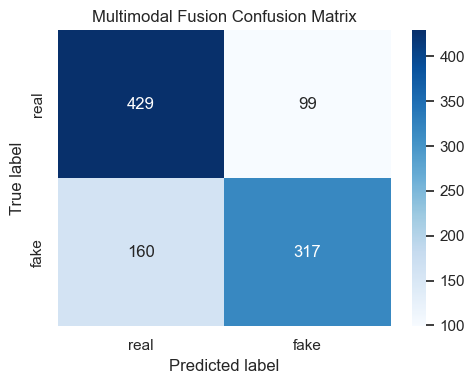

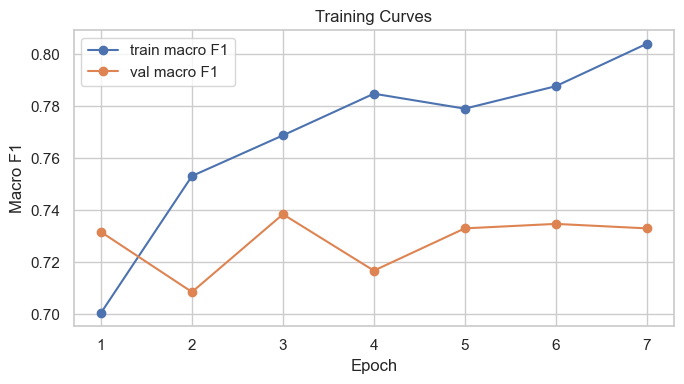

In [22]:
cm_mm = confusion_matrix(mm_test_labels, mm_test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_mm, annot=True, fmt='d', cmap='Blues', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Multimodal Fusion Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig('plot_12_multimodal_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

if not history_df.empty:
    plt.figure(figsize=(7, 4))
    plt.plot(history_df['epoch'], history_df['train_macro_f1'], marker='o', label='train macro F1')
    plt.plot(history_df['epoch'], history_df['val_macro_f1'], marker='o', label='val macro F1')
    plt.title('Training Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.legend()
    plt.tight_layout()
    plt.savefig('plot_13_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


In [23]:
results_summary = pd.DataFrame([
    {
        'model': 'Text-only TF-IDF + Logistic Regression',
        'val_accuracy': text_metrics['val_accuracy'],
        'val_macro_f1': text_metrics['val_macro_f1'],
        'test_accuracy': text_metrics['test_accuracy'],
        'test_macro_f1': text_metrics['test_macro_f1'],
        'notes': 'Baseline required by project deliverables',
    },
    {
        'model': 'Multimodal CNN + Text Embedding Consistency Fusion',
        'val_accuracy': history_df['val_accuracy'].max() if not history_df.empty else np.nan,
        'val_macro_f1': history_df['val_macro_f1'].max() if not history_df.empty else np.nan,
        'test_accuracy': mm_test_metrics['accuracy'],
        'test_macro_f1': mm_test_metrics['macro_f1'],
        'notes': 'Uses image features, text embeddings, |difference|, and product fusion terms',
    },
])

results_summary.to_csv('ms1_results_summary.csv', index=False)
display(results_summary)

if results_summary.loc[1, 'test_macro_f1'] >= results_summary.loc[0, 'test_macro_f1']:
    print('The multimodal model matches or improves on the text-only baseline on test macro F1.')
else:
    print('The text-only baseline is stronger in this run; report this honestly and discuss limited image coverage / small data as likely reasons.')


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,notes
0,Text-only TF-IDF + Logistic Regression,0.741142,0.739723,0.747264,0.746390,Baseline required by project deliverables
1,Multimodal CNN + Text Embedding Consistency Fusion,0.741142,0.738558,0.742289,0.739048,"Uses image features, text embeddings, |difference|, and product fusion terms"


The text-only baseline is stronger in this run; report this honestly and discuss limited image coverage / small data as likely reasons.


## Legacy Qualitative Failure Analysis

In [24]:
# Required by the project: qualitative analysis of failure cases.
# We save all mistakes and display the most confident mistakes.

errors_df = mm_predictions_df[~mm_predictions_df['mm_correct']].copy()
errors_df = errors_df.sort_values('mm_confidence', ascending=False)
errors_df.to_csv('ms1_failure_cases.csv', index=False)

print(f'Multimodal errors: {len(errors_df)} out of {len(mm_predictions_df)} test samples')
if len(errors_df):
    display(errors_df[['id', 'source', 'title', 'label', 'mm_pred_label', 'mm_confidence', 'valid_image_path']].head(10))
else:
    print('No test errors in this run. Displaying lowest-confidence correct cases instead.')
    display(mm_predictions_df.sort_values('mm_confidence').head(10)[['id', 'source', 'title', 'label', 'mm_pred_label', 'mm_confidence', 'valid_image_path']])


Multimodal errors: 259 out of 1005 test samples


,id,source,title,label,mm_pred_label,mm_confidence,valid_image_path
476,gossipcop-2656814899,gossipcop,Met Gala 2018: Madonna snacks while getting glammed up,fake,real,0.983290,True
897,gossipcop-921537,gossipcop,Selena Gomez Brings a Ukulele and a Bikini to Australia–but Not Justin Bieber,real,fake,0.981251,False
594,gossipcop-7259603960,gossipcop,Affordable Fashion & Style Blog,fake,real,0.980756,False
950,gossipcop-6345761457,gossipcop,Celebrities pay tribute to Mary Tyler Moore,fake,real,0.978209,True
177,gossipcop-2932564057,gossipcop,"VIDEO: Fifth Harmony Perform, Play 'Flinch' on LATE LATE SHOW Video",fake,real,0.977875,True
107,gossipcop-8092575981,gossipcop,The Bachelorette: Becca 'Frustrated' That Tia Still Has Feelings for Colton,fake,real,0.976228,True
816,gossipcop-9131837077,gossipcop,"Get a grip teenagers! You've got a few GCSEs not a role on Netflix, says LIZ JONES",fake,real,0.973622,True
775,gossipcop-3623255149,gossipcop,UPDATE: Steven Tyler Denies Seizure Reports,fake,real,0.972046,True
768,gossipcop-9093685718,gossipcop,Vito Schnabel Shares His Heartbreak Over Heidi Klum Split,fake,real,0.964386,True
944,gossipcop-952215,gossipcop,Blake Shelton Falls on Stage and It May Just Be Pitbull's Fault,real,fake,0.961011,False


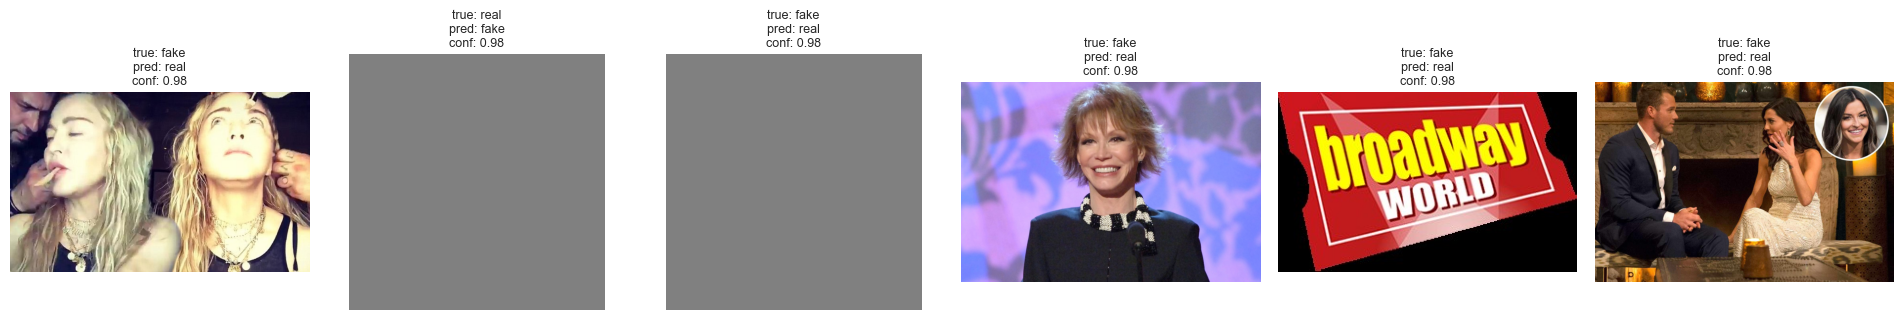

In [25]:
def show_failure_images(df, max_cases=6):
    subset = df.head(max_cases)
    if subset.empty:
        return
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        path = row.get('image_path_primary', '')
        if isinstance(path, str) and Path(path).exists():
            img = Image.open(path).convert('RGB')
        else:
            img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
        ax.imshow(img)
        ax.axis('off')
        title = f"true: {row['label']}\npred: {row['mm_pred_label']}\nconf: {row['mm_confidence']:.2f}"
        ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.savefig('plot_14_failure_cases.png', dpi=150, bbox_inches='tight')
    plt.show()

if len(errors_df):
    show_failure_images(errors_df, max_cases=6)
else:
    show_failure_images(mm_predictions_df.sort_values('mm_confidence').head(6), max_cases=6)


### How to Discuss Failure Cases in the Report

Use the saved `ms1_failure_cases.csv` file and the displayed examples above. Common explanations to check manually:

- The image is generic, low quality, or missing, so the model cannot verify the claim visually.
- The title is short or ambiguous, so the text representation is weak.
- The image looks semantically related to the title, but the article is labeled fake because of factual details not visible in the image.
- The model may learn domain/source artifacts because FakeNewsNet contains strong source and domain bias.
- Limited image coverage can make the multimodal model behave similarly to a text-only model.


## Legacy Summary

In [26]:
print('=' * 80)
print('MS1 EXPERIMENT SUMMARY')
print('=' * 80)
print('\nDataset:')
for _, row in audit_df.iterrows():
    print(f"  {row['split']}: n={row['n_rows']}, fake={row['fake']}, real={row['real']}, valid images={row['valid_images']} ({row['image_coverage_%']}%)")

print('\nModels implemented:')
print('  1. Text-only baseline: TF-IDF title embeddings + Logistic Regression')
print('  2. Multimodal model: CNN image encoder + text embeddings + consistency fusion')

print('\nMain comparison:')
for _, row in results_summary.iterrows():
    print(f"  {row['model']}: test accuracy={row['test_accuracy']:.3f}, test macro F1={row['test_macro_f1']:.3f}")

print('\nSaved outputs:')
for path in [
    'ms1_dataset_audit.csv',
    'ms1_text_only_test_predictions.csv',
    'ms1_multimodal_test_predictions.csv',
    'ms1_results_summary.csv',
    'ms1_failure_cases.csv',
    'best_ms1_multimodal_model.pt',
    'plot_10_text_baseline_confusion.png',
    'plot_11_model_architecture.png',
    'plot_12_multimodal_confusion.png',
    'plot_13_training_curves.png',
    'plot_14_failure_cases.png',
]:
    if Path(path).exists():
        print(' ', path)

print('\nPlanned improvements after MS1:')
print('  - Increase the number of valid downloaded images.')
print('  - Replace TF-IDF with transformer embeddings if GPU/time allow.')
print('  - Add ablations: image-only, text-only, early fusion, late fusion.')
print('  - Perform deeper manual annotation of image-text consistency examples.')
print('=' * 80)


MS1 EXPERIMENT SUMMARY

Dataset:
  train: n=8843, fake=4345, real=4498, valid images=4553 (51.49%)
  val: n=1016, fake=477, real=539, valid images=540 (53.15%)
  test: n=1005, fake=477, real=528, valid images=514 (51.14%)

Models implemented:
  1. Text-only baseline: TF-IDF title embeddings + Logistic Regression
  2. Multimodal model: CNN image encoder + text embeddings + consistency fusion

Main comparison:
  Text-only TF-IDF + Logistic Regression: test accuracy=0.747, test macro F1=0.746
  Multimodal CNN + Text Embedding Consistency Fusion: test accuracy=0.742, test macro F1=0.739

Saved outputs:
  ms1_dataset_audit.csv
  ms1_text_only_test_predictions.csv
  ms1_multimodal_test_predictions.csv
  ms1_results_summary.csv
  ms1_failure_cases.csv
  best_ms1_multimodal_model.pt
  plot_10_text_baseline_confusion.png
  plot_11_model_architecture.png
  plot_12_multimodal_confusion.png
  plot_13_training_curves.png
  plot_14_failure_cases.png

Planned improvements after MS1:
  - Increase the 

---
# Part II - Final Senior Workflow

This is the report-grade section. It uses de-leaked, valid-image-aware splits; audits hidden leakage; compares strong text baselines, optional DistilBERT, optional CLIP image-text alignment, and multimodal ablations; then produces confidence intervals, McNemar tests, per-source metrics, and report tables.

Recommended execution order for final results: run from `FINAL UPGRADE 03-A` through `FINAL UPGRADE 03-L` top-to-bottom.


In [27]:
# FINAL UPGRADE 03-A: Global final experiment configuration
from pathlib import Path
import os, json, math, random, time
import numpy as np
import pandas as pd

FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_SPLIT_DIR = Path('data_splits')

RUN_FINAL_DEEP_TRAINING = True
FINAL_EPOCHS = 80
FINAL_SEEDS = [42, 123, 2026]
VALID_IMAGE_ONLY_EVAL = True
USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS = True  # Avoid placeholder-image confounding for headline multimodal results.
USE_IMAGE_DELEAKED_SPLITS = True  # After the image hash audit, reload splits with prior-split image duplicates removed.
RUN_OPTIONAL_BERT_TEXT_BASELINE = True  # Runs only when transformers is installed and model weights are available.
RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE = True  # Tests image-text semantic agreement when CLIP weights are available.
INCLUDE_LEGACY_ROOT_TRIALS_IN_REPORT_TABLE = False  # Keep old pre-cleaning root trials out of headline tables by default.
RUN_RESNET50_FROZEN = True
FINAL_EARLY_STOPPING_PATIENCE = 3
FINAL_MIN_DELTA = 1e-4
FINAL_CNN_LR = 1e-3
FINAL_PRETRAINED_HEAD_LR = 1e-4
FINAL_WEIGHT_DECAY = 1e-4
FINAL_LABEL_SMOOTHING = 0.05
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
CLIP_BATCH_SIZE = 24
CLIP_MAX_TEXT_TOKENS = 77
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {0: 'real', 1: 'fake'}

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

set_all_seeds(42)
print('Final experiment configuration saved.')
if USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS:
    print('Final deep/text comparisons will prefer data_splits/*_valid_images_only.csv when available.')
print(f'Early stopping: patience={FINAL_EARLY_STOPPING_PATIENCE}, min_delta={FINAL_MIN_DELTA}')

Final experiment configuration saved.
Final deep/text comparisons will prefer data_splits/*_valid_images_only.csv when available.
Early stopping: patience=3, min_delta=0.0001


In [28]:
# FINAL UPGRADE 03-B: Robust split loading and validation
from pathlib import Path
import pandas as pd, numpy as np

def load_final_split(split, valid_only=False):
    candidates = []
    if valid_only:
        candidates.append(DATA_SPLIT_DIR/f'{split}_valid_images_only_image_deleaked_with_content.csv')
        candidates.append(DATA_SPLIT_DIR/f'{split}_valid_images_only_image_deleaked.csv')
        candidates.append(DATA_SPLIT_DIR/f'{split}_valid_images_only_with_content.csv')
        candidates.append(DATA_SPLIT_DIR/f'{split}_valid_images_only.csv')
    candidates += [DATA_SPLIT_DIR/f'{split}_multimodal.csv', DATA_SPLIT_DIR/f'{split}.csv']
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            df['split'] = split
            if 'label_id' not in df.columns:
                df['label_id'] = df['label'].map(LABEL_TO_ID)
            if 'valid_image_path' not in df.columns:
                def _exists(x):
                    return isinstance(x, str) and Path(x).exists()
                path_col = 'image_path_primary' if 'image_path_primary' in df.columns else 'image_path' if 'image_path' in df.columns else None
                df['valid_image_path'] = df[path_col].apply(_exists) if path_col else False
            if valid_only:
                df = df[df['valid_image_path'].astype(bool)].reset_index(drop=True)
            return df
    raise FileNotFoundError(f'No file found for split={split}, valid_only={valid_only}; looked at {candidates}')

train_final = load_final_split('train', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)
val_final = load_final_split('val', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)
test_final = load_final_split('test', valid_only=USE_VALID_IMAGE_ONLY_FOR_FINAL_MODELS)

split_audit_final = pd.concat([train_final, val_final, test_final]).groupby('split').agg(
    n_rows=('id','size'), fake=('label', lambda s: int((s=='fake').sum())), real=('label', lambda s: int((s=='real').sum())),
    valid_images=('valid_image_path', lambda s: int(pd.Series(s).astype(bool).sum()))
).reset_index()
split_audit_final['image_coverage_%'] = (100*split_audit_final['valid_images']/split_audit_final['n_rows']).round(2)
split_audit_final.to_csv(FINAL_ARTIFACT_DIR/'final_training_split_audit.csv', index=False)
display(split_audit_final)


,split,n_rows,fake,real,valid_images,image_coverage_%
0,test,518,230,288,518,100.0
1,train,4829,2320,2509,4829,100.0
2,val,541,250,291,541,100.0


In [29]:
# FINAL UPGRADE 03-B2: Image-content leakage audit across splits
# ID/title leakage can be clean while the same downloaded image still appears in more than one split.
# This hashes the actual image bytes and reports cross-split reuse before any final model claims.
import hashlib


def _primary_image_path(row):
    for col in ['image_path_primary', 'image_path']:
        if col in row.index and isinstance(row[col], str) and len(row[col]) > 0:
            return row[col]
    return ''


def _sha256_file(path_value, chunk_size=1024 * 1024):
    if not isinstance(path_value, str) or not Path(path_value).exists():
        return None
    h = hashlib.sha256()
    with open(path_value, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

image_hash_rows = []
for split_name, split_df in [('train', train_final), ('val', val_final), ('test', test_final)]:
    for _, row in split_df.iterrows():
        p = _primary_image_path(row)
        image_hash_rows.append({
            'split': split_name,
            'id': row.get('id', ''),
            'label': row.get('label', ''),
            'source': row.get('source', ''),
            'image_path': p,
            'image_sha256': _sha256_file(p),
        })

image_hash_df = pd.DataFrame(image_hash_rows)
image_hash_df.to_csv(FINAL_ARTIFACT_DIR/'final_image_hash_manifest.csv', index=False)

cross_split_rows = []
for image_hash, group in image_hash_df.dropna(subset=['image_sha256']).groupby('image_sha256'):
    splits = sorted(group['split'].unique().tolist())
    if len(splits) <= 1:
        continue
    cross_split_rows.append({
        'image_sha256': image_hash,
        'splits': '|'.join(splits),
        'n_rows': len(group),
        'n_unique_ids': group['id'].nunique(),
        'labels': '|'.join(sorted(group['label'].astype(str).unique().tolist())),
        'sources': '|'.join(sorted(group['source'].astype(str).unique().tolist())),
        'example_ids': json.dumps(group['id'].astype(str).head(10).tolist()),
        'example_paths': json.dumps(group['image_path'].astype(str).head(5).tolist()),
    })

image_content_leakage = pd.DataFrame(cross_split_rows).sort_values(['n_rows', 'image_sha256'], ascending=[False, True]) if cross_split_rows else pd.DataFrame(columns=['image_sha256','splits','n_rows','n_unique_ids','labels','sources','example_ids','example_paths'])
image_content_leakage.to_csv(FINAL_ARTIFACT_DIR/'final_image_content_leakage_audit.csv', index=False)

pair_rows = []
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    hashes_a = set(image_hash_df.loc[image_hash_df['split'].eq(a), 'image_sha256'].dropna())
    hashes_b = set(image_hash_df.loc[image_hash_df['split'].eq(b), 'image_sha256'].dropna())
    overlap = hashes_a & hashes_b
    pair_rows.append({'split_pair': f'{a}-{b}', 'n_overlapping_image_hashes': len(overlap), 'overlap_%_of_smaller_split': round(100 * len(overlap) / max(1, min(len(hashes_a), len(hashes_b))), 3)})
image_leakage_pair_summary = pd.DataFrame(pair_rows)
image_leakage_pair_summary.to_csv(FINAL_ARTIFACT_DIR/'final_image_content_leakage_pair_summary.csv', index=False)

display(image_leakage_pair_summary)
if len(image_content_leakage):
    print('WARNING: repeated image content appears across splits. Review examples before trusting multimodal gains.')
    display(image_content_leakage.head(20))
else:
    print('No cross-split image-content leakage detected by SHA-256 hash.')
# Build cleaned split files by removing validation/test rows whose image content appeared in an earlier split.
# Train remains unchanged; validation is filtered against train; test is filtered against train plus cleaned validation.
def _attach_hashes(df, split_name):
    # Safe to rerun after loading already-audited/de-leaked split files.
    out = df.copy()
    if 'split' not in out.columns:
        out['split'] = split_name
    else:
        out['split'] = out['split'].fillna(split_name).astype(str)

    existing_hash = (
        out['image_sha256'].reset_index(drop=True)
        if 'image_sha256' in out.columns
        else pd.Series([pd.NA] * len(out))
    )
    out = out.drop(columns=['image_sha256'], errors='ignore')

    hash_lookup = (
        image_hash_df[['split', 'id', 'image_sha256']]
        .drop_duplicates(subset=['split', 'id'])
        .copy()
    )
    out = out.merge(hash_lookup, on=['split', 'id'], how='left').reset_index(drop=True)
    if 'image_sha256' not in out.columns:
        out['image_sha256'] = pd.NA
    out['image_sha256'] = out['image_sha256'].combine_first(existing_hash)
    return out

if USE_IMAGE_DELEAKED_SPLITS:
    train_deleaked = _attach_hashes(train_final.copy(), 'train')
    val_with_hash = _attach_hashes(val_final.copy(), 'val')
    test_with_hash = _attach_hashes(test_final.copy(), 'test')

    train_hashes = set(train_deleaked['image_sha256'].dropna())
    val_keep_mask = ~val_with_hash['image_sha256'].isin(train_hashes)
    val_deleaked = val_with_hash[val_keep_mask].reset_index(drop=True)
    removed_val_image_leakage = val_with_hash[~val_keep_mask].reset_index(drop=True)

    prior_hashes_for_test = train_hashes | set(val_deleaked['image_sha256'].dropna())
    test_keep_mask = ~test_with_hash['image_sha256'].isin(prior_hashes_for_test)
    test_deleaked = test_with_hash[test_keep_mask].reset_index(drop=True)
    removed_test_image_leakage = test_with_hash[~test_keep_mask].reset_index(drop=True)

    train_deleaked.to_csv(DATA_SPLIT_DIR/'train_valid_images_only_image_deleaked.csv', index=False)
    val_deleaked.to_csv(DATA_SPLIT_DIR/'val_valid_images_only_image_deleaked.csv', index=False)
    test_deleaked.to_csv(DATA_SPLIT_DIR/'test_valid_images_only_image_deleaked.csv', index=False)
    removed_val_image_leakage.to_csv(FINAL_ARTIFACT_DIR/'removed_val_image_leakage_rows.csv', index=False)
    removed_test_image_leakage.to_csv(FINAL_ARTIFACT_DIR/'removed_test_image_leakage_rows.csv', index=False)

    image_deleakage_audit = pd.DataFrame([
        {'split':'train', 'rows_before':len(train_final), 'rows_after':len(train_deleaked), 'rows_removed_for_prior_split_image_overlap':0},
        {'split':'val', 'rows_before':len(val_final), 'rows_after':len(val_deleaked), 'rows_removed_for_prior_split_image_overlap':len(removed_val_image_leakage)},
        {'split':'test', 'rows_before':len(test_final), 'rows_after':len(test_deleaked), 'rows_removed_for_prior_split_image_overlap':len(removed_test_image_leakage)},
    ])
    image_deleakage_audit.to_csv(FINAL_ARTIFACT_DIR/'final_image_deleakage_split_filter_audit.csv', index=False)
    display(image_deleakage_audit)

    train_final, val_final, test_final = train_deleaked, val_deleaked, test_deleaked
    print('Reloaded train_final/val_final/test_final with image-deleaked valid-image-only splits for all downstream final experiments.')

,split_pair,n_overlapping_image_hashes,overlap_%_of_smaller_split
0,train-val,0,0.0
1,train-test,0,0.0
2,val-test,0,0.0


No cross-split image-content leakage detected by SHA-256 hash.


,split,rows_before,rows_after,rows_removed_for_prior_split_image_overlap
0,train,4829,4829,0
1,val,541,541,0
2,test,518,518,0


Reloaded train_final/val_final/test_final with image-deleaked valid-image-only splits for all downstream final experiments.


In [30]:
# FINAL UPGRADE 03-C: Metrics utilities, bootstrap CI, and McNemar test
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_auc_score

def compute_binary_metrics(y_true, y_pred, proba_fake=None, prefix=''):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1], zero_division=0)
    out = {
        prefix+'accuracy': accuracy_score(y_true, y_pred),
        prefix+'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        prefix+'real_precision': p[0], prefix+'real_recall': r[0], prefix+'real_f1': f1[0],
        prefix+'fake_precision': p[1], prefix+'fake_recall': r[1], prefix+'fake_f1': f1[1],
    }
    if proba_fake is not None:
        try:
            out[prefix+'roc_auc'] = roc_auc_score(y_true, proba_fake)
        except Exception:
            out[prefix+'roc_auc'] = np.nan
    return out

def bootstrap_ci_metric(y_true, y_pred, metric_fn, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))
    return float(np.mean(vals)), float(np.quantile(vals, alpha/2)), float(np.quantile(vals, 1-alpha/2))

def mcnemar_test_from_preds(y_true, pred_a, pred_b):
    # Exact binomial McNemar if scipy is available; otherwise chi-square approximation.
    y_true = np.asarray(y_true); pred_a = np.asarray(pred_a); pred_b = np.asarray(pred_b)
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    n01 = int((a_correct & ~b_correct).sum())  # A correct, B wrong
    n10 = int((~a_correct & b_correct).sum())  # A wrong, B correct
    try:
        from scipy.stats import binomtest
        p_value = binomtest(min(n01, n10), n01+n10, 0.5).pvalue if (n01+n10)>0 else 1.0
        method = 'exact_binomial'
    except Exception:
        chi2 = (abs(n01-n10)-1)**2/(n01+n10) if (n01+n10)>0 else 0.0
        p_value = math.exp(-0.5*chi2)
        method = 'approx_chi_square'
    return {'n01_A_correct_B_wrong': n01, 'n10_A_wrong_B_correct': n10, 'p_value': p_value, 'method': method}

print('Metric utilities ready.')

Metric utilities ready.


In [31]:
# FINAL UPGRADE 03-D: Final text-only baselines including majority and Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

FINAL_TEXT_INPUT_COL = next((c for c in ['text_for_model', 'content', 'title'] if c in train_final.columns), 'title')
print('Final text input column:', FINAL_TEXT_INPUT_COL)
X_train_titles = train_final[FINAL_TEXT_INPUT_COL].fillna('').astype(str)
X_val_titles = val_final[FINAL_TEXT_INPUT_COL].fillna('').astype(str)
X_test_titles = test_final[FINAL_TEXT_INPUT_COL].fillna('').astype(str)
y_train = train_final['label_id'].astype(int).values
y_val = val_final['label_id'].astype(int).values
y_test = test_final['label_id'].astype(int).values

majority = DummyClassifier(strategy='most_frequent')
majority.fit(X_train_titles, y_train)
maj_pred = majority.predict(X_test_titles)

text_lr = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95, max_features=20000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42))
])
text_lr.fit(X_train_titles, y_train)
text_val_pred = text_lr.predict(X_val_titles)
text_test_pred = text_lr.predict(X_test_titles)
text_test_prob = text_lr.predict_proba(X_test_titles)[:,1]

baseline_rows = []
baseline_rows.append({'model':'Majority baseline', **compute_binary_metrics(y_test, maj_pred)})
baseline_rows.append({'model':'Text-only TF-IDF + Logistic Regression', **compute_binary_metrics(y_test, text_test_pred, text_test_prob)})

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_baselines_results.csv', index=False)
display(baseline_results)
print('Text-only classification report:')
print(classification_report(y_test, text_test_pred, target_names=['real','fake'], zero_division=0))

Final text input column: text_for_model


,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Majority baseline,0.555985,0.357320,0.555985,1.000000,0.714640,0.000000,0.000000,0.000000,NaN
1,Text-only TF-IDF + Logistic Regression,0.762548,0.757183,0.768730,0.819444,0.793277,0.753555,0.691304,0.721088,0.841923


Text-only classification report:
              precision    recall  f1-score   support

        real       0.77      0.82      0.79       288
        fake       0.75      0.69      0.72       230

    accuracy                           0.76       518
   macro avg       0.76      0.76      0.76       518
weighted avg       0.76      0.76      0.76       518



In [32]:
# FINAL UPGRADE 03-D2:  pretrained text baseline (DistilBERT)
# This is intentionally optional so the notebook remains runnable in offline environments.
bert_results = pd.DataFrame()
if RUN_OPTIONAL_BERT_TEXT_BASELINE:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        from torch.optim import AdamW

        BERT_MODEL_NAME = 'distilbert-base-uncased'
        BERT_MAX_LENGTH = 96
        BERT_BATCH_SIZE = 16
        BERT_EPOCHS = 10
        BERT_LR = 2e-5
        DEVICE_BERT = 'cuda' if torch.cuda.is_available() else 'cpu'

        tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

        class TitleDataset(Dataset):
            def __init__(self, texts, labels):
                self.texts = list(texts)
                self.labels = np.asarray(labels, dtype=np.int64)
            def __len__(self): return len(self.texts)
            def __getitem__(self, idx):
                enc = tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=BERT_MAX_LENGTH, return_tensors='pt')
                return {k: v.squeeze(0) for k, v in enc.items()} | {'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)}

        def bert_eval(model, loader):
            model.eval(); preds, labels, probs = [], [], []
            with torch.no_grad():
                for batch in loader:
                    y = batch.pop('labels').to(DEVICE_BERT)
                    batch = {k: v.to(DEVICE_BERT) for k, v in batch.items()}
                    out = model(**batch)
                    p_fake = torch.softmax(out.logits, dim=1)[:, 1].detach().cpu().numpy()
                    probs.extend(p_fake.tolist()); preds.extend((p_fake >= 0.5).astype(int).tolist()); labels.extend(y.cpu().numpy().tolist())
            return compute_binary_metrics(labels, preds, probs), np.array(preds), np.array(labels), np.array(probs)

        train_dl = DataLoader(TitleDataset(X_train_titles, y_train), batch_size=BERT_BATCH_SIZE, shuffle=True)
        val_dl = DataLoader(TitleDataset(X_val_titles, y_val), batch_size=BERT_BATCH_SIZE, shuffle=False)
        test_dl = DataLoader(TitleDataset(X_test_titles, y_test), batch_size=BERT_BATCH_SIZE, shuffle=False)
        bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(DEVICE_BERT)
        bert_optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=FINAL_WEIGHT_DECAY)

        best_state, best_val, best_epoch, stale = None, -1.0, 0, 0
        bert_history = []
        for epoch in range(1, BERT_EPOCHS + 1):
            bert_model.train()
            for batch in train_dl:
                y = batch.pop('labels').to(DEVICE_BERT)
                batch = {k: v.to(DEVICE_BERT) for k, v in batch.items()}
                bert_optimizer.zero_grad()
                out = bert_model(**batch, labels=y)
                out.loss.backward()
                torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
                bert_optimizer.step()
            val_metrics, *_ = bert_eval(bert_model, val_dl)
            bert_history.append({'epoch': epoch, 'val_macro_f1': val_metrics['macro_f1'], 'val_accuracy': val_metrics['accuracy']})
            print(f'DistilBERT epoch={epoch}: val_f1={val_metrics["macro_f1"]:.3f}')
            if val_metrics['macro_f1'] > best_val + FINAL_MIN_DELTA:
                best_val = val_metrics['macro_f1']; best_epoch = epoch; stale = 0
                best_state = {k: v.detach().cpu().clone() for k, v in bert_model.state_dict().items()}
            else:
                stale += 1
                if stale >= FINAL_EARLY_STOPPING_PATIENCE:
                    print(f'DistilBERT early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                    break
        if best_state is not None:
            bert_model.load_state_dict(best_state)
        bert_metrics, bert_test_pred, bert_test_y, bert_test_prob = bert_eval(bert_model, test_dl)
        bert_results = pd.DataFrame([{'model': 'Text-only DistilBERT fine-tuned', 'best_epoch': best_epoch, **bert_metrics}])
        bert_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_baseline_results.csv', index=False)
        pd.DataFrame(bert_history).to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_history.csv', index=False)
        bert_pred_df = test_final[['id','source','title','label','valid_image_path']].copy()
        bert_pred_df['pred_id'] = bert_test_pred; bert_pred_df['pred_label'] = [ID_TO_LABEL[int(i)] for i in bert_test_pred]
        bert_pred_df['prob_fake'] = bert_test_prob; bert_pred_df['correct'] = bert_test_pred == bert_test_y
        bert_pred_df.to_csv(FINAL_ARTIFACT_DIR/'final_text_bert_test_predictions.csv', index=False)
        baseline_results = pd.concat([baseline_results, bert_results], ignore_index=True, sort=False)
        baseline_results.to_csv(FINAL_ARTIFACT_DIR/'final_text_baselines_results.csv', index=False)
        display(bert_results)
    except Exception as e:
        print('Optional DistilBERT baseline skipped:', repr(e))
else:
    print('DistilBERT baseline disabled by RUN_OPTIONAL_BERT_TEXT_BASELINE=False.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 21576.75it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT epoch=1: val_f1=0.724
DistilBERT epoch=2: val_f1=0.718
DistilBERT epoch=3: val_f1=0.730
DistilBERT epoch=4: val_f1=0.738
DistilBERT epoch=5: val_f1=0.717
DistilBERT epoch=6: val_f1=0.706
DistilBERT epoch=7: val_f1=0.730
DistilBERT early stopping at epoch 7. Best epoch: 4


,model,best_epoch,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Text-only DistilBERT fine-tuned,4,0.779923,0.773382,0.773585,0.854167,0.811881,0.79,0.686957,0.734884,0.838436


## FINAL UPGRADE: CLIP-Based Image-Text Inconsistency Evaluation

Because FakeNewsNet provides fake/real labels rather than direct image-text consistency labels, CLIP similarity is used as a **proxy measure** of semantic alignment between the article title and associated image. A low CLIP similarity indicates weak image-text alignment, and the corresponding inconsistency score is used to analyze whether fake articles tend to show weaker image-text consistency than real articles.

This section does **not** claim ground-truth consistency labels. It tests whether CLIP-derived image-text alignment has predictive or explanatory value for fake/real classification on the final valid-image test split.


,test_rows,valid_image_text_pairs,fake_count_valid_pairs,real_count_valid_pairs,image_coverage_%,title_column,image_column,label_column,source_column
0,518,492,223,269,94.98,title,image_path_primary,label_id,source


Loading CLIP model: openai/clip-vit-base-patch32
Device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 74364.44it/s]


,Metric,Value,Interpretation
0,Valid image-text pairs,492.000000,Report descriptive value.
1,"Mean CLIP similarity, real",0.308808,Report descriptive value.
2,"Mean CLIP similarity, fake",0.319455,Report descriptive value.
3,Gap: real minus fake,-0.010647,Positive means real articles have higher CLIP image-title alignment on average.
4,CLIP inconsistency ROC-AUC,0.436645,AUC for using 1-normalized CLIP similarity as a fake-news score; 0.5 is random.
5,CLIP inconsistency PR-AUC,0.409897,Average precision for fake class using inconsistency score.
6,Cohen's d,-0.226160,Effect size for real-vs-fake CLIP similarity difference.
7,Welch t-test p-value,0.012013,Tests whether real/fake mean CLIP similarities differ; not a consistency ground-truth test.


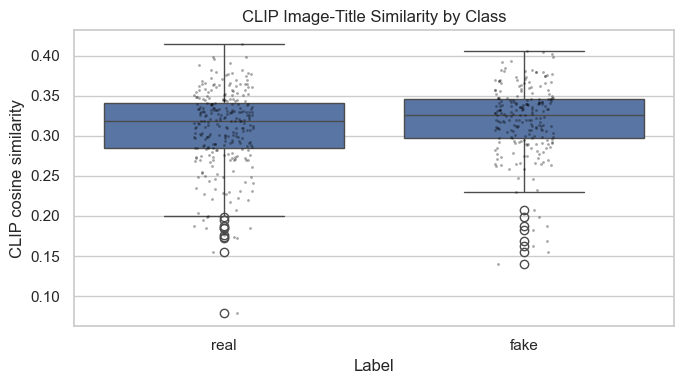

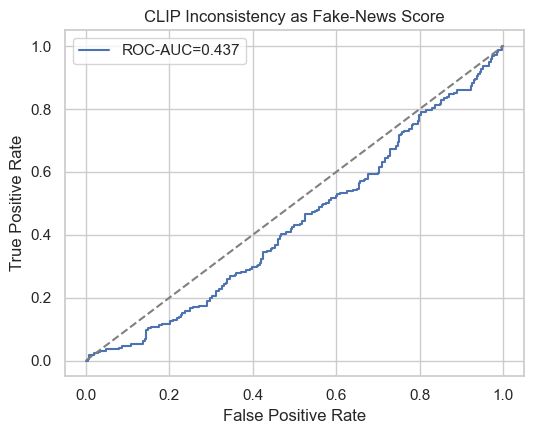

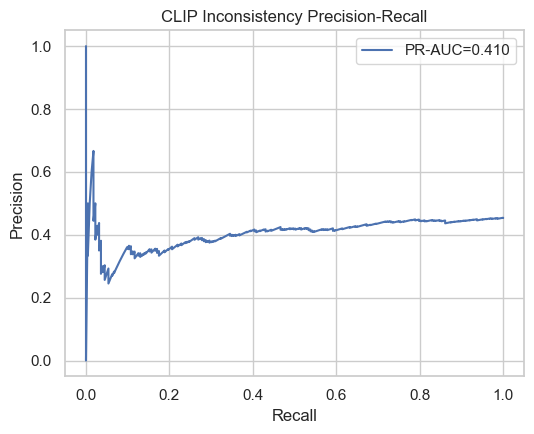

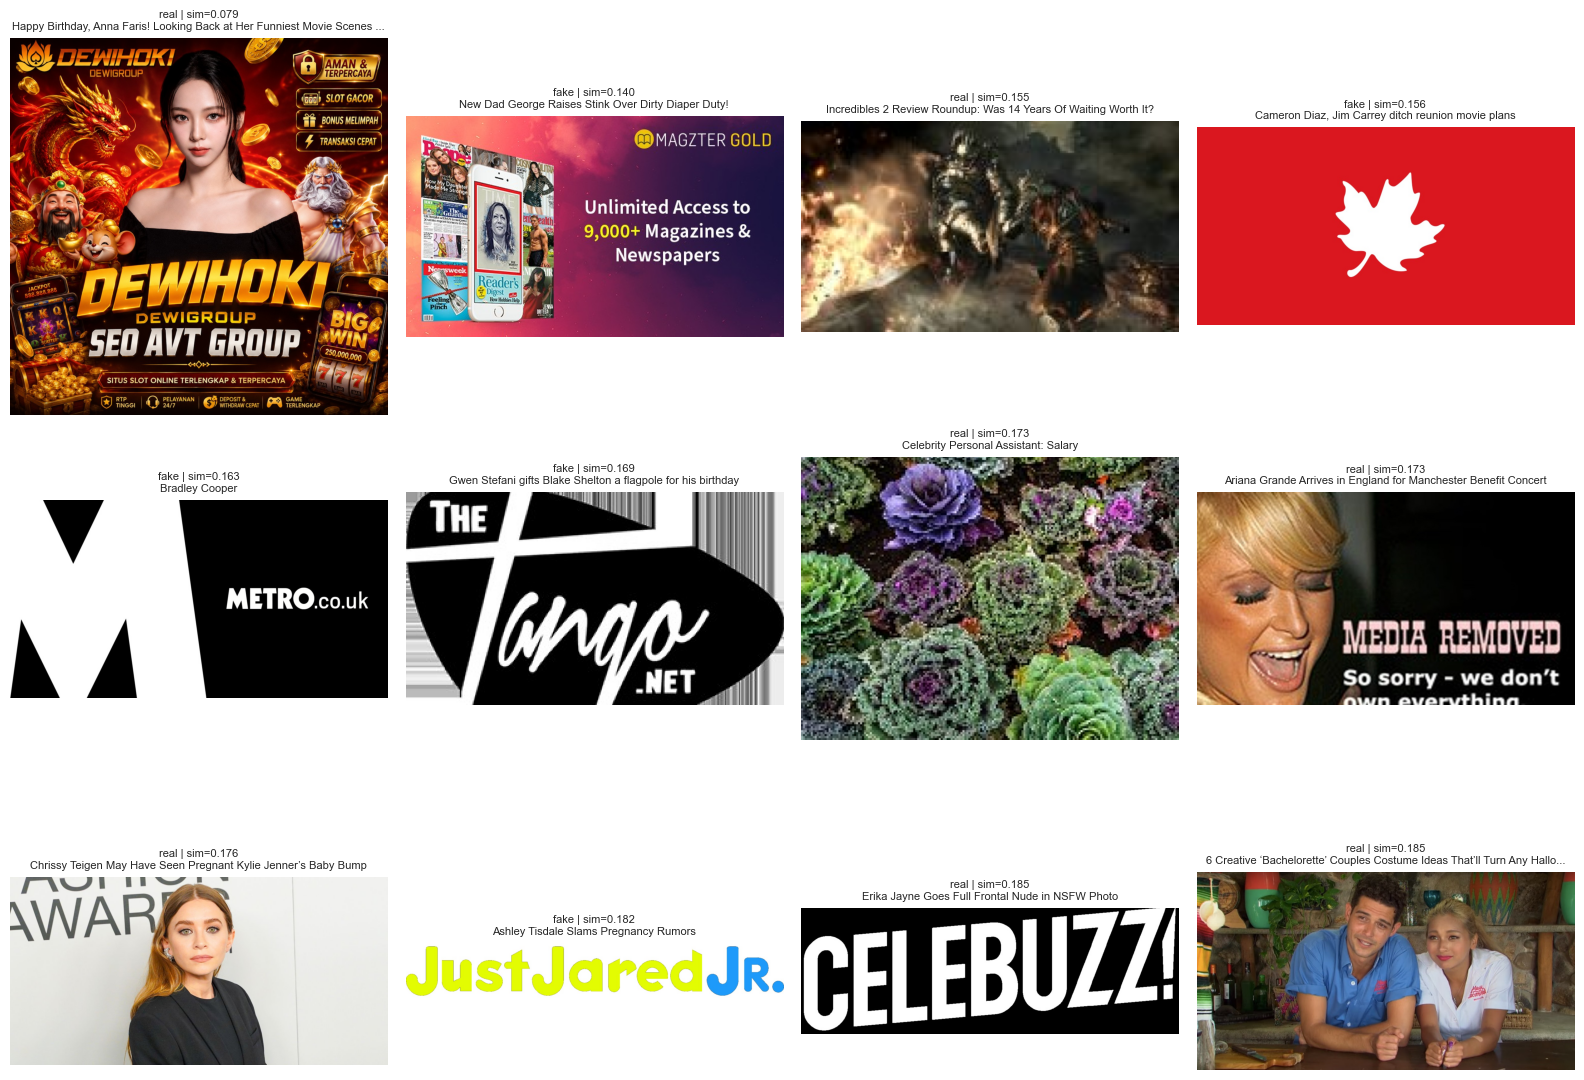

,Model,Subset,Accuracy,Macro-F1,Precision Macro,Recall Macro,ROC-AUC,PR-AUC,N
0,TF-IDF Logistic Regression,final valid-image test split,0.762548,0.757183,0.761142,0.755374,0.841923,0.832930,518
1,consistency_fusion_cnn+text_test_predictions_seed42,same CLIP valid-image subset,0.776423,0.774274,0.774507,0.774068,0.844116,0.832938,492
2,CLIP inconsistency score,same CLIP valid-image subset,NaN,NaN,NaN,NaN,0.436645,0.409897,492


In [33]:
# FINAL UPGRADE 03-D3: CLIP-based image-text inconsistency metric pipeline
# Outputs are generated only when transformers and CLIP weights are available.
clip_results = pd.DataFrame()
clip_report_table = pd.DataFrame()
clip_scores_df = pd.DataFrame()

if RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import CLIPModel, CLIPProcessor
        from PIL import Image
        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
        from scipy.stats import ttest_ind
        import matplotlib.pyplot as plt
        import seaborn as sns

        DEVICE_CLIP = 'cuda' if torch.cuda.is_available() else 'cpu'

        def _find_first_column(df, candidates):
            for col in candidates:
                if col in df.columns:
                    return col
            return None

        def _robust_label_id(value):
            if pd.isna(value):
                return np.nan
            if isinstance(value, str):
                v = value.strip().lower()
                if v in LABEL_TO_ID:
                    return LABEL_TO_ID[v]
                try:
                    return int(float(v))
                except Exception:
                    return np.nan
            try:
                return int(value)
            except Exception:
                return np.nan

        def _prepare_clip_eval_df(df):
            out = df.copy().reset_index(drop=True)
            title_col = _find_first_column(out, ['title', 'text', 'article_title'])
            image_col = _find_first_column(out, ['image_path_primary', 'image_path', 'image_path_lookup'])
            label_col = _find_first_column(out, ['label_id', 'label', 'target'])
            source_col = _find_first_column(out, ['source', 'domain'])
            id_col = _find_first_column(out, ['id', 'article_id', 'news_id'])

            if title_col is None or image_col is None or label_col is None:
                raise ValueError(f'Missing required columns. title={title_col}, image={image_col}, label={label_col}')

            out['clip_article_id'] = out[id_col].astype(str) if id_col else out.index.astype(str)
            out['clip_title'] = out[title_col].fillna('').astype(str)
            out['clip_image_path'] = out[image_col].fillna('').astype(str)
            out['clip_label_id'] = out[label_col].map(_robust_label_id) if label_col != 'label_id' else out[label_col].map(_robust_label_id)
            out['clip_label'] = out['clip_label_id'].map(ID_TO_LABEL)
            out['clip_source'] = out[source_col].fillna('unknown').astype(str) if source_col else 'unknown'
            out['clip_image_exists'] = out['clip_image_path'].apply(lambda p: isinstance(p, str) and len(p) > 0 and Path(p).exists())
            if 'valid_image_path' in out.columns:
                out['clip_valid_image_flag'] = out['valid_image_path'].astype(bool)
            else:
                out['clip_valid_image_flag'] = out['clip_image_exists']

            keep = (
                out['clip_title'].str.strip().ne('')
                & out['clip_image_exists']
                & out['clip_valid_image_flag']
                & out['clip_label_id'].isin([0, 1])
            )
            return out[keep].reset_index(drop=True)

        clip_eval_df = _prepare_clip_eval_df(test_final)
        clip_summary_input = pd.DataFrame([{
            'test_rows': len(test_final),
            'valid_image_text_pairs': len(clip_eval_df),
            'fake_count_valid_pairs': int((clip_eval_df['clip_label_id'] == 1).sum()),
            'real_count_valid_pairs': int((clip_eval_df['clip_label_id'] == 0).sum()),
            'image_coverage_%': round(100 * len(clip_eval_df) / max(1, len(test_final)), 2),
            'title_column': _find_first_column(test_final, ['title', 'text', 'article_title']),
            'image_column': _find_first_column(test_final, ['image_path_primary', 'image_path', 'image_path_lookup']),
            'label_column': _find_first_column(test_final, ['label_id', 'label', 'target']),
            'source_column': _find_first_column(test_final, ['source', 'domain']),
        }])
        clip_summary_input.to_csv(FINAL_ARTIFACT_DIR/'clip_input_subset_summary.csv', index=False)
        display(clip_summary_input)

        if len(clip_eval_df) < 2 or clip_eval_df['clip_label_id'].nunique() < 2:
            raise ValueError('CLIP evaluation needs at least two valid image-text pairs and both classes in the final test subset.')

        print('Loading CLIP model:', CLIP_MODEL_NAME)
        print('Device:', DEVICE_CLIP)
        clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE_CLIP)
        clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
        clip_model.eval()

        class ClipInconsistencyDataset(Dataset):
            def __init__(self, df):
                self.df = df.reset_index(drop=True).copy()
            def __len__(self):
                return len(self.df)
            def __getitem__(self, idx):
                row = self.df.iloc[idx]
                image = Image.open(row['clip_image_path']).convert('RGB')
                return {
                    'title': row['clip_title'],
                    'image': image,
                    'label_id': int(row['clip_label_id']),
                    'idx': idx,
                }

        def clip_collate(batch):
            enc = clip_processor(
                text=[b['title'] for b in batch],
                images=[b['image'] for b in batch],
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=CLIP_MAX_TEXT_TOKENS,
            )
            enc['labels'] = torch.tensor([b['label_id'] for b in batch], dtype=torch.long)
            enc['idxs'] = torch.tensor([b['idx'] for b in batch], dtype=torch.long)
            return enc

        loader = DataLoader(
            ClipInconsistencyDataset(clip_eval_df),
            batch_size=CLIP_BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            collate_fn=clip_collate,
        )

        all_idx, all_labels, all_similarity = [], [], []
        with torch.no_grad():
            for batch in loader:
                labels = batch.pop('labels').cpu().numpy()
                idxs = batch.pop('idxs').cpu().numpy()
                batch = {k: v.to(DEVICE_CLIP) for k, v in batch.items()}
                outputs = clip_model(**batch)
                image_features = outputs.image_embeds
                text_features = outputs.text_embeds
                image_features = image_features / image_features.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                similarity = (image_features * text_features).sum(dim=1).detach().cpu().numpy()
                all_idx.extend(idxs.tolist())
                all_labels.extend(labels.tolist())
                all_similarity.extend(similarity.tolist())

        clip_scores_df = clip_eval_df.iloc[all_idx].copy().reset_index(drop=True)
        clip_scores_df['clip_similarity'] = np.asarray(all_similarity, dtype=float)
        sim_min = float(clip_scores_df['clip_similarity'].min())
        sim_max = float(clip_scores_df['clip_similarity'].max())
        denom = max(sim_max - sim_min, 1e-12)
        clip_scores_df['clip_similarity_norm'] = (clip_scores_df['clip_similarity'] - sim_min) / denom
        clip_scores_df['clip_inconsistency_score'] = 1.0 - clip_scores_df['clip_similarity_norm']
        clip_scores_df['fake_score_label'] = clip_scores_df['clip_label_id'].astype(int)

        export_cols = [
            'clip_article_id', 'clip_title', 'clip_image_path', 'clip_label', 'clip_label_id', 'clip_source',
            'clip_similarity', 'clip_similarity_norm', 'clip_inconsistency_score'
        ]
        clip_scores_df[export_cols].to_csv(FINAL_ARTIFACT_DIR/'clip_inconsistency_test_scores.csv', index=False)

        y_clip = clip_scores_df['fake_score_label'].values
        inconsistency = clip_scores_df['clip_inconsistency_score'].values
        similarity = clip_scores_df['clip_similarity'].values
        real_sim = clip_scores_df.loc[clip_scores_df['clip_label_id'].eq(0), 'clip_similarity'].values
        fake_sim = clip_scores_df.loc[clip_scores_df['clip_label_id'].eq(1), 'clip_similarity'].values
        real_inc = clip_scores_df.loc[clip_scores_df['clip_label_id'].eq(0), 'clip_inconsistency_score'].values
        fake_inc = clip_scores_df.loc[clip_scores_df['clip_label_id'].eq(1), 'clip_inconsistency_score'].values

        clip_roc_auc = roc_auc_score(y_clip, inconsistency)
        clip_pr_auc = average_precision_score(y_clip, inconsistency)
        welch = ttest_ind(real_sim, fake_sim, equal_var=False, nan_policy='omit')
        pooled = np.sqrt(((len(real_sim)-1)*np.var(real_sim, ddof=1) + (len(fake_sim)-1)*np.var(fake_sim, ddof=1)) / max(1, len(real_sim)+len(fake_sim)-2))
        cohens_d = (float(np.mean(real_sim)) - float(np.mean(fake_sim))) / pooled if pooled > 0 else np.nan

        clip_summary = pd.DataFrame([{
            'valid_image_text_pairs': len(clip_scores_df),
            'real_count': int((y_clip == 0).sum()),
            'fake_count': int((y_clip == 1).sum()),
            'mean_clip_similarity_real': float(np.mean(real_sim)),
            'mean_clip_similarity_fake': float(np.mean(fake_sim)),
            'mean_inconsistency_real': float(np.mean(real_inc)),
            'mean_inconsistency_fake': float(np.mean(fake_inc)),
            'consistency_gap_real_minus_fake': float(np.mean(real_sim) - np.mean(fake_sim)),
            'clip_inconsistency_roc_auc': float(clip_roc_auc),
            'clip_inconsistency_pr_auc': float(clip_pr_auc),
            'welch_ttest_p_value': float(welch.pvalue),
            'cohens_d_real_minus_fake_similarity': float(cohens_d),
        }])
        clip_summary.to_csv(FINAL_ARTIFACT_DIR/'clip_inconsistency_summary.csv', index=False)

        def _interp(metric, value):
            if metric == 'Gap: real minus fake':
                return 'Positive means real articles have higher CLIP image-title alignment on average.'
            if metric == 'CLIP inconsistency ROC-AUC':
                return 'AUC for using 1-normalized CLIP similarity as a fake-news score; 0.5 is random.'
            if metric == 'CLIP inconsistency PR-AUC':
                return 'Average precision for fake class using inconsistency score.'
            if metric == "Cohen's d":
                return 'Effect size for real-vs-fake CLIP similarity difference.'
            if metric == 'Welch t-test p-value':
                return 'Tests whether real/fake mean CLIP similarities differ; not a consistency ground-truth test.'
            return 'Report descriptive value.'

        clip_report_rows = [
            ('Valid image-text pairs', len(clip_scores_df)),
            ('Mean CLIP similarity, real', np.mean(real_sim)),
            ('Mean CLIP similarity, fake', np.mean(fake_sim)),
            ('Gap: real minus fake', np.mean(real_sim) - np.mean(fake_sim)),
            ('CLIP inconsistency ROC-AUC', clip_roc_auc),
            ('CLIP inconsistency PR-AUC', clip_pr_auc),
            ("Cohen's d", cohens_d),
            ('Welch t-test p-value', welch.pvalue),
        ]
        clip_report_table = pd.DataFrame([
            {'Metric': metric, 'Value': round(float(value), 6) if isinstance(value, (float, np.floating)) else value, 'Interpretation': _interp(metric, value)}
            for metric, value in clip_report_rows
        ])
        clip_report_table.to_csv(FINAL_ARTIFACT_DIR/'clip_report_table.csv', index=False)
        display(clip_report_table)

        # Plots
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=clip_scores_df, x='clip_label', y='clip_similarity', order=['real', 'fake'])
        sns.stripplot(data=clip_scores_df, x='clip_label', y='clip_similarity', order=['real', 'fake'], color='black', alpha=0.35, size=2)
        plt.title('CLIP Image-Title Similarity by Class')
        plt.xlabel('Label')
        plt.ylabel('CLIP cosine similarity')
        plt.tight_layout()
        plt.savefig(FINAL_ARTIFACT_DIR/'clip_similarity_by_class.png', dpi=180)
        plt.show()

        fpr, tpr, _ = roc_curve(y_clip, inconsistency)
        plt.figure(figsize=(5.5, 4.5))
        plt.plot(fpr, tpr, label=f'ROC-AUC={clip_roc_auc:.3f}')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('CLIP Inconsistency as Fake-News Score')
        plt.legend()
        plt.tight_layout()
        plt.savefig(FINAL_ARTIFACT_DIR/'clip_inconsistency_roc_curve.png', dpi=180)
        plt.show()

        precision, recall, _ = precision_recall_curve(y_clip, inconsistency)
        plt.figure(figsize=(5.5, 4.5))
        plt.plot(recall, precision, label=f'PR-AUC={clip_pr_auc:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('CLIP Inconsistency Precision-Recall')
        plt.legend()
        plt.tight_layout()
        plt.savefig(FINAL_ARTIFACT_DIR/'clip_inconsistency_pr_curve.png', dpi=180)
        plt.show()

        # Qualitative exports
        low_all = clip_scores_df.sort_values('clip_similarity', ascending=True).head(20)
        low_fake = clip_scores_df[clip_scores_df['clip_label_id'].eq(1)].sort_values('clip_similarity', ascending=True).head(20)
        low_real = clip_scores_df[clip_scores_df['clip_label_id'].eq(0)].sort_values('clip_similarity', ascending=True).head(20)
        high_fake = clip_scores_df[clip_scores_df['clip_label_id'].eq(1)].sort_values('clip_similarity', ascending=False).head(20)

        low_all[export_cols].to_csv(FINAL_ARTIFACT_DIR/'clip_low_similarity_examples.csv', index=False)
        low_fake[export_cols].to_csv(FINAL_ARTIFACT_DIR/'clip_fake_low_similarity_examples.csv', index=False)
        low_real[export_cols].to_csv(FINAL_ARTIFACT_DIR/'clip_real_low_similarity_examples.csv', index=False)
        high_fake[export_cols].to_csv(FINAL_ARTIFACT_DIR/'clip_high_similarity_fake_examples.csv', index=False)

        # Optional visual grid of low-similarity examples.
        grid_df = low_all.head(12).copy()
        n = len(grid_df)
        if n:
            cols = 4
            rows = int(np.ceil(n / cols))
            fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
            axes = np.asarray(axes).reshape(-1)
            for ax, (_, row) in zip(axes, grid_df.iterrows()):
                try:
                    img = Image.open(row['clip_image_path']).convert('RGB')
                    ax.imshow(img)
                except Exception:
                    ax.text(0.5, 0.5, 'Image missing', ha='center', va='center')
                title = str(row['clip_title'])[:70] + ('...' if len(str(row['clip_title'])) > 70 else '')
                ax.set_title(f"{row['clip_label']} | sim={row['clip_similarity']:.3f}\n{title}", fontsize=8)
                ax.axis('off')
            for ax in axes[n:]:
                ax.axis('off')
            plt.tight_layout()
            plt.savefig(FINAL_ARTIFACT_DIR/'clip_low_similarity_examples_grid.png', dpi=160)
            plt.show()

        # Connect CLIP score to classifier comparison on the same valid-image subset.
        comparison_rows = []
        comparison_rows.append({
            'Model': 'TF-IDF Logistic Regression',
            'Subset': 'final valid-image test split',
            'Accuracy': accuracy_score(y_test, text_test_pred),
            'Macro-F1': f1_score(y_test, text_test_pred, average='macro', zero_division=0),
            'Precision Macro': precision_score(y_test, text_test_pred, average='macro', zero_division=0),
            'Recall Macro': recall_score(y_test, text_test_pred, average='macro', zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, text_test_prob),
            'PR-AUC': average_precision_score(y_test, text_test_prob),
            'N': len(y_test),
        })

        consistency_files = sorted(FINAL_ARTIFACT_DIR.glob('consistency_fusion_cnn+text_test_predictions_seed*.csv'))
        if consistency_files:
            best_row = None
            for pred_file in consistency_files:
                dfp = pd.read_csv(pred_file)
                if not {'id', 'label', 'pred_id'}.issubset(dfp.columns):
                    continue
                merged = clip_scores_df[['clip_article_id']].merge(
                    dfp.assign(clip_article_id=dfp['id'].astype(str)), on='clip_article_id', how='left'
                )
                valid_mask = merged['pred_id'].notna()
                if not valid_mask.any():
                    continue
                sub = merged[valid_mask].copy()
                y_true_mm = sub['label'].astype(str).str.lower().map(LABEL_TO_ID).values
                y_pred_mm = sub['pred_id'].astype(int).values
                prob_mm = sub['prob_fake'].values if 'prob_fake' in sub.columns else None
                row = {
                    'Model': pred_file.stem,
                    'Subset': 'same CLIP valid-image subset',
                    'Accuracy': accuracy_score(y_true_mm, y_pred_mm),
                    'Macro-F1': f1_score(y_true_mm, y_pred_mm, average='macro', zero_division=0),
                    'Precision Macro': precision_score(y_true_mm, y_pred_mm, average='macro', zero_division=0),
                    'Recall Macro': recall_score(y_true_mm, y_pred_mm, average='macro', zero_division=0),
                    'ROC-AUC': roc_auc_score(y_true_mm, prob_mm) if prob_mm is not None else np.nan,
                    'PR-AUC': average_precision_score(y_true_mm, prob_mm) if prob_mm is not None else np.nan,
                    'N': len(y_true_mm),
                }
                if best_row is None or row['Macro-F1'] > best_row['Macro-F1']:
                    best_row = row
            if best_row is not None:
                comparison_rows.append(best_row)
        else:
            print('No consistency-fusion prediction files found for valid-image-only comparison.')

        comparison_rows.append({
            'Model': 'CLIP inconsistency score',
            'Subset': 'same CLIP valid-image subset',
            'Accuracy': np.nan,
            'Macro-F1': np.nan,
            'Precision Macro': np.nan,
            'Recall Macro': np.nan,
            'ROC-AUC': clip_roc_auc,
            'PR-AUC': clip_pr_auc,
            'N': len(clip_scores_df),
        })
        valid_image_only_comparison = pd.DataFrame(comparison_rows)
        valid_image_only_comparison.to_csv(FINAL_ARTIFACT_DIR/'valid_image_only_comparison.csv', index=False)
        display(valid_image_only_comparison)

        # Keep compatibility with the final report aggregator.
        clip_results = pd.DataFrame([{
            'model': 'CLIP inconsistency score',
            'accuracy': np.nan,
            'macro_f1': np.nan,
            'roc_auc': clip_roc_auc,
            'average_precision': clip_pr_auc,
            'n_valid_test': len(clip_scores_df),
            'mean_similarity_real': float(np.mean(real_sim)),
            'mean_similarity_fake': float(np.mean(fake_sim)),
            'consistency_gap_real_minus_fake': float(np.mean(real_sim) - np.mean(fake_sim)),
        }])
        clip_results.to_csv(FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv', index=False)

    except Exception as e:
        print('WARNING: CLIP-based inconsistency evaluation skipped.')
        print('Reason:', repr(e))
        print('If this is a model-availability issue, cache openai/clip-vit-base-patch32 once in an internet-enabled environment, then rerun this cell.')
else:
    print('CLIP inconsistency evaluation disabled by RUN_OPTIONAL_CLIP_ALIGNMENT_BASELINE=False.')

### Reproducibility Note

The CLIP evaluation uses `openai/clip-vit-base-patch32` through HuggingFace Transformers. If the execution environment has no internet access, the model must be downloaded once in an internet-enabled environment and cached locally before running this cell. The notebook skips the CLIP evaluation cleanly when the model is unavailable and does not generate fake metrics.


In [34]:
# FINAL UPGRADE 03-E: Text evaluation on the same final test split used by multimodal models
# Important: use current test_final, which may already be image-de-leaked in cell 03-B2.
if VALID_IMAGE_ONLY_EVAL:
    try:
        test_valid = test_final.copy()
        X_test_valid_titles = test_valid['title'].fillna('').astype(str)
        y_test_valid = test_valid['label_id'].astype(int).values
        text_valid_pred = text_lr.predict(X_test_valid_titles)
        text_valid_prob = text_lr.predict_proba(X_test_valid_titles)[:,1]
        text_valid_metrics = {'model':'Text-only TF-IDF + Logistic Regression / final-test-split',
                              **compute_binary_metrics(y_test_valid, text_valid_pred, text_valid_prob)}
        pd.DataFrame([text_valid_metrics]).to_csv(FINAL_ARTIFACT_DIR/'final_text_valid_image_only_results.csv', index=False)
        display(pd.DataFrame([text_valid_metrics]))
    except Exception as e:
        print('Final-split text evaluation skipped:', e)


,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Text-only TF-IDF + Logistic Regression / final-test-split,0.73166,0.721055,0.725076,0.833333,0.775444,0.743316,0.604348,0.666667,0.825619


In [35]:
# FINAL UPGRADE 03-F: PyTorch ablation models: image-only, concat fusion, consistency fusion, and frozen ResNet50 fusion
# This cell defines models but does not start training until the next cell.
# Headline runs should use valid-image-only splits; gray placeholders are retained only as a defensive fallback.
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms, models
    from PIL import Image
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print('PyTorch/torchvision not available:', e)

if TORCH_OK:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    TEXT_EMBED_DIM = 128
    HIDDEN_DIM = 128
    FUSION_DROPOUT = 0.50
    TEXT_DROPOUT = 0.40

    vectorizer_final = text_lr.named_steps['tfidf']
    X_train_dense_final = vectorizer_final.transform(train_final['title'].fillna('').astype(str)).astype(np.float32).toarray()
    X_val_dense_final = vectorizer_final.transform(val_final['title'].fillna('').astype(str)).astype(np.float32).toarray()
    X_test_dense_final = vectorizer_final.transform(test_final['title'].fillna('').astype(str)).astype(np.float32).toarray()

    train_transform_final = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    eval_transform_final = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])

    class FinalMultimodalDataset(Dataset):
        def __init__(self, df, text_array, transform=None):
            self.df = df.reset_index(drop=True).copy()
            self.text_array = text_array
            self.transform = transform
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = row.get('image_path_primary', '') if 'image_path_primary' in row.index else row.get('image_path','')
            valid = isinstance(img_path, str) and Path(img_path).exists()
            try:
                img = Image.open(img_path).convert('RGB') if valid else Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128,128,128))
            except Exception:
                img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128,128,128)); valid = False
            if self.transform: img = self.transform(img)
            return {
                'text': torch.tensor(self.text_array[idx], dtype=torch.float32),
                'image': img,
                'label': torch.tensor(int(row['label_id']), dtype=torch.long),
                'valid_image': torch.tensor(int(valid), dtype=torch.long),
                'idx': torch.tensor(idx, dtype=torch.long)
            }

    class SmallCNNEncoderFinal(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
            )
            self.proj = nn.Linear(128, out_dim)
        def forward(self, x): return self.proj(self.features(x).flatten(1))

    class FrozenResNet50Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.pretrained_loaded = False
            try:
                weights = models.ResNet50_Weights.DEFAULT
                self.backbone = models.resnet50(weights=weights)
                self.pretrained_loaded = True
            except Exception as e:
                print('Could not load pretrained ResNet50 weights; ResNet50 run will be skipped unless cached weights are available:', repr(e))
                self.backbone = None
                self.out_dim = 2048
                return
            self.out_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()
        def forward(self, image):
            if self.backbone is None:
                raise RuntimeError('Pretrained ResNet50 weights were not available.')
            self.backbone.eval()
            with torch.no_grad():
                return self.backbone(image)

    class ImageOnlyNet(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.image_encoder = SmallCNNEncoderFinal(out_dim)
            self.classifier = nn.Sequential(nn.ReLU(), nn.Dropout(0.35), nn.Linear(out_dim, 2))
        def forward(self, text, image):
            return self.classifier(self.image_encoder(image))

    class ConcatFusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim*2, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text); v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v], dim=1))

    class ConsistencyFusionNetFinal(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim*4, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text); v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v, torch.abs(t-v), t*v], dim=1))

    class FrozenResNet50FusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.image_encoder = FrozenResNet50Encoder()
            if self.image_encoder.backbone is None:
                self.available = False
                return
            self.available = True
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_proj = nn.Sequential(nn.Linear(self.image_encoder.out_dim, latent_dim), nn.ReLU(), nn.Dropout(0.35))
            self.classifier = nn.Sequential(
                nn.Linear(latent_dim * 4, latent_dim),
                nn.ReLU(),
                nn.Dropout(FUSION_DROPOUT),
                nn.Linear(latent_dim, 2),
            )
        def forward(self, text, image):
            if not getattr(self, 'available', False):
                raise RuntimeError('Frozen ResNet50FusionNet is unavailable because pretrained weights could not be loaded.')
            t = self.text_proj(text)
            v = self.image_proj(self.image_encoder(image))
            return self.classifier(torch.cat([t, v, torch.abs(t-v), t*v], dim=1))

    print('Ablation models ready on', DEVICE)
    print(f'Image size={IMAGE_SIZE}, batch_size={BATCH_SIZE}, dropout text={TEXT_DROPOUT}, fusion={FUSION_DROPOUT}')

Ablation models ready on cuda
Image size=224, batch_size=32, dropout text=0.4, fusion=0.5


In [ ]:
# FINAL UPGRADE 03-G: Train/evaluate all deep ablations with early stopping and regularization
if TORCH_OK and RUN_FINAL_DEEP_TRAINING:
    def make_loaders(seed=42):
        g = torch.Generator().manual_seed(seed)
        train_ds = FinalMultimodalDataset(train_final, X_train_dense_final, train_transform_final)
        val_ds = FinalMultimodalDataset(val_final, X_val_dense_final, eval_transform_final)
        test_ds = FinalMultimodalDataset(test_final, X_test_dense_final, eval_transform_final)
        return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0),
                DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
                DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0))

    def run_model_epoch(model, loader, optimizer=None, criterion=None):
        train_mode = optimizer is not None
        model.train(train_mode)
        losses, preds, labels, probs = [], [], [], []
        for batch in loader:
            text = batch['text'].to(DEVICE); image = batch['image'].to(DEVICE); y = batch['label'].to(DEVICE)
            if train_mode: optimizer.zero_grad()
            with torch.set_grad_enabled(train_mode):
                logits = model(text, image)
                loss = criterion(logits, y) if criterion is not None else None
                if train_mode:
                    loss.backward(); nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 5.0); optimizer.step()
            if loss is not None: losses.append(float(loss.detach().cpu()))
            pr = torch.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
            probs.extend(pr.tolist()); preds.extend((pr>=0.5).astype(int).tolist()); labels.extend(y.cpu().numpy().tolist())
        metrics = compute_binary_metrics(labels, preds, probs)
        metrics['loss'] = float(np.mean(losses)) if losses else np.nan
        return metrics, np.array(preds), np.array(labels), np.array(probs)

    def train_one_ablation(model_name, model_ctor, seed=42, lr=FINAL_CNN_LR, weight_decay=FINAL_WEIGHT_DECAY):
        set_all_seeds(seed)
        train_loader, val_loader, test_loader = make_loaders(seed)
        try:
            model = model_ctor().to(DEVICE)
        except Exception as e:
            print(f'{model_name} seed={seed} skipped during construction:', repr(e))
            return {'model': model_name, 'seed': seed, 'status': 'skipped_model_construction', 'error': repr(e)}
        if getattr(model, 'available', True) is False:
            print(f'{model_name} seed={seed} skipped because required pretrained weights are unavailable.')
            return {'model': model_name, 'seed': seed, 'status': 'skipped_pretrained_weights_unavailable'}

        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        class_counts = np.bincount(y_train, minlength=2)
        weights = (class_counts.sum() / np.maximum(class_counts,1))
        weights = weights / weights.mean()
        try:
            criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE), label_smoothing=FINAL_LABEL_SMOOTHING)
        except TypeError:
            criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
        optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

        best_state, best_val, best_epoch, history, stale = None, -1.0, 0, [], 0
        for epoch in range(1, FINAL_EPOCHS+1):
            tr, *_ = run_model_epoch(model, train_loader, optimizer, criterion)
            va, *_ = run_model_epoch(model, val_loader, None, criterion)
            scheduler.step(va['macro_f1'])
            current_lr = optimizer.param_groups[0]['lr']
            history.append({'epoch':epoch, 'train_loss':tr['loss'], 'train_macro_f1':tr['macro_f1'], 'val_loss':va['loss'], 'val_macro_f1':va['macro_f1'], 'val_accuracy':va['accuracy'], 'lr': current_lr})
            improved = va['macro_f1'] > best_val + FINAL_MIN_DELTA
            if improved:
                best_val = va['macro_f1']; best_epoch = epoch; stale = 0
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            else:
                stale += 1
            print(f'{model_name} seed={seed} epoch={epoch}: train_f1={tr["macro_f1"]:.3f} val_f1={va["macro_f1"]:.3f} best_epoch={best_epoch} lr={current_lr:.2e}')
            if stale >= FINAL_EARLY_STOPPING_PATIENCE:
                print(f'{model_name} seed={seed}: early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                break

        if best_state is not None:
            model.load_state_dict(best_state)
        te, te_pred, te_y, te_prob = run_model_epoch(model, test_loader, None, criterion)
        safe_name = model_name.replace(' ','_').lower()
        torch.save({'model_state_dict':model.state_dict(), 'model_name':model_name, 'seed':seed, 'metrics':te, 'best_epoch':best_epoch, 'trainable_params': trainable_params}, FINAL_ARTIFACT_DIR/f'{safe_name}_seed{seed}.pt')
        pd.DataFrame(history).to_csv(FINAL_ARTIFACT_DIR/f'{safe_name}_history_seed{seed}.csv', index=False)
        pred_df = test_final[['id','source','title','label','valid_image_path']].copy()
        if 'image_path_primary' in test_final.columns: pred_df['image_path_primary'] = test_final['image_path_primary']
        pred_df['pred_id'] = te_pred; pred_df['pred_label'] = [ID_TO_LABEL[int(i)] for i in te_pred]
        pred_df['prob_fake'] = te_prob; pred_df['correct'] = te_pred == te_y
        pred_df.to_csv(FINAL_ARTIFACT_DIR/f'{safe_name}_test_predictions_seed{seed}.csv', index=False)
        return {'model': model_name, 'seed': seed, 'status': 'completed', 'best_epoch': best_epoch, 'trainable_params': trainable_params, 'learning_rate': lr, 'weight_decay': weight_decay, 'dropout': FUSION_DROPOUT, **te}

    model_specs = [
        {'name': 'Image-only CNN', 'ctor': lambda: ImageOnlyNet(HIDDEN_DIM), 'lr': FINAL_CNN_LR},
        {'name': 'Concat fusion CNN+Text', 'ctor': lambda: ConcatFusionNet(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_CNN_LR},
        {'name': 'Consistency fusion CNN+Text', 'ctor': lambda: ConsistencyFusionNetFinal(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_CNN_LR},
    ]
    if RUN_RESNET50_FROZEN:
        model_specs.append({'name': 'Frozen ResNet50 fusion CNN+Text', 'ctor': lambda: FrozenResNet50FusionNet(X_train_dense_final.shape[1], HIDDEN_DIM), 'lr': FINAL_PRETRAINED_HEAD_LR})

    deep_rows = []
    for seed in FINAL_SEEDS:
        for spec in model_specs:
            deep_rows.append(train_one_ablation(spec['name'], spec['ctor'], seed, lr=spec['lr']))
    deep_results = pd.DataFrame(deep_rows)
    deep_results.to_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv', index=False)
    completed = deep_results[deep_results['status'].eq('completed')] if 'status' in deep_results.columns else deep_results # Edited.........................................
    metric_cols = ['accuracy', 'macro_f1', 'fake_f1', 'real_f1']
    # Convert metric columns to numeric in case pandas stored any of them as object/string
    for col in metric_cols:
        if col in completed.columns:
            completed[col] = pd.to_numeric(completed[col], errors='coerce')
    available_metric_cols = [c for c in metric_cols if c in completed.columns]
    if len(completed) and available_metric_cols:
        deep_summary = completed.groupby('model')[available_metric_cols].agg(['mean', 'std'])
        # Optional: flatten column names for cleaner CSV
        deep_summary.columns = [f'{metric}_{stat}' for metric, stat in deep_summary.columns]
        deep_summary.to_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_mean_std.csv')
        display(deep_summary)
    display(deep_results)
else:
    print('Deep ablation training skipped. Set RUN_FINAL_DEEP_TRAINING=True and ensure PyTorch is installed.')

Image-only CNN seed=42 epoch=1: train_f1=0.521 val_f1=0.402 best_epoch=1 lr=1.00e-03
Image-only CNN seed=42 epoch=2: train_f1=0.535 val_f1=0.498 best_epoch=2 lr=1.00e-03
Image-only CNN seed=42 epoch=3: train_f1=0.550 val_f1=0.470 best_epoch=2 lr=1.00e-03
Image-only CNN seed=42 epoch=4: train_f1=0.546 val_f1=0.526 best_epoch=4 lr=1.00e-03


In [ ]:
# FINAL UPGRADE 03-H: Valid-image-only evaluation using saved predictions
# Evaluates saved model predictions only on rows where valid_image_path=True, without retraining.
valid_eval_rows = []
prediction_files = list(FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv')) + list(Path('.').glob('predictions_final_trial_*.csv'))
for pred_file in prediction_files:
    dfp = pd.read_csv(pred_file)
    if 'valid_image_path' not in dfp.columns:
        continue
    sub = dfp[dfp['valid_image_path'].astype(bool)].copy()
    if len(sub) == 0:
        continue
    label_col = 'label'
    pred_col = 'pred_id' if 'pred_id' in sub.columns else 'pred_label' if 'pred_label' in sub.columns else None
    if pred_col is None:
        pred_label_cols = [c for c in sub.columns if c.endswith('_pred_label')]
        pred_col = pred_label_cols[0] if pred_label_cols else None
    if pred_col is None:
        continue
    if sub[label_col].astype(str).str.lower().isin(["real", "fake"]).any():
        y_true_sub = sub[label_col].astype(str).str.lower().map(LABEL_TO_ID).values
    else:
        y_true_sub = pd.to_numeric(sub[label_col], errors="coerce").astype(int).values
    if sub[pred_col].astype(str).str.lower().isin(["real", "fake"]).any():
        y_pred_sub = sub[pred_col].astype(str).str.lower().map(LABEL_TO_ID).values
    else:
        y_pred_sub = pd.to_numeric(sub[pred_col], errors="coerce").astype(int).values
    prob_col = 'prob_fake' if 'prob_fake' in sub.columns else None
    prob_sub = sub[prob_col].values if prob_col else None
    valid_eval_rows.append({'model_file': pred_file.name, 'n_valid_test': len(sub), **compute_binary_metrics(y_true_sub, y_pred_sub, prob_sub)})

if 'test_valid' in globals() and 'text_valid_pred' in globals():
    valid_eval_rows.append({'model_file':'text_only_logreg_valid_image_only', 'n_valid_test': len(y_test_valid), **compute_binary_metrics(y_test_valid, text_valid_pred, text_valid_prob)})

valid_image_results = pd.DataFrame(valid_eval_rows)
valid_image_results.to_csv(FINAL_ARTIFACT_DIR/'final_valid_image_only_model_results.csv', index=False)
display(valid_image_results) if len(valid_image_results) else print('No valid-image-only prediction files found yet.')


,model_file,n_valid_test,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,concat_fusion_cnn+text_test_predictions_seed123.csv,518,0.756757,0.752743,0.773649,0.795139,0.784247,0.734234,0.708696,0.721239,0.834813
1,concat_fusion_cnn+text_test_predictions_seed2026.csv,518,0.762548,0.760577,0.797834,0.767361,0.782301,0.721992,0.756522,0.738854,0.830873
2,concat_fusion_cnn+text_test_predictions_seed42.csv,518,0.762548,0.758750,0.779661,0.798611,0.789022,0.739910,0.717391,0.728477,0.832639
3,consistency_fusion_cnn+text_test_predictions_seed123.csv,518,0.752896,0.750181,0.781690,0.770833,0.776224,0.717949,0.730435,0.724138,0.835613
4,consistency_fusion_cnn+text_test_predictions_seed2026.csv,518,0.762548,0.761195,0.806691,0.753472,0.779174,0.714859,0.773913,0.743215,0.834949
5,consistency_fusion_cnn+text_test_predictions_seed42.csv,518,0.774131,0.771163,0.795848,0.798611,0.797227,0.746725,0.743478,0.745098,0.835583
6,frozen_resnet50_fusion_cnn+text_test_predictions_seed123.csv,518,0.747104,0.741689,0.757377,0.802083,0.779089,0.732394,0.678261,0.704289,0.824004
7,frozen_resnet50_fusion_cnn+text_test_predictions_seed2026.csv,518,0.749035,0.747529,0.792593,0.743056,0.767025,0.701613,0.756522,0.728033,0.825483
8,frozen_resnet50_fusion_cnn+text_test_predictions_seed42.csv,518,0.752896,0.751261,0.794118,0.750000,0.771429,0.707317,0.756522,0.731092,0.830012
9,image-only_cnn_test_predictions_seed123.csv,518,0.571429,0.566720,0.616197,0.607639,0.611888,0.517094,0.526087,0.521552,0.578872


In [ ]:
# FINAL UPGRADE 03-I: Per-source metrics and bias analysis
source_rows = []
# Text-only per-source
text_source_df = test_final[['id','source','label']].copy()
text_source_df['pred_id'] = text_test_pred
text_source_df['prob_fake'] = text_test_prob
for source, sub in text_source_df.groupby('source'):
    source_rows.append({'model':'Text-only TF-IDF + LR', 'source':source, 'n':len(sub), **compute_binary_metrics(sub['label'].map(LABEL_TO_ID), sub['pred_id'], sub['prob_fake'])})
# Deep model per-source from saved prediction files
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    if not {'source','label','pred_id'}.issubset(dfp.columns): continue
    for source, sub in dfp.groupby('source'):
        source_rows.append({'model':pred_file.stem, 'source':source, 'n':len(sub), **compute_binary_metrics(sub['label'].map(LABEL_TO_ID), sub['pred_id'], sub.get('prob_fake', None))})
per_source_results = pd.DataFrame(source_rows)
per_source_results.to_csv(FINAL_ARTIFACT_DIR/'final_per_source_metrics.csv', index=False)
display(per_source_results.head(20)) if len(per_source_results) else print('No per-source results generated.')

,model,source,n,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc
0,Text-only TF-IDF + LR,gossipcop,509,0.768173,0.765434,0.796429,0.785211,0.790780,0.733624,0.746667,0.740088,0.836197
1,Text-only TF-IDF + LR,politifact,9,0.333333,0.250000,0.375000,0.750000,0.500000,0.000000,0.000000,0.000000,0.400000
2,concat_fusion_cnn+text_test_predictions_seed123,gossipcop,509,0.758350,0.754468,0.778547,0.792254,0.785340,0.731818,0.715556,0.723596,0.838388
3,concat_fusion_cnn+text_test_predictions_seed123,politifact,9,0.666667,0.649351,0.571429,1.000000,0.727273,1.000000,0.400000,0.571429,0.550000
4,concat_fusion_cnn+text_test_predictions_seed2026,gossipcop,509,0.764244,0.762386,0.803704,0.764085,0.783394,0.719665,0.764444,0.741379,0.836463
5,concat_fusion_cnn+text_test_predictions_seed2026,politifact,9,0.666667,0.649351,0.571429,1.000000,0.727273,1.000000,0.400000,0.571429,0.600000
6,concat_fusion_cnn+text_test_predictions_seed42,gossipcop,509,0.768173,0.764566,0.788194,0.799296,0.793706,0.742081,0.728889,0.735426,0.838326
7,concat_fusion_cnn+text_test_predictions_seed42,politifact,9,0.444444,0.415584,0.428571,0.750000,0.545455,0.500000,0.200000,0.285714,0.300000
8,consistency_fusion_cnn+text_test_predictions_seed123,gossipcop,509,0.754420,0.751830,0.787004,0.767606,0.777184,0.715517,0.737778,0.726477,0.839139
9,consistency_fusion_cnn+text_test_predictions_seed123,politifact,9,0.666667,0.649351,0.571429,1.000000,0.727273,1.000000,0.400000,0.571429,0.550000


In [ ]:
# FINAL UPGRADE 03-J: Bootstrap confidence intervals and McNemar comparison
ci_rows = []
ci_rows.append({'model':'Text-only TF-IDF + LR', 'metric':'macro_f1', 'mean_boot': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[0],
                'ci_low': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[1],
                'ci_high': bootstrap_ci_metric(y_test, text_test_pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0))[2]})
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    y_true_pf = dfp['label'].map(LABEL_TO_ID).values
    y_pred_pf = dfp['pred_id'].astype(int).values
    m, lo, hi = bootstrap_ci_metric(y_true_pf, y_pred_pf, lambda a,b: f1_score(a,b,average='macro',zero_division=0))
    ci_rows.append({'model': pred_file.stem, 'metric':'macro_f1', 'mean_boot':m, 'ci_low':lo, 'ci_high':hi})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(FINAL_ARTIFACT_DIR/'final_bootstrap_ci_macro_f1.csv', index=False)
display(ci_df)

mcnemar_rows = []
for pred_file in FINAL_ARTIFACT_DIR.glob('*_test_predictions_seed*.csv'):
    dfp = pd.read_csv(pred_file)
    if len(dfp) != len(y_test):
        continue
    mcnemar_rows.append({'comparison': f'Text-only vs {pred_file.stem}', **mcnemar_test_from_preds(y_test, text_test_pred, dfp['pred_id'].astype(int).values)})
mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(FINAL_ARTIFACT_DIR/'final_mcnemar_tests.csv', index=False)
display(mcnemar_df) if len(mcnemar_df) else print('No McNemar comparisons available yet.')

,model,metric,mean_boot,ci_low,ci_high
0,Text-only TF-IDF + LR,macro_f1,0.757608,0.716531,0.794633
1,concat_fusion_cnn+text_test_predictions_seed123,macro_f1,0.752939,0.715550,0.789045
2,concat_fusion_cnn+text_test_predictions_seed2026,macro_f1,0.760554,0.724041,0.796684
3,concat_fusion_cnn+text_test_predictions_seed42,macro_f1,0.758739,0.722268,0.795004
4,consistency_fusion_cnn+text_test_predictions_seed123,macro_f1,0.750445,0.712225,0.788509
5,consistency_fusion_cnn+text_test_predictions_seed2026,macro_f1,0.761502,0.723680,0.798362
6,consistency_fusion_cnn+text_test_predictions_seed42,macro_f1,0.771335,0.732916,0.806200
7,frozen_resnet50_fusion_cnn+text_test_predictions_seed123,macro_f1,0.741569,0.704299,0.780236
8,frozen_resnet50_fusion_cnn+text_test_predictions_seed2026,macro_f1,0.747657,0.711377,0.784944
9,frozen_resnet50_fusion_cnn+text_test_predictions_seed42,macro_f1,0.751375,0.713191,0.789349


,comparison,n01_A_correct_B_wrong,n10_A_wrong_B_correct,p_value,method
0,Text-only vs concat_fusion_cnn+text_test_predictions_seed123,32,30,8.990763e-01,exact_binomial
1,Text-only vs concat_fusion_cnn+text_test_predictions_seed2026,20,21,1.000000e+00,exact_binomial
2,Text-only vs concat_fusion_cnn+text_test_predictions_seed42,17,18,1.000000e+00,exact_binomial
3,Text-only vs consistency_fusion_cnn+text_test_predictions_seed123,33,29,7.035367e-01,exact_binomial
4,Text-only vs consistency_fusion_cnn+text_test_predictions_seed2026,20,21,1.000000e+00,exact_binomial
5,Text-only vs consistency_fusion_cnn+text_test_predictions_seed42,19,26,3.712980e-01,exact_binomial
6,Text-only vs frozen_resnet50_fusion_cnn+text_test_predictions_seed123,36,29,4.570208e-01,exact_binomial
7,Text-only vs frozen_resnet50_fusion_cnn+text_test_predictions_seed2026,40,34,5.613807e-01,exact_binomial
8,Text-only vs frozen_resnet50_fusion_cnn+text_test_predictions_seed42,37,33,7.202028e-01,exact_binomial
9,Text-only vs image-only_cnn_test_predictions_seed123,156,58,1.468904e-11,exact_binomial


In [ ]:
# FINAL UPGRADE 03-K: Failure-case categorization with report-ready table
# Uses the best available consistency-fusion prediction file if present; otherwise text-only predictions.
def categorize_failure(row):
    title = str(row.get('title',''))
    valid = bool(row.get('valid_image_path', False))
    if not valid:
        return 'missing_or_invalid_image'
    if len(title.split()) <= 5:
        return 'ambiguous_or_short_title'
    if row.get('source','') in ['gossipcop','politifact']:
        return 'source_domain_bias_check_needed'
    return 'requires_manual_image_text_inspection'

candidate_files = sorted(FINAL_ARTIFACT_DIR.glob('consistency_fusion_cnn+text_test_predictions_seed*.csv'))
if not candidate_files:
    candidate_files = sorted(FINAL_ARTIFACT_DIR.glob('*test_predictions_seed*.csv'))

if candidate_files:
    best_pred_path = candidate_files[0]
    fpred = pd.read_csv(best_pred_path)
    fpred['true_id'] = fpred['label'].map(LABEL_TO_ID)
    fpred['correct'] = fpred['pred_id'].astype(int) == fpred['true_id'].astype(int)
    failure_cases = fpred[~fpred['correct']].copy()
else:
    fpred = test_final[['id','source','title','label','valid_image_path']].copy()
    fpred['pred_id'] = text_test_pred
    fpred['prob_fake'] = text_test_prob
    fpred['pred_label'] = [ID_TO_LABEL[int(i)] for i in text_test_pred]
    fpred['correct'] = fpred['pred_id'] == fpred['label'].map(LABEL_TO_ID)
    failure_cases = fpred[~fpred['correct']].copy()

failure_cases['failure_category'] = failure_cases.apply(categorize_failure, axis=1)
failure_cases = failure_cases.sort_values('prob_fake' if 'prob_fake' in failure_cases.columns else 'id', ascending=False)
failure_cases.to_csv(FINAL_ARTIFACT_DIR/'final_failure_cases_categorized.csv', index=False)
summary_failure = failure_cases['failure_category'].value_counts().rename_axis('failure_category').reset_index(name='count')
summary_failure.to_csv(FINAL_ARTIFACT_DIR/'final_failure_category_summary.csv', index=False)
display(summary_failure)
display(failure_cases[['id','source','title','label','pred_label','prob_fake','valid_image_path','failure_category']].head(20))

,failure_category,count
0,source_domain_bias_check_needed,119
1,ambiguous_or_short_title,9


,id,source,title,label,pred_label,prob_fake,valid_image_path,failure_category
4,gossipcop-921998,gossipcop,Blake Shelton Reminds Fans That Gwen Stefani Is the “Greatest”,real,fake,0.968239,True,source_domain_bias_check_needed
270,gossipcop-736743,gossipcop,Mila Kunis says Ashton Kutcher's marriage to Demi Moore was 'normal',real,fake,0.932494,True,source_domain_bias_check_needed
283,gossipcop-884084,gossipcop,Rihanna 'enjoys a quiet dinner with billionaire ex-boyfriend Hassan Jameel',real,fake,0.921694,True,source_domain_bias_check_needed
439,gossipcop-909575,gossipcop,Jay-Z: How I mended my marriage to Beyoncé,real,fake,0.914702,True,source_domain_bias_check_needed
106,gossipcop-881600,gossipcop,Halle Berry Goes on Romantic Dinner Date With Alex Da Kid After Going Public With New Romance: Pic!,real,fake,0.913861,True,source_domain_bias_check_needed
284,gossipcop-891302,gossipcop,Kim Kardashian Exposes The Weirdest Thing Kanye West Does,real,fake,0.912600,True,source_domain_bias_check_needed
149,gossipcop-920789,gossipcop,"Selena Gomez's Transplant: Francia Raisa Talks Transplant, Depression",real,fake,0.909380,True,source_domain_bias_check_needed
224,gossipcop-914454,gossipcop,Kate Middleton Hopes to Preserve 'Appreciating Childhood' With New Victorian Photography Exhibit,real,fake,0.901196,True,source_domain_bias_check_needed
425,gossipcop-846141,gossipcop,Johnny Depp says ex-managers are to blame for $40M debt,real,fake,0.883092,True,source_domain_bias_check_needed
227,gossipcop-889655,gossipcop,Elsa Hosk and Josephine Skriver shimmer in metallic frocks for the Victoria's Secret viewing party,real,fake,0.863398,True,source_domain_bias_check_needed


In [ ]:
# FINAL UPGRADE 03-L: Report-ready final tables aggregator
# Headline table uses final de-leaked/valid-image-aware results only.
# Older root-level trial summaries can be included manually, but are excluded by default to avoid mixing pre-cleaning runs.
all_result_frames = []
if 'baseline_results' in globals():
    tmp = baseline_results.copy(); tmp['result_source'] = 'current_notebook_baselines'; all_result_frames.append(tmp)
if (FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv').exists():
    tmp = pd.read_csv(FINAL_ARTIFACT_DIR/'final_clip_alignment_results.csv'); tmp['result_source'] = 'clip_alignment'; all_result_frames.append(tmp)
if (FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv').exists():
    tmp = pd.read_csv(FINAL_ARTIFACT_DIR/'final_deep_ablation_results_all_seeds.csv'); tmp['result_source'] = 'current_notebook_deep_ablations'; all_result_frames.append(tmp)
if INCLUDE_LEGACY_ROOT_TRIALS_IN_REPORT_TABLE and Path('final_all_model_trials.csv').exists():
    tmp = pd.read_csv('final_all_model_trials.csv'); tmp['result_source'] = 'legacy_root_trials_pre_or_mixed_cleaning'; all_result_frames.append(tmp)
if all_result_frames:
    final_model_comparison = pd.concat(all_result_frames, ignore_index=True, sort=False)
    if 'status' in final_model_comparison.columns:
        final_model_comparison['report_status'] = final_model_comparison['status'].fillna('completed')
    else:
        final_model_comparison['report_status'] = 'completed'
    final_model_comparison.to_csv(FINAL_ARTIFACT_DIR/'FINAL_REPORT_TABLE_model_comparison.csv', index=False)
    display(final_model_comparison)
else:
    print('No result frames to aggregate yet.')


,model,accuracy,macro_f1,real_precision,real_recall,real_f1,fake_precision,fake_recall,fake_f1,roc_auc,...,mean_similarity_fake,consistency_gap_real_minus_fake,seed,status,trainable_params,learning_rate,weight_decay,dropout,loss,report_status
0,Majority baseline,0.555985,0.357320,0.555985,1.000000,0.714640,0.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,completed
1,Text-only TF-IDF + Logistic Regression,0.760618,0.757579,0.784722,0.784722,0.784722,0.730435,0.730435,0.730435,0.830299,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,completed
2,Text-only DistilBERT fine-tuned,0.752896,0.751100,0.791971,0.753472,0.772242,0.709016,0.752174,0.729958,0.835537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,completed
3,CLIP inconsistency score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.436645,...,0.319455,-0.010647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,completed
4,Image-only CNN,0.581081,0.574379,0.620339,0.635417,0.627787,0.529148,0.513043,0.520971,0.598905,...,NaN,NaN,42.0,completed,110466.0,0.0010,0.0001,0.5,0.680020,completed
5,Concat fusion CNN+Text,0.762548,0.758750,0.779661,0.798611,0.789022,0.739910,0.717391,0.728477,0.832639,...,NaN,NaN,42.0,completed,988674.0,0.0010,0.0001,0.5,0.543987,completed
6,Consistency fusion CNN+Text,0.774131,0.771163,0.795848,0.798611,0.797227,0.746725,0.743478,0.745098,0.835583,...,NaN,NaN,42.0,completed,1021442.0,0.0010,0.0001,0.5,0.547606,completed
7,Frozen ResNet50 fusion CNN+Text,0.752896,0.751261,0.794118,0.750000,0.771429,0.707317,0.756522,0.731092,0.830012,...,NaN,NaN,42.0,completed,1173506.0,0.0001,0.0001,0.5,0.573507,completed
8,Image-only CNN,0.571429,0.566720,0.616197,0.607639,0.611888,0.517094,0.526087,0.521552,0.578872,...,NaN,NaN,123.0,completed,110466.0,0.0010,0.0001,0.5,0.682959,completed
9,Concat fusion CNN+Text,0.756757,0.752743,0.773649,0.795139,0.784247,0.734234,0.708696,0.721239,0.834813,...,NaN,NaN,123.0,completed,988674.0,0.0010,0.0001,0.5,0.594071,completed


## Senior Interpretation Checklist

Before presenting final scores, verify these points:

1. The headline table excludes old placeholder/pre-cleaning trials unless explicitly marked as legacy.
2. The final test split is the same for text, CLIP, and multimodal models.
3. Image-only performance is reported as an ablation, not as a production model.
4. If CLIP runs, compare it against text-only and fusion models; if it skips, state that CLIP weights were unavailable in the local environment.
5. Use McNemar tests and bootstrap confidence intervals to avoid overclaiming small metric differences.

Expected interpretation if scores stay around 0.75-0.77 macro-F1: text dominates this FakeNewsNet setup, images are noisy, and multimodal fusion is competitive but not decisively superior after leakage cleaning.


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version used by PyTorch:", torch.version.cuda)
    print("Current device:", torch.cuda.current_device())
else:
    print("You are using CPU, not GPU.")

PyTorch version: 2.12.0+cu132
CUDA available: True
GPU name: NVIDIA RTX 5000 Ada Generation
CUDA version used by PyTorch: 13.2
Current device: 0


## FINAL UPGRADE: Separating Image-Text Consistency from Fake-News Factuality

FakeNewsNet provides fake/real labels, not direct image-text consistency labels. Therefore, this final section evaluates two complementary signals. First, CLIP similarity measures whether the title and image are semantically aligned. Second, a text-based fake-news classifier estimates whether the title contains fake/real patterns learned from the training split.

This distinction is scientifically important because a fake article may use an image that correctly matches the named person, event, or topic, while still making a false textual claim. In such cases, CLIP similarity can be high, so a text factuality/fake-news branch is required. CLIP is interpreted only as a proxy image-text alignment metric, not as ground-truth fake-news detection and not as evidence that a claim is true.

In [ ]:
# FINAL UPGRADE 03-M1: Self-contained final split, schema, and artifact inspection
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd

FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_SPLIT_DIR = Path('data_splits')
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {0: 'real', 1: 'fake'}

def final_find_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def final_to_label_id(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        v = value.strip().lower()
        if v in LABEL_TO_ID:
            return LABEL_TO_ID[v]
        try:
            return int(float(v))
        except Exception:
            return np.nan
    try:
        return int(value)
    except Exception:
        return np.nan

def final_load_split(split):
    candidates = [
        DATA_SPLIT_DIR / f'{split}_valid_images_only_image_deleaked_with_content.csv',
        DATA_SPLIT_DIR / f'{split}_valid_images_only_image_deleaked.csv',
        DATA_SPLIT_DIR / f'{split}_valid_images_only_with_content.csv',
        DATA_SPLIT_DIR / f'{split}_valid_images_only.csv',
        DATA_SPLIT_DIR / f'{split}_multimodal.csv',
        DATA_SPLIT_DIR / f'{split}.csv',
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df['split'] = split
            if 'label_id' not in df.columns:
                label_col = final_find_col(df, ['label', 'target', 'class'])
                df['label_id'] = df[label_col].map(final_to_label_id) if label_col else np.nan
            if 'label' not in df.columns:
                df['label'] = df['label_id'].map(ID_TO_LABEL)
            if 'valid_image_path' not in df.columns:
                path_col = final_find_col(df, ['image_path_primary', 'image_path', 'image_path_lookup'])
                df['valid_image_path'] = df[path_col].apply(lambda p: isinstance(p, str) and Path(p).exists()) if path_col else False
            return df, path
    raise FileNotFoundError(f'No split CSV found for {split}; checked: {[str(p) for p in candidates]}')

train_science, train_science_path = final_load_split('train')
val_science, val_science_path = final_load_split('val')
test_science, test_science_path = final_load_split('test')

schema_rows = []
for name, df, path in [('train', train_science, train_science_path), ('validation', val_science, val_science_path), ('test', test_science, test_science_path)]:
    row = {
        'split': name,
        'file': str(path),
        'rows': len(df),
        'fake': int((df['label_id'].astype(float) == 1).sum()),
        'real': int((df['label_id'].astype(float) == 0).sum()),
        'valid_images': int(df['valid_image_path'].astype(bool).sum()) if 'valid_image_path' in df.columns else 0,
        'valid_image_coverage_%': round(100 * (df['valid_image_path'].astype(bool).sum() if 'valid_image_path' in df.columns else 0) / max(1, len(df)), 2),
        'id_column': final_find_col(df, ['id', 'article_id', 'news_id']),
        'title_column': final_find_col(df, ['title', 'text', 'article_title']),
        'image_column': final_find_col(df, ['image_path_primary', 'image_path', 'image_path_lookup']),
        'label_column': final_find_col(df, ['label_id', 'label', 'target']),
        'source_column': final_find_col(df, ['source', 'domain']),
    }
    schema_rows.append(row)

final_dataset_summary = pd.DataFrame(schema_rows)
final_dataset_summary.to_csv(FINAL_ARTIFACT_DIR / 'final_scientific_dataset_split_summary.csv', index=False)
print('Dataset / Split Summary')
display(final_dataset_summary)

source_col = final_find_col(test_science, ['source', 'domain'])
if source_col:
    source_counts = test_science[source_col].value_counts(dropna=False).rename_axis(source_col).reset_index(name='test_rows')
    source_counts.to_csv(FINAL_ARTIFACT_DIR / 'final_scientific_test_source_counts.csv', index=False)
    display(source_counts)
else:
    print('No source/domain column found for source-count summary.')

prediction_inventory = []
for path in sorted(FINAL_ARTIFACT_DIR.glob('*predictions*.csv')):
    try:
        cols = list(pd.read_csv(path, nrows=1).columns)
        prediction_inventory.append({'file': path.name, 'has_prob_fake': 'prob_fake' in cols, 'columns': ', '.join(cols[:12])})
    except Exception as exc:
        prediction_inventory.append({'file': path.name, 'has_prob_fake': False, 'columns': f'Could not read: {exc}'})
prediction_inventory_df = pd.DataFrame(prediction_inventory)
prediction_inventory_df.to_csv(FINAL_ARTIFACT_DIR / 'final_prediction_file_inventory.csv', index=False)
display(prediction_inventory_df.head(30))


Dataset / Split Summary


,split,file,rows,fake,real,valid_images,valid_image_coverage_%,id_column,title_column,image_column,label_column,source_column
0,train,data_splits\train_valid_images_only_image_deleaked.csv,4829,2320,2509,4829,100.0,id,title,image_path_primary,label_id,source
1,validation,data_splits\val_valid_images_only_image_deleaked.csv,541,250,291,541,100.0,id,title,image_path_primary,label_id,source
2,test,data_splits\test_valid_images_only_image_deleaked.csv,518,230,288,518,100.0,id,title,image_path_primary,label_id,source


,source,test_rows
0,gossipcop,509
1,politifact,9


,file,has_prob_fake,columns
0,concat_fusion_cnn+text_test_predictions_seed123.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
1,concat_fusion_cnn+text_test_predictions_seed2026.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
2,concat_fusion_cnn+text_test_predictions_seed42.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
3,consistency_fusion_cnn+text_test_predictions_seed123.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
4,consistency_fusion_cnn+text_test_predictions_seed2026.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
5,consistency_fusion_cnn+text_test_predictions_seed42.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
6,final_clip_best_test_predictions.csv,True,"id, source, title, label, valid_image_path, image_path_primary, clip_similarity, pred_id, pred_label, prob_fake, correct, model"
7,final_text_bert_test_predictions.csv,True,"id, source, title, label, valid_image_path, pred_id, pred_label, prob_fake, correct"
8,frozen_resnet50_fusion_cnn+text_test_predictions_seed123.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"
9,frozen_resnet50_fusion_cnn+text_test_predictions_seed2026.csv,True,"id, source, title, label, valid_image_path, image_path_primary, pred_id, pred_label, prob_fake, correct"


## Transformer Text Fake-News Baseline

This branch uses only the article title. It does not use source, domain, URL, image path, or any label-leaking field. If a previously trained transformer artifact is available, the notebook reuses it for reporting. Otherwise it attempts a small HuggingFace fine-tuning run and skips cleanly when model weights or internet access are unavailable.

In [ ]:
# FINAL UPGRADE 03-M2: Transformer text fake-news branch with safe fallback
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report

def final_binary_metrics(y_true, y_pred, y_prob=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'real_f1': f1_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
        'fake_f1': f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0),
    }
    if y_prob is not None and len(np.unique(y_true)) == 2:
        out['roc_auc'] = roc_auc_score(y_true, y_prob)
        out['pr_auc'] = average_precision_score(y_true, y_prob)
    else:
        out['roc_auc'] = np.nan
        out['pr_auc'] = np.nan
    return out

text_transformer_predictions = pd.DataFrame()
text_transformer_metrics = pd.DataFrame()
reused_bert_path = FINAL_ARTIFACT_DIR / 'final_text_bert_test_predictions.csv'
reused_bert_metrics_path = FINAL_ARTIFACT_DIR / 'final_text_bert_baseline_results.csv'

if reused_bert_path.exists():
    text_transformer_predictions = pd.read_csv(reused_bert_path)
    label_ids = text_transformer_predictions['label'].map(LABEL_TO_ID) if text_transformer_predictions['label'].dtype == object else text_transformer_predictions['label'].map(final_to_label_id)
    pred_ids = text_transformer_predictions['pred_id'].astype(int)
    probs = text_transformer_predictions['prob_fake'].astype(float) if 'prob_fake' in text_transformer_predictions.columns else None
    text_transformer_metrics = pd.DataFrame([{'model': 'Transformer text classifier (reused existing DistilBERT artifact)', **final_binary_metrics(label_ids, pred_ids, probs)}])
    print('Reused existing transformer text predictions:', reused_bert_path)
elif reused_bert_metrics_path.exists():
    print('Transformer metrics exist but test prediction file is missing; saving metrics only.')
    text_transformer_metrics = pd.read_csv(reused_bert_metrics_path)
else:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        from torch.optim import AdamW

        candidate_models = ['distilbert-base-uncased', 'microsoft/MiniLM-L12-H384-uncased']
        selected_model = None
        tokenizer = None
        for model_name in candidate_models:
            try:
                tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
                selected_model = model_name
                break
            except Exception:
                continue
        if selected_model is None:
            raise RuntimeError('No local HuggingFace transformer text model is available.')

        title_col = final_find_col(train_science, ['text_for_model', 'content', 'title', 'text', 'article_title'])
        print('Final followed text baseline input column:', title_col)
        y_train_final = train_science['label_id'].map(final_to_label_id).astype(int).values
        y_val_final = val_science['label_id'].map(final_to_label_id).astype(int).values
        y_test_final = test_science['label_id'].map(final_to_label_id).astype(int).values
        x_train_final = train_science[title_col].fillna('').astype(str).tolist()
        x_val_final = val_science[title_col].fillna('').astype(str).tolist()
        x_test_final = test_science[title_col].fillna('').astype(str).tolist()

        class TitleOnlyDataset(Dataset):
            def __init__(self, texts, labels):
                self.texts = list(texts)
                self.labels = np.asarray(labels, dtype=np.int64)
            def __len__(self):
                return len(self.texts)
            def __getitem__(self, idx):
                enc = tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=96, return_tensors='pt')
                item = {k: v.squeeze(0) for k, v in enc.items()}
                item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
                return item

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model = AutoModelForSequenceClassification.from_pretrained(selected_model, num_labels=2, local_files_only=True).to(device)
        optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
        train_dl = DataLoader(TitleOnlyDataset(x_train_final, y_train_final), batch_size=16, shuffle=True)
        val_dl = DataLoader(TitleOnlyDataset(x_val_final, y_val_final), batch_size=32, shuffle=False)
        test_dl = DataLoader(TitleOnlyDataset(x_test_final, y_test_final), batch_size=32, shuffle=False)

        def eval_transformer(loader):
            model.eval(); ys, ps, probs = [], [], []
            with torch.no_grad():
                for batch in loader:
                    y = batch.pop('labels').to(device)
                    batch = {k: v.to(device) for k, v in batch.items()}
                    out = model(**batch)
                    p = torch.softmax(out.logits, dim=1)[:, 1].detach().cpu().numpy()
                    ys.extend(y.cpu().numpy().tolist())
                    probs.extend(p.tolist())
                    ps.extend((p >= 0.5).astype(int).tolist())
            return np.asarray(ys), np.asarray(ps), np.asarray(probs)

        best_state, best_val_f1, stale = None, -1.0, 0
        history = []
        for epoch in range(1, 4):
            model.train()
            for batch in train_dl:
                y = batch.pop('labels').to(device)
                batch = {k: v.to(device) for k, v in batch.items()}
                optimizer.zero_grad()
                loss = model(**batch, labels=y).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            yv, pv, qv = eval_transformer(val_dl)
            val_macro_f1 = f1_score(yv, pv, average='macro', zero_division=0)
            history.append({'epoch': epoch, 'val_macro_f1': val_macro_f1})
            print(f'{selected_model} epoch {epoch}: val macro-F1={val_macro_f1:.4f}')
            if val_macro_f1 > best_val_f1 + 1e-4:
                best_val_f1 = val_macro_f1
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                stale = 0
            else:
                stale += 1
                if stale >= 2:
                    print('Early stopping transformer branch.')
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        yt, pt, qt = eval_transformer(test_dl)
        text_transformer_metrics = pd.DataFrame([{'model': f'Transformer text classifier ({selected_model})', **final_binary_metrics(yt, pt, qt)}])
        text_transformer_predictions = test_science[['id', 'source', 'title', 'label', 'valid_image_path']].copy()
        text_transformer_predictions['pred_id'] = pt
        text_transformer_predictions['pred_label'] = [ID_TO_LABEL[int(i)] for i in pt]
        text_transformer_predictions['prob_fake'] = qt
        text_transformer_predictions['correct'] = pt == yt
        pd.DataFrame(history).to_csv(FINAL_ARTIFACT_DIR / 'text_transformer_history.csv', index=False)
        torch.save(model.state_dict(), FINAL_ARTIFACT_DIR / 'text_transformer_best_state.pt')
    except Exception as exc:
        print('Transformer text baseline skipped because the model is unavailable or transformers cannot load local weights.')
        print('Reason:', repr(exc))

if len(text_transformer_predictions):
    text_transformer_predictions.to_csv(FINAL_ARTIFACT_DIR / 'text_transformer_test_predictions.csv', index=False)
if len(text_transformer_metrics):
    text_transformer_metrics.to_csv(FINAL_ARTIFACT_DIR / 'text_transformer_metrics.csv', index=False)
    display(text_transformer_metrics)
else:
    print('No transformer metrics were generated in this run.')


Reused existing transformer text predictions: final_artifacts\final_text_bert_test_predictions.csv


,model,accuracy,macro_f1,precision_macro,recall_macro,real_f1,fake_f1,roc_auc,pr_auc
0,Transformer text classifier (reused existing DistilBERT artifact),0.752896,0.7511,0.750494,0.752823,0.772242,0.729958,0.835537,0.773909


## CLIP-Based Image-Text Consistency Evaluation

CLIP is used here to estimate title-image semantic alignment. The score is analyzed against fake/real labels only as a proxy diagnostic. It must not be described as a direct fake-news detector or as ground-truth image-text inconsistency supervision.

In [ ]:
# FINAL UPGRADE 03-M3: CLIP consistency branch with cached-artifact fallback
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

clip_scores_science = pd.DataFrame()
clip_summary_science = pd.DataFrame()
clip_scores_path = FINAL_ARTIFACT_DIR / 'clip_inconsistency_test_scores.csv'

def final_prepare_clip_export(scores_df):
    out = scores_df.copy()
    if 'clip_article_id' not in out.columns and 'id' in out.columns:
        out['clip_article_id'] = out['id'].astype(str)
    if 'clip_title' not in out.columns and 'title' in out.columns:
        out['clip_title'] = out['title'].astype(str)
    if 'clip_image_path' not in out.columns:
        image_col = final_find_col(out, ['image_path_primary', 'image_path', 'image_path_lookup'])
        if image_col:
            out['clip_image_path'] = out[image_col].astype(str)
    if 'clip_label_id' not in out.columns:
        label_col = final_find_col(out, ['label_id', 'label', 'target'])
        out['clip_label_id'] = out[label_col].map(final_to_label_id)
    if 'clip_label' not in out.columns:
        out['clip_label'] = out['clip_label_id'].map(ID_TO_LABEL)
    if 'clip_source' not in out.columns:
        source_col = final_find_col(out, ['source', 'domain'])
        out['clip_source'] = out[source_col].astype(str) if source_col else 'unknown'
    if 'clip_similarity_norm' not in out.columns and 'clip_similarity' in out.columns:
        sim_min, sim_max = out['clip_similarity'].min(), out['clip_similarity'].max()
        out['clip_similarity_norm'] = (out['clip_similarity'] - sim_min) / max(float(sim_max - sim_min), 1e-12)
    if 'clip_inconsistency_score' not in out.columns and 'clip_similarity_norm' in out.columns:
        out['clip_inconsistency_score'] = 1.0 - out['clip_similarity_norm']
    return out

if clip_scores_path.exists():
    clip_scores_science = final_prepare_clip_export(pd.read_csv(clip_scores_path))
    print('Reused existing CLIP score file:', clip_scores_path)
else:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import CLIPModel, CLIPProcessor
        from PIL import Image
        CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, local_files_only=True).to(device)
        processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
        model.eval()
        title_col = final_find_col(test_science, ['title', 'text', 'article_title'])
        image_col = final_find_col(test_science, ['image_path_primary', 'image_path', 'image_path_lookup'])
        clip_eval = test_science[test_science['valid_image_path'].astype(bool)].copy()
        clip_eval = clip_eval[clip_eval[image_col].apply(lambda p: isinstance(p, str) and Path(p).exists())].reset_index(drop=True)

        class ClipPairDataset(Dataset):
            def __init__(self, df):
                self.df = df.reset_index(drop=True)
            def __len__(self):
                return len(self.df)
            def __getitem__(self, idx):
                row = self.df.iloc[idx]
                return {'idx': idx, 'title': str(row[title_col]), 'image': Image.open(row[image_col]).convert('RGB'), 'label_id': int(row['label_id'])}

        def collate_clip(batch):
            enc = processor(text=[b['title'] for b in batch], images=[b['image'] for b in batch], return_tensors='pt', padding=True, truncation=True, max_length=77)
            enc['idxs'] = torch.tensor([b['idx'] for b in batch], dtype=torch.long)
            enc['labels'] = torch.tensor([b['label_id'] for b in batch], dtype=torch.long)
            return enc

        idxs, labels, sims = [], [], []
        for batch in DataLoader(ClipPairDataset(clip_eval), batch_size=24, shuffle=False, collate_fn=collate_clip):
            labels_np = batch.pop('labels').numpy()
            idx_np = batch.pop('idxs').numpy()
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.no_grad():
                out = model(**batch)
                image_features = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                text_features = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True).clamp_min(1e-12)
                sim = (image_features * text_features).sum(dim=1).detach().cpu().numpy()
            idxs.extend(idx_np.tolist()); labels.extend(labels_np.tolist()); sims.extend(sim.tolist())
        clip_scores_science = clip_eval.iloc[idxs].copy().reset_index(drop=True)
        clip_scores_science['clip_similarity'] = np.asarray(sims, dtype=float)
        clip_scores_science = final_prepare_clip_export(clip_scores_science)
    except Exception as exc:
        print('CLIP evaluation skipped because the model is unavailable. Cache openai/clip-vit-base-patch32 locally or run in an internet-enabled environment.')
        print('Reason:', repr(exc))

if len(clip_scores_science):
    y_clip = clip_scores_science['clip_label_id'].astype(int).values
    sim = clip_scores_science['clip_similarity'].astype(float)
    inc = clip_scores_science['clip_inconsistency_score'].astype(float)
    real_sim = sim[y_clip == 0]
    fake_sim = sim[y_clip == 1]
    real_inc = inc[y_clip == 0]
    fake_inc = inc[y_clip == 1]
    roc = roc_auc_score(y_clip, inc) if len(np.unique(y_clip)) == 2 else np.nan
    pr = average_precision_score(y_clip, inc) if len(np.unique(y_clip)) == 2 else np.nan
    pooled_sd = math.sqrt(((len(real_sim)-1)*real_sim.var(ddof=1) + (len(fake_sim)-1)*fake_sim.var(ddof=1)) / max(1, len(real_sim)+len(fake_sim)-2)) if len(real_sim) > 1 and len(fake_sim) > 1 else np.nan
    cohen_d = (real_sim.mean() - fake_sim.mean()) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) and pooled_sd > 0 else np.nan
    t_p = ttest_ind(real_sim, fake_sim, equal_var=False, nan_policy='omit').pvalue if len(real_sim) > 1 and len(fake_sim) > 1 else np.nan
    clip_summary_science = pd.DataFrame([{
        'valid_image_text_pairs': len(clip_scores_science),
        'mean_clip_similarity_real': real_sim.mean(),
        'mean_clip_similarity_fake': fake_sim.mean(),
        'mean_inconsistency_real': real_inc.mean(),
        'mean_inconsistency_fake': fake_inc.mean(),
        'real_minus_fake_similarity_gap': real_sim.mean() - fake_sim.mean(),
        'clip_inconsistency_roc_auc': roc,
        'clip_inconsistency_pr_auc': pr,
        'welch_ttest_p_value': t_p,
        'cohens_d_real_minus_fake_similarity': cohen_d,
    }])
    clip_scores_science.to_csv(FINAL_ARTIFACT_DIR / 'clip_inconsistency_test_scores.csv', index=False)
    clip_summary_science.to_csv(FINAL_ARTIFACT_DIR / 'clip_inconsistency_summary.csv', index=False)

    plt.figure(figsize=(7, 4))
    clip_scores_science.boxplot(column='clip_similarity', by='clip_label')
    plt.suptitle('')
    plt.title('CLIP similarity by fake/real label')
    plt.xlabel('FakeNewsNet label')
    plt.ylabel('CLIP cosine similarity')
    plt.tight_layout()
    plt.savefig(FINAL_ARTIFACT_DIR / 'clip_similarity_by_class.png', dpi=160)
    plt.close()

    if len(np.unique(y_clip)) == 2:
        from sklearn.metrics import roc_curve, precision_recall_curve
        fpr, tpr, _ = roc_curve(y_clip, inc)
        prec, rec, _ = precision_recall_curve(y_clip, inc)
        plt.figure(figsize=(5, 4)); plt.plot(fpr, tpr, label=f'AUC={roc:.3f}'); plt.plot([0, 1], [0, 1], '--', color='gray'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.legend(); plt.tight_layout(); plt.savefig(FINAL_ARTIFACT_DIR / 'clip_inconsistency_roc_curve.png', dpi=160); plt.close()
        plt.figure(figsize=(5, 4)); plt.plot(rec, prec, label=f'AP={pr:.3f}'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(); plt.tight_layout(); plt.savefig(FINAL_ARTIFACT_DIR / 'clip_inconsistency_pr_curve.png', dpi=160); plt.close()
    display(clip_summary_science)
else:
    print('No CLIP scores available; downstream CLIP fusion and diagnostic tables will skip CLIP-dependent outputs.')


Reused existing CLIP score file: final_artifacts\clip_inconsistency_test_scores.csv


,valid_image_text_pairs,mean_clip_similarity_real,mean_clip_similarity_fake,mean_inconsistency_real,mean_inconsistency_fake,real_minus_fake_similarity_gap,clip_inconsistency_roc_auc,clip_inconsistency_pr_auc,welch_ttest_p_value,cohens_d_real_minus_fake_similarity
0,492,0.308808,0.319455,0.315427,0.283676,-0.010647,0.436645,0.409897,0.012013,-0.22616


## Late Fusion: Text Factuality Score + CLIP Consistency Features

This section builds tabular fusion features without using source/domain, article URL, or any label-leaking fields. The late-fusion classifier is trained only when train and validation CLIP features are available. If CLIP exists only for the test set, the notebook creates descriptive features and skips training to avoid training on the test set.

In [ ]:
# FINAL UPGRADE 03-M4: Fusion feature tables and test-safe late-fusion classifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

def final_text_probability_tables():
    title_col = final_find_col(train_science, ['text_for_model', 'content', 'title', 'text', 'article_title'])
    print('Late-fusion text probability input column:', title_col)
    y_train_local = train_science['label_id'].map(final_to_label_id).astype(int).values
    model = Pipeline([
        ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=20000)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42)),
    ])
    model.fit(train_science[title_col].fillna('').astype(str), y_train_local)
    return {
        'train': model.predict_proba(train_science[title_col].fillna('').astype(str))[:, 1],
        'val': model.predict_proba(val_science[title_col].fillna('').astype(str))[:, 1],
        'test': model.predict_proba(test_science[title_col].fillna('').astype(str))[:, 1],
        'source': 'TF-IDF Logistic Regression title probability',
    }

text_prob_tables = final_text_probability_tables()

def clip_features_from_npz(split_name, df):
    npz_path = FINAL_ARTIFACT_DIR / f'clip_{split_name}_embeddings.npz'
    if split_name == 'test':
        npz_path = FINAL_ARTIFACT_DIR / 'clip_test_embeddings_current.npz'
    if not npz_path.exists():
        return pd.DataFrame()
    z = np.load(npz_path, allow_pickle=True)
    if 'similarity' not in z.files or 'idx' not in z.files:
        return pd.DataFrame()
    idx = z['idx'].astype(int)
    valid_mask = (idx >= 0) & (idx < len(df))
    idx = idx[valid_mask]
    sim = z['similarity'][valid_mask].astype(float)
    out = df.iloc[idx].copy().reset_index(drop=True)
    out['clip_similarity'] = sim
    sim_min, sim_max = out['clip_similarity'].min(), out['clip_similarity'].max()
    out['clip_similarity_norm'] = (out['clip_similarity'] - sim_min) / max(float(sim_max - sim_min), 1e-12)
    out['clip_inconsistency_score'] = 1.0 - out['clip_similarity_norm']
    return out[['id', 'clip_similarity', 'clip_similarity_norm', 'clip_inconsistency_score']]

clip_train_features = clip_features_from_npz('train', train_science)
clip_val_features = clip_features_from_npz('val', val_science)
clip_test_features = pd.DataFrame()
if len(clip_scores_science):
    clip_test_features = clip_scores_science.rename(columns={'clip_article_id': 'id'})[['id', 'clip_similarity', 'clip_similarity_norm', 'clip_inconsistency_score']].copy()
else:
    clip_test_features = clip_features_from_npz('test', test_science)

def build_fusion_frame(split_name, df, text_probs, clip_features):
    base_cols = [c for c in ['id', 'title', 'label', 'label_id', 'valid_image_path', 'image_path_primary'] if c in df.columns]
    out = df[base_cols].copy()
    out['text_fake_probability'] = text_probs
    if len(clip_features):
        out = out.merge(clip_features, on='id', how='left')
    else:
        out['clip_similarity'] = np.nan
        out['clip_similarity_norm'] = np.nan
        out['clip_inconsistency_score'] = np.nan
    out['valid_image_path'] = out['valid_image_path'].astype(bool).astype(int) if 'valid_image_path' in out.columns else 0
    out['split'] = split_name
    return out

fusion_features_train = build_fusion_frame('train', train_science, text_prob_tables['train'], clip_train_features)
fusion_features_val = build_fusion_frame('val', val_science, text_prob_tables['val'], clip_val_features)
fusion_features_test = build_fusion_frame('test', test_science, text_prob_tables['test'], clip_test_features)

image_pred_files = sorted(FINAL_ARTIFACT_DIR.glob('image-only*_test_predictions_seed*.csv'))
if image_pred_files:
    image_pred = pd.read_csv(image_pred_files[0])
    if {'id', 'prob_fake'}.issubset(image_pred.columns):
        fusion_features_test = fusion_features_test.merge(image_pred[['id', 'prob_fake']].rename(columns={'prob_fake': 'image_fake_probability'}), on='id', how='left')
        print('Added image-only test probability for descriptive test table from:', image_pred_files[0].name)

fusion_features_train.to_csv(FINAL_ARTIFACT_DIR / 'fusion_features_train.csv', index=False)
fusion_features_val.to_csv(FINAL_ARTIFACT_DIR / 'fusion_features_val.csv', index=False)
fusion_features_test.to_csv(FINAL_ARTIFACT_DIR / 'fusion_features_test.csv', index=False)

late_fusion_metrics = pd.DataFrame()
late_fusion_predictions = pd.DataFrame()
feature_cols = ['text_fake_probability', 'clip_similarity', 'clip_inconsistency_score', 'valid_image_path']
can_train_late_fusion = (
    fusion_features_train['clip_similarity'].notna().sum() > 10
    and fusion_features_val['clip_similarity'].notna().sum() > 10
    and fusion_features_test['clip_similarity'].notna().sum() > 10
)

if can_train_late_fusion:
    X_train_f = fusion_features_train[feature_cols]
    y_train_f = fusion_features_train['label_id'].map(final_to_label_id).astype(int)
    X_val_f = fusion_features_val[feature_cols]
    y_val_f = fusion_features_val['label_id'].map(final_to_label_id).astype(int)
    X_test_f = fusion_features_test[feature_cols]
    y_test_f = fusion_features_test['label_id'].map(final_to_label_id).astype(int)

    clf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])
    clf.fit(X_train_f, y_train_f)
    val_prob = clf.predict_proba(X_val_f)[:, 1]
    thresholds = np.linspace(0.2, 0.8, 121)
    best_threshold = max(thresholds, key=lambda t: f1_score(y_val_f, (val_prob >= t).astype(int), average='macro', zero_division=0))
    test_prob = clf.predict_proba(X_test_f)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)
    late_fusion_metrics = pd.DataFrame([{'model': 'Late fusion: text probability + CLIP consistency', 'best_validation_threshold': best_threshold, **final_binary_metrics(y_test_f, test_pred, test_prob)}])
    late_fusion_predictions = fusion_features_test.copy()
    late_fusion_predictions['pred_id'] = test_pred
    late_fusion_predictions['pred_label'] = [ID_TO_LABEL[int(i)] for i in test_pred]
    late_fusion_predictions['prob_fake'] = test_prob
    late_fusion_predictions['correct'] = test_pred == y_test_f.values
    late_fusion_predictions.to_csv(FINAL_ARTIFACT_DIR / 'late_fusion_test_predictions.csv', index=False)
    late_fusion_metrics.to_csv(FINAL_ARTIFACT_DIR / 'late_fusion_metrics.csv', index=False)
    cm = confusion_matrix(y_test_f, test_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['real', 'fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Late fusion confusion matrix')
    plt.tight_layout()
    plt.savefig(FINAL_ARTIFACT_DIR / 'late_fusion_confusion_matrix.png', dpi=160)
    plt.close()
    display(late_fusion_metrics)
else:
    print('Late-fusion training skipped: train/validation/test CLIP features are not all available. This avoids training on the test set.')
    fusion_features_test.to_csv(FINAL_ARTIFACT_DIR / 'fusion_features_test.csv', index=False)


Added image-only test probability for descriptive test table from: image-only_cnn_test_predictions_seed123.csv


,model,best_validation_threshold,accuracy,macro_f1,precision_macro,recall_macro,real_f1,fake_f1,roc_auc,pr_auc
0,Late fusion: text probability + CLIP consistency,0.505,0.762548,0.760224,0.759666,0.761066,0.783831,0.736617,0.830088,0.80955


In [ ]:
# FINAL UPGRADE 03-M5: Qualitative diagnostic groups showing why CLIP alone is insufficient
from PIL import Image, ImageDraw

if len(clip_scores_science):
    diag = clip_scores_science.copy()
    diag = diag.rename(columns={'clip_article_id': 'id', 'clip_title': 'title', 'clip_image_path': 'image_path_primary', 'clip_label': 'label', 'clip_source': 'source'})
    if 'text_fake_probability' not in diag.columns and len(fusion_features_test):
        diag = diag.merge(fusion_features_test[['id', 'text_fake_probability']], on='id', how='left')
    if len(late_fusion_predictions):
        diag = diag.merge(late_fusion_predictions[['id', 'pred_label', 'prob_fake', 'correct']], on='id', how='left')
    keep_cols = [c for c in ['id', 'title', 'image_path_primary', 'label', 'source', 'text_fake_probability', 'clip_similarity', 'clip_inconsistency_score', 'pred_label', 'prob_fake', 'correct'] if c in diag.columns]

    group_a = diag[diag['clip_label_id'].astype(int).eq(1)].sort_values('clip_similarity', ascending=False).head(20)
    group_b = diag[diag['clip_label_id'].astype(int).eq(1)].sort_values('clip_similarity', ascending=True).head(20)
    group_c = diag[diag['clip_label_id'].astype(int).eq(0)].sort_values('clip_similarity', ascending=True).head(20)
    group_d = diag[diag['clip_label_id'].astype(int).eq(0)].sort_values('clip_similarity', ascending=False).head(20)

    group_a[keep_cols].to_csv(FINAL_ARTIFACT_DIR / 'group_A_fake_high_clip_similarity.csv', index=False)
    group_b[keep_cols].to_csv(FINAL_ARTIFACT_DIR / 'group_B_fake_low_clip_similarity.csv', index=False)
    group_c[keep_cols].to_csv(FINAL_ARTIFACT_DIR / 'group_C_real_low_clip_similarity.csv', index=False)
    group_d[keep_cols].to_csv(FINAL_ARTIFACT_DIR / 'group_D_real_high_clip_similarity.csv', index=False)

    def save_group_grid(group, out_path, title):
        imgs = []
        for _, row in group.head(8).iterrows():
            p = row.get('image_path_primary', '')
            if not isinstance(p, str) or not Path(p).exists():
                continue
            try:
                img = Image.open(p).convert('RGB')
                img.thumbnail((220, 160))
                canvas = Image.new('RGB', (240, 210), 'white')
                canvas.paste(img, ((240 - img.width)//2, 8))
                draw = ImageDraw.Draw(canvas)
                draw.text((8, 172), f"sim={row['clip_similarity']:.3f}", fill=(0, 0, 0))
                imgs.append(canvas)
            except Exception:
                continue
        if not imgs:
            return
        cols = 4
        rows = math.ceil(len(imgs) / cols)
        grid = Image.new('RGB', (cols * 240, rows * 210 + 30), 'white')
        draw = ImageDraw.Draw(grid)
        draw.text((8, 8), title, fill=(0, 0, 0))
        for i, img in enumerate(imgs):
            x = (i % cols) * 240
            y = 30 + (i // cols) * 210
            grid.paste(img, (x, y))
        grid.save(out_path)

    save_group_grid(group_a, FINAL_ARTIFACT_DIR / 'fake_high_clip_similarity_grid.png', 'Fake + high CLIP similarity')
    save_group_grid(group_b, FINAL_ARTIFACT_DIR / 'fake_low_clip_similarity_grid.png', 'Fake + low CLIP similarity')
    print('Saved CLIP diagnostic groups A-D.')
    display(pd.DataFrame([
        {'group': 'A', 'case_type': 'Fake + high CLIP similarity', 'n_exported': len(group_a)},
        {'group': 'B', 'case_type': 'Fake + low CLIP similarity', 'n_exported': len(group_b)},
        {'group': 'C', 'case_type': 'Real + low CLIP similarity', 'n_exported': len(group_c)},
        {'group': 'D', 'case_type': 'Real + high CLIP similarity', 'n_exported': len(group_d)},
    ]))
else:
    print('Diagnostic groups skipped because CLIP scores are unavailable.')


Saved CLIP diagnostic groups A-D.


,group,case_type,n_exported
0,A,Fake + high CLIP similarity,20
1,B,Fake + low CLIP similarity,20
2,C,Real + low CLIP similarity,20
3,D,Real + high CLIP similarity,20


## FINAL UPGRADE: OCR + BLIP + BERT + ResNet50 Enriched Fusion

This optional rich trial uses frozen pretrained encoders to make the report more complete: BERT for title/text, ResNet50 for image semantics, EasyOCR for text visible inside the image, and BLIP for generated image captions. The classifier is trained only on the training split, threshold-tuned only on validation, and evaluated once on the final de-leaked test split.

The feature extraction is cached in `final_artifacts/rich_multimodal_*`, so rerunning the cell later should load cached features instead of recomputing OCR and BLIP unless `RICH_FORCE_REBUILD_FEATURES=True`.

In [ ]:
# FINAL UPGRADE 03-M7: Optional OCR + BLIP + BERT + ResNet50 enriched fusion baseline
from pathlib import Path
import math
import numpy as np
import pandas as pd
RUN_OPTIONAL_RICH_MULTIMODAL_FUSION = True
RICH_FORCE_REBUILD_FEATURES = False
RICH_MAX_ROWS_PER_SPLIT = None
RICH_EPOCHS = 12
RICH_BATCH_SIZE = 64
RICH_LR = 1e-3
RICH_WEIGHT_DECAY = 1e-4
RICH_DROPOUT = 0.45
RICH_PATIENCE = 3
RICH_SEED = 42
RICH_TEXT_MODEL_CANDIDATES = ['bert-base-uncased', 'distilbert-base-uncased']
RICH_BLIP_MODEL_NAME = 'Salesforce/blip-image-captioning-base'

rich_fusion_metrics = pd.DataFrame()
rich_fusion_predictions = pd.DataFrame()

# Self-contained fallback: allow this rich cell to run even if 03-M1 was not run first.
if 'FINAL_ARTIFACT_DIR' not in globals():
    FINAL_ARTIFACT_DIR = Path('final_artifacts')
    FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)
if 'DATA_SPLIT_DIR' not in globals():
    DATA_SPLIT_DIR = Path('data_splits')
if 'LABEL_TO_ID' not in globals():
    LABEL_TO_ID = {'real': 0, 'fake': 1}
if 'ID_TO_LABEL' not in globals():
    ID_TO_LABEL = {0: 'real', 1: 'fake'}
if 'final_find_col' not in globals():
    def final_find_col(df, candidates):
        for col in candidates:
            if col in df.columns:
                return col
        return None
if 'final_to_label_id' not in globals():
    def final_to_label_id(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, str):
            v = value.strip().lower()
            if v in LABEL_TO_ID:
                return LABEL_TO_ID[v]
            try:
                return int(float(v))
            except Exception:
                return np.nan
        try:
            return int(value)
        except Exception:
            return np.nan
if 'final_binary_metrics' not in globals():
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
    def final_binary_metrics(y_true, y_pred, y_prob=None):
        y_true = np.asarray(y_true, dtype=int)
        y_pred = np.asarray(y_pred, dtype=int)
        out = {
            'accuracy': accuracy_score(y_true, y_pred),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'real_f1': f1_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
            'fake_f1': f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0),
        }
        if y_prob is not None and len(np.unique(y_true)) == 2:
            out['roc_auc'] = roc_auc_score(y_true, y_prob)
            out['pr_auc'] = average_precision_score(y_true, y_prob)
        else:
            out['roc_auc'] = np.nan
            out['pr_auc'] = np.nan
        return out
if not all(name in globals() for name in ['train_science', 'val_science', 'test_science']):
    def _rich_load_final_split(split):
        candidates = [
            DATA_SPLIT_DIR / f'{split}_valid_images_only_image_deleaked.csv',
            DATA_SPLIT_DIR / f'{split}_valid_images_only.csv',
            DATA_SPLIT_DIR / f'{split}_multimodal.csv',
            DATA_SPLIT_DIR / f'{split}.csv',
        ]
        for candidate in candidates:
            if candidate.exists():
                df = pd.read_csv(candidate)
                df['split'] = split
                if 'label_id' not in df.columns:
                    label_col = final_find_col(df, ['label', 'target', 'class'])
                    df['label_id'] = df[label_col].map(final_to_label_id) if label_col else np.nan
                if 'label' not in df.columns:
                    df['label'] = df['label_id'].map(ID_TO_LABEL)
                if 'valid_image_path' not in df.columns:
                    image_col = final_find_col(df, ['image_path_primary', 'image_path', 'image_path_lookup'])
                    df['valid_image_path'] = df[image_col].apply(lambda p: isinstance(p, str) and Path(p).exists()) if image_col else False
                print(f'Loaded {split}_science from {candidate} with {len(df)} rows.')
                return df
        raise FileNotFoundError(f'Could not find final split file for {split}.')
    train_science = _rich_load_final_split('train')
    val_science = _rich_load_final_split('val')
    test_science = _rich_load_final_split('test')


if not RUN_OPTIONAL_RICH_MULTIMODAL_FUSION:
    print('Rich multimodal fusion disabled by RUN_OPTIONAL_RICH_MULTIMODAL_FUSION=False.')
else:
    try:
        import importlib.util
        if importlib.util.find_spec('easyocr') is None:
            raise ImportError('easyocr is not installed. Install requirements.txt, then rerun this section.')
        if importlib.util.find_spec('cv2') is None:
            raise ImportError('opencv-python/cv2 is not installed. Install requirements.txt, then rerun this section.')

        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset
        from torchvision import models
        from transformers import AutoTokenizer, AutoModel, BlipProcessor, BlipForConditionalGeneration
        from PIL import Image
        import easyocr
        from tqdm.auto import tqdm
        from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

        torch.manual_seed(RICH_SEED)
        np.random.seed(RICH_SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(RICH_SEED)

        rich_device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print('Rich fusion device:', rich_device)

        rich_text_model_name = None
        rich_tokenizer = None
        rich_text_model = None
        for model_name in RICH_TEXT_MODEL_CANDIDATES:
            try:
                rich_tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
                rich_text_model = AutoModel.from_pretrained(model_name, local_files_only=True).to(rich_device)
                rich_text_model_name = model_name
                break
            except Exception:
                continue
        if rich_text_model is None:
            raise RuntimeError('No local BERT-style text encoder was found. Cache bert-base-uncased or distilbert-base-uncased, then rerun.')
        rich_text_model.eval()
        for p in rich_text_model.parameters():
            p.requires_grad = False

        try:
            resnet_weights = models.ResNet50_Weights.DEFAULT
            rich_resnet = models.resnet50(weights=resnet_weights).to(rich_device)
            rich_image_preprocess = resnet_weights.transforms()
        except Exception as exc:
            raise RuntimeError(f'Pretrained ResNet50 weights are unavailable: {exc}')
        rich_resnet.fc = nn.Identity()
        rich_resnet.eval()
        for p in rich_resnet.parameters():
            p.requires_grad = False

        try:
            rich_blip_processor = BlipProcessor.from_pretrained(RICH_BLIP_MODEL_NAME, local_files_only=True)
            rich_blip_model = BlipForConditionalGeneration.from_pretrained(RICH_BLIP_MODEL_NAME, local_files_only=True).to(rich_device)
        except Exception as exc:
            raise RuntimeError(f'BLIP captioning model is unavailable locally: {exc}')
        rich_blip_model.eval()
        for p in rich_blip_model.parameters():
            p.requires_grad = False

        rich_ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
        rich_text_dim = int(getattr(rich_text_model.config, 'hidden_size', 768))
        rich_image_dim = 2048
        print(f'Using text encoder: {rich_text_model_name}; feature dim={rich_text_dim * 3 + rich_image_dim}')

        def rich_primary_text(row):
            for col in ['content', 'text', 'title']:
                if col in row.index and isinstance(row[col], str) and row[col].strip():
                    return row[col]
            return ''

        def rich_primary_image_path(row):
            for col in ['image_path_primary', 'image_path', 'image_path_lookup']:
                if col in row.index and isinstance(row[col], str) and row[col].strip():
                    return row[col]
            return ''

        def rich_text_embedding(text, max_length=128):
            if not isinstance(text, str) or not text.strip():
                return np.zeros(rich_text_dim, dtype=np.float32)
            enc = rich_tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')
            enc = {k: v.to(rich_device) for k, v in enc.items()}
            with torch.no_grad():
                out = rich_text_model(**enc)
                emb = out.pooler_output[0] if hasattr(out, 'pooler_output') and out.pooler_output is not None else out.last_hidden_state[:, 0, :][0]
            return emb.detach().cpu().numpy().astype(np.float32)

        def rich_image_embedding(path_value):
            if not isinstance(path_value, str) or not Path(path_value).exists():
                return np.zeros(rich_image_dim, dtype=np.float32)
            try:
                img = Image.open(path_value).convert('RGB')
                x = rich_image_preprocess(img).unsqueeze(0).to(rich_device)
                with torch.no_grad():
                    emb = rich_resnet(x)[0]
                return emb.detach().cpu().numpy().astype(np.float32)
            except Exception:
                return np.zeros(rich_image_dim, dtype=np.float32)

        def rich_extract_ocr(path_value):
            if not isinstance(path_value, str) or not Path(path_value).exists():
                return ''
            try:
                result = rich_ocr_reader.readtext(path_value, detail=0, paragraph=True)
                return ' '.join([str(x) for x in result]).strip()
            except Exception:
                return ''

        def rich_generate_caption(path_value):
            if not isinstance(path_value, str) or not Path(path_value).exists():
                return ''
            try:
                img = Image.open(path_value).convert('RGB')
                inputs = rich_blip_processor(images=img, return_tensors='pt').to(rich_device)
                with torch.no_grad():
                    out = rich_blip_model.generate(**inputs, max_length=40, num_beams=3)
                return rich_blip_processor.decode(out[0], skip_special_tokens=True).strip()
            except Exception:
                return ''

        def rich_build_split_features(split_name, df):
            cache_npz = FINAL_ARTIFACT_DIR / f'rich_multimodal_{split_name}_features.npz'
            cache_csv = FINAL_ARTIFACT_DIR / f'rich_multimodal_{split_name}_ocr_blip_text.csv'
            if cache_npz.exists() and cache_csv.exists() and not RICH_FORCE_REBUILD_FEATURES:
                z = np.load(cache_npz, allow_pickle=True)
                meta = pd.read_csv(cache_csv)
                print(f'Loaded cached rich features for {split_name}: {z["features"].shape}')
                return z['features'].astype(np.float32), z['labels'].astype(np.int64), meta

            work = df.copy().reset_index(drop=True)
            if RICH_MAX_ROWS_PER_SPLIT is not None:
                work = work.head(int(RICH_MAX_ROWS_PER_SPLIT)).copy()
            rows, features, labels = [], [], []
            for _, row in tqdm(work.iterrows(), total=len(work), desc=f'Rich features {split_name}'):
                image_path = rich_primary_image_path(row)
                base_text = rich_primary_text(row)
                ocr_text = rich_extract_ocr(image_path)
                caption = rich_generate_caption(image_path)
                feat = np.concatenate([
                    rich_text_embedding(base_text),
                    rich_image_embedding(image_path),
                    rich_text_embedding(ocr_text, max_length=96),
                    rich_text_embedding(caption, max_length=96),
                ]).astype(np.float32)
                features.append(feat)
                labels.append(int(final_to_label_id(row.get('label_id', row.get('label')))))
                rows.append({
                    'id': str(row.get('id', '')),
                    'label': row.get('label', ID_TO_LABEL.get(int(labels[-1]), '')),
                    'source': row.get('source', ''),
                    'title': row.get('title', ''),
                    'image_path_primary': image_path,
                    'ocr_text': ocr_text,
                    'blip_caption': caption,
                    'valid_image_path': bool(row.get('valid_image_path', False)),
                })
            features = np.vstack(features).astype(np.float32)
            labels = np.asarray(labels, dtype=np.int64)
            meta = pd.DataFrame(rows)
            np.savez_compressed(cache_npz, features=features, labels=labels)
            meta.to_csv(cache_csv, index=False)
            print(f'Saved rich features for {split_name}: {features.shape}')
            return features, labels, meta

        X_rich_train, y_rich_train, meta_rich_train = rich_build_split_features('train', train_science)
        X_rich_val, y_rich_val, meta_rich_val = rich_build_split_features('val', val_science)
        X_rich_test, y_rich_test, meta_rich_test = rich_build_split_features('test', test_science)

        rich_mean = X_rich_train.mean(axis=0, keepdims=True)
        rich_std = X_rich_train.std(axis=0, keepdims=True)
        rich_std[rich_std < 1e-6] = 1.0
        X_rich_train_s = (X_rich_train - rich_mean) / rich_std
        X_rich_val_s = (X_rich_val - rich_mean) / rich_std
        X_rich_test_s = (X_rich_test - rich_mean) / rich_std

        class RichFusionMLP(nn.Module):
            def __init__(self, input_dim):
                super().__init__()
                self.net = nn.Sequential(
                    nn.Linear(input_dim, 512),
                    nn.BatchNorm1d(512),
                    nn.ReLU(),
                    nn.Dropout(RICH_DROPOUT),
                    nn.Linear(512, 128),
                    nn.BatchNorm1d(128),
                    nn.ReLU(),
                    nn.Dropout(RICH_DROPOUT),
                    nn.Linear(128, 2),
                )
            def forward(self, x):
                return self.net(x)

        def rich_loader(X, y, shuffle=False):
            return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)), batch_size=RICH_BATCH_SIZE, shuffle=shuffle)

        train_loader = rich_loader(X_rich_train_s, y_rich_train, shuffle=True)
        val_loader = rich_loader(X_rich_val_s, y_rich_val)
        test_loader = rich_loader(X_rich_test_s, y_rich_test)

        rich_model = RichFusionMLP(X_rich_train_s.shape[1]).to(rich_device)
        class_counts = np.bincount(y_rich_train, minlength=2)
        class_weights = class_counts.sum() / np.maximum(class_counts, 1)
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=rich_device), label_smoothing=0.03)
        optimizer = torch.optim.AdamW(rich_model.parameters(), lr=RICH_LR, weight_decay=RICH_WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

        def rich_eval(loader):
            rich_model.eval()
            losses, preds, labels, probs = [], [], [], []
            with torch.no_grad():
                for xb, yb in loader:
                    xb = xb.to(rich_device); yb = yb.to(rich_device)
                    logits = rich_model(xb)
                    loss = criterion(logits, yb)
                    p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
                    losses.append(float(loss.detach().cpu()))
                    probs.extend(p.tolist())
                    preds.extend((p >= 0.5).astype(int).tolist())
                    labels.extend(yb.detach().cpu().numpy().tolist())
            m = final_binary_metrics(labels, preds, probs)
            m['loss'] = float(np.mean(losses)) if losses else np.nan
            return m, np.asarray(preds), np.asarray(labels), np.asarray(probs)

        best_state, best_val_f1, best_epoch, stale = None, -1.0, 0, 0
        rich_history = []
        for epoch in range(1, RICH_EPOCHS + 1):
            rich_model.train()
            for xb, yb in train_loader:
                xb = xb.to(rich_device); yb = yb.to(rich_device)
                optimizer.zero_grad()
                loss = criterion(rich_model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(rich_model.parameters(), 5.0)
                optimizer.step()
            val_metrics, *_ = rich_eval(val_loader)
            rich_history.append({'epoch': epoch, **{f'val_{k}': v for k, v in val_metrics.items()}})
            scheduler.step(val_metrics['macro_f1'])
            print(f'Rich fusion epoch={epoch}: val macro-F1={val_metrics["macro_f1"]:.4f}, val ROC-AUC={val_metrics["roc_auc"]:.4f}')
            if val_metrics['macro_f1'] > best_val_f1 + 1e-4:
                best_val_f1 = val_metrics['macro_f1']; best_epoch = epoch; stale = 0
                best_state = {k: v.detach().cpu().clone() for k, v in rich_model.state_dict().items()}
            else:
                stale += 1
                if stale >= RICH_PATIENCE:
                    print(f'Rich fusion early stopping at epoch {epoch}; best epoch={best_epoch}.')
                    break
        if best_state is not None:
            rich_model.load_state_dict(best_state)

        val_metrics, _, y_val_eval, val_prob = rich_eval(val_loader)
        thresholds = np.linspace(0.2, 0.8, 121)
        best_threshold = max(thresholds, key=lambda t: f1_score(y_val_eval, (val_prob >= t).astype(int), average='macro', zero_division=0))
        _, _, y_test_eval, test_prob = rich_eval(test_loader)
        test_pred = (test_prob >= best_threshold).astype(int)
        test_metrics = final_binary_metrics(y_test_eval, test_pred, test_prob)

        rich_fusion_metrics = pd.DataFrame([{
            'model': 'OCR+BLIP+BERT+ResNet50 enriched fusion MLP',
            'input': 'Title/text BERT + ResNet50 image + OCR BERT + BLIP-caption BERT',
            'best_epoch': best_epoch,
            'best_validation_threshold': float(best_threshold),
            'n_test': len(y_test_eval),
            **test_metrics,
            'notes': 'Frozen pretrained feature extractors; MLP trained on train, threshold tuned on validation.',
        }])
        rich_fusion_predictions = meta_rich_test.copy()
        rich_fusion_predictions['pred_id'] = test_pred
        rich_fusion_predictions['pred_label'] = [ID_TO_LABEL[int(i)] for i in test_pred]
        rich_fusion_predictions['prob_fake'] = test_prob
        rich_fusion_predictions['correct'] = test_pred == y_test_eval

        pd.DataFrame(rich_history).to_csv(FINAL_ARTIFACT_DIR / 'rich_multimodal_training_history.csv', index=False)
        torch.save(rich_model.state_dict(), FINAL_ARTIFACT_DIR / 'rich_multimodal_mlp_best_state.pt')
        rich_fusion_metrics.to_csv(FINAL_ARTIFACT_DIR / 'rich_multimodal_metrics.csv', index=False)
        rich_fusion_predictions.to_csv(FINAL_ARTIFACT_DIR / 'rich_multimodal_test_predictions.csv', index=False)

        cm = confusion_matrix(y_test_eval, test_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=['real', 'fake'])
        disp.plot(cmap='Greens', values_format='d')
        plt.title('OCR+BLIP+BERT+ResNet50 enriched fusion confusion matrix')
        plt.tight_layout()
        plt.savefig(FINAL_ARTIFACT_DIR / 'rich_multimodal_confusion_matrix.png', dpi=160)
        plt.close()
        display(rich_fusion_metrics)
    except Exception as exc:
        print('Rich OCR+BLIP+BERT+ResNet50 fusion skipped.')
        print('Reason:', repr(exc))
        print('If this is a missing dependency/model issue, install easyocr/opencv-python and cache bert-base-uncased plus Salesforce/blip-image-captioning-base. If this was a missing variable issue, rerun after the self-contained fallback loads the final splits.')

Rich fusion device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21891.17it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 42575.83it/s]


Using text encoder: bert-base-uncased; feature dim=4352
Loaded cached rich features for train: (4829, 4352)
Loaded cached rich features for val: (541, 4352)
Loaded cached rich features for test: (518, 4352)
Rich fusion epoch=1: val macro-F1=0.5602, val ROC-AUC=0.6269
Rich fusion epoch=2: val macro-F1=0.5845, val ROC-AUC=0.6250
Rich fusion epoch=3: val macro-F1=0.6061, val ROC-AUC=0.6643
Rich fusion epoch=4: val macro-F1=0.6389, val ROC-AUC=0.6696
Rich fusion epoch=5: val macro-F1=0.6530, val ROC-AUC=0.6745
Rich fusion epoch=6: val macro-F1=0.6392, val ROC-AUC=0.6861
Rich fusion epoch=7: val macro-F1=0.6431, val ROC-AUC=0.6753
Rich fusion epoch=8: val macro-F1=0.6570, val ROC-AUC=0.6947
Rich fusion epoch=9: val macro-F1=0.6442, val ROC-AUC=0.6849
Rich fusion epoch=10: val macro-F1=0.6385, val ROC-AUC=0.6766
Rich fusion epoch=11: val macro-F1=0.6549, val ROC-AUC=0.6905
Rich fusion early stopping at epoch 11; best epoch=8.


,model,input,best_epoch,best_validation_threshold,n_test,accuracy,macro_f1,precision_macro,recall_macro,real_f1,fake_f1,roc_auc,pr_auc,notes
0,OCR+BLIP+BERT+ResNet50 enriched fusion MLP,Title/text BERT + ResNet50 image + OCR BERT + BLIP-caption BERT,8,0.52,518,0.671815,0.670222,0.670426,0.672464,0.693141,0.647303,0.702582,0.616338,"Frozen pretrained feature extractors; MLP trained on train, threshold tuned on validation."


In [ ]:
# FINAL UPGRADE 03-M6: Report-ready result tables
classification_rows = []

def add_result_row(model, input_name, metrics, notes=''):
    if metrics is None or len(metrics) == 0:
        return
    row = metrics.iloc[0].to_dict() if isinstance(metrics, pd.DataFrame) else dict(metrics)
    classification_rows.append({
        'Model': model,
        'Input': input_name,
        'Accuracy': row.get('accuracy', np.nan),
        'Macro-F1': row.get('macro_f1', np.nan),
        'Precision Macro': row.get('precision_macro', np.nan) if 'precision_macro' in row else np.nan,
        'Recall Macro': row.get('recall_macro', np.nan) if 'recall_macro' in row else np.nan,
        'ROC-AUC': row.get('roc_auc', np.nan),
        'PR-AUC': row.get('pr_auc', np.nan) if 'pr_auc' in row else row.get('average_precision', np.nan),
        'Notes': notes,
    })

if 'final_text_baselines_followed' in globals() and len(final_text_baselines_followed):
    base = final_text_baselines_followed.copy()
elif (FINAL_ARTIFACT_DIR / 'final_text_baselines_followed_metrics.csv').exists():
    base = pd.read_csv(FINAL_ARTIFACT_DIR / 'final_text_baselines_followed_metrics.csv')
elif (FINAL_ARTIFACT_DIR / 'final_text_baselines_results.csv').exists():
    base = pd.read_csv(FINAL_ARTIFACT_DIR / 'final_text_baselines_results.csv')
    # Keep old artifact readable, but avoid duplicating the transformer row when a separate transformer metric exists.
    if 'model' in base.columns:
        base = base[~base['model'].astype(str).str.contains('DistilBERT|BERT|Transformer', case=False, na=False)].copy()
else:
    base = pd.DataFrame()
for _, row in base.iterrows():
    add_result_row(row.get('model', 'Text baseline'), row.get('input', 'Title text only'), pd.DataFrame([row]), row.get('notes', 'Final de-leaked split; no source/domain used.'))
has_transformer_row = bool(len(base)) and 'model' in base.columns and base['model'].astype(str).str.contains('Transformer|BERT|DistilBERT', case=False, na=False).any()
if not has_transformer_row:
    if 'text_transformer_metrics' in globals() and len(text_transformer_metrics):
        add_result_row('Transformer text classifier', 'Title text only', text_transformer_metrics, 'Reused/trained only if transformer artifact or local model exists.')
    elif (FINAL_ARTIFACT_DIR / 'text_transformer_metrics.csv').exists():
        add_result_row('Transformer text classifier', 'Title text only', pd.read_csv(FINAL_ARTIFACT_DIR / 'text_transformer_metrics.csv'), 'Reused/trained only if transformer artifact or local model exists.')
if (FINAL_ARTIFACT_DIR / 'final_deep_ablation_results_mean_std.csv').exists():
    deep = pd.read_csv(FINAL_ARTIFACT_DIR / 'final_deep_ablation_results_mean_std.csv')
    for _, row in deep.iterrows():
        classification_rows.append({
            'Model': row.get('model'),
            'Input': 'Image/text according to ablation',
            'Accuracy': row.get('accuracy_mean', np.nan),
            'Macro-F1': row.get('macro_f1_mean', np.nan),
            'Precision Macro': np.nan,
            'Recall Macro': np.nan,
            'ROC-AUC': np.nan,
            'PR-AUC': np.nan,
            'Notes': 'Mean across seeds from saved deep ablation results.',
        })
add_result_row('Late fusion: text probability + CLIP consistency', 'Text probability + CLIP features + valid-image flag', late_fusion_metrics, 'Threshold tuned on validation split.')
add_result_row('OCR+BLIP+BERT+ResNet50 enriched fusion MLP', 'Title/text BERT + ResNet50 + OCR BERT + BLIP-caption BERT', rich_fusion_metrics if 'rich_fusion_metrics' in globals() else (pd.read_csv(FINAL_ARTIFACT_DIR / 'rich_multimodal_metrics.csv') if (FINAL_ARTIFACT_DIR / 'rich_multimodal_metrics.csv').exists() else pd.DataFrame()), 'Optional rich frozen-feature branch; train/val/test separated.')
if len(clip_summary_science):
    classification_rows.append({
        'Model': 'CLIP inconsistency alone as score-only detector',
        'Input': 'Image-title CLIP similarity only',
        'Accuracy': np.nan,
        'Macro-F1': np.nan,
        'Precision Macro': np.nan,
        'Recall Macro': np.nan,
        'ROC-AUC': clip_summary_science.iloc[0].get('clip_inconsistency_roc_auc', np.nan),
        'PR-AUC': clip_summary_science.iloc[0].get('clip_inconsistency_pr_auc', np.nan),
        'Notes': 'Proxy consistency score, not direct fake-news detection.',
    })

report_table_classification = pd.DataFrame(classification_rows)
report_table_classification.to_csv(FINAL_ARTIFACT_DIR / 'report_table_classification_results.csv', index=False)

if len(clip_summary_science):
    s = clip_summary_science.iloc[0]
    report_table_clip = pd.DataFrame([
        {'Metric': 'Valid image-text pairs', 'Value': s.get('valid_image_text_pairs', np.nan), 'Interpretation': 'Rows with usable title and image for CLIP scoring.'},
        {'Metric': 'Mean CLIP similarity, real', 'Value': s.get('mean_clip_similarity_real', np.nan), 'Interpretation': 'Average image-title alignment among real-labeled articles.'},
        {'Metric': 'Mean CLIP similarity, fake', 'Value': s.get('mean_clip_similarity_fake', np.nan), 'Interpretation': 'Average image-title alignment among fake-labeled articles.'},
        {'Metric': 'Gap: real minus fake', 'Value': s.get('real_minus_fake_similarity_gap', np.nan), 'Interpretation': 'Positive means real articles are more aligned on average.'},
        {'Metric': 'Mean inconsistency, real', 'Value': s.get('mean_inconsistency_real', np.nan), 'Interpretation': 'Average 1-normalized-similarity for real-labeled articles.'},
        {'Metric': 'Mean inconsistency, fake', 'Value': s.get('mean_inconsistency_fake', np.nan), 'Interpretation': 'Average 1-normalized-similarity for fake-labeled articles.'},
        {'Metric': 'CLIP inconsistency ROC-AUC', 'Value': s.get('clip_inconsistency_roc_auc', np.nan), 'Interpretation': 'Fake/real ranking by inconsistency proxy; 0.5 is random.'},
        {'Metric': 'CLIP inconsistency PR-AUC', 'Value': s.get('clip_inconsistency_pr_auc', np.nan), 'Interpretation': 'Average precision for fake class using inconsistency proxy.'},
        {'Metric': 'Welch t-test p-value', 'Value': s.get('welch_ttest_p_value', np.nan), 'Interpretation': 'Difference in mean similarity, not ground-truth consistency.'},
        {'Metric': "Cohen's d", 'Value': s.get('cohens_d_real_minus_fake_similarity', np.nan), 'Interpretation': 'Effect size for real-vs-fake similarity difference.'},
    ])
else:
    report_table_clip = pd.DataFrame(columns=['Metric', 'Value', 'Interpretation'])
report_table_clip.to_csv(FINAL_ARTIFACT_DIR / 'report_table_clip_consistency.csv', index=False)

report_table_limitations = pd.DataFrame([
    {'Case Type': 'Fake + high CLIP similarity', 'Example Group': 'A', 'Interpretation': 'The image and title appear semantically aligned, but the article label is fake.', 'What It Shows': 'CLIP alone cannot verify factual truth.'},
    {'Case Type': 'Fake + low CLIP similarity', 'Example Group': 'B', 'Interpretation': 'The article is fake and the image-title pair is weakly aligned.', 'What It Shows': 'Potential visual inconsistency or out-of-context imagery.'},
    {'Case Type': 'Real + low CLIP similarity', 'Example Group': 'C', 'Interpretation': 'The label is real but CLIP similarity is low.', 'What It Shows': 'Generic images, weak titles, noisy images, or CLIP failure can reduce similarity.'},
    {'Case Type': 'Real + high CLIP similarity', 'Example Group': 'D', 'Interpretation': 'The article is real and the image-title pair is aligned.', 'What It Shows': 'A clean aligned case, useful as a sanity check.'},
])
report_table_limitations.to_csv(FINAL_ARTIFACT_DIR / 'report_table_clip_limitations.csv', index=False)

print('Fake/Real Classification Results')
display(report_table_classification)
print('Image-Text Consistency Analysis')
display(report_table_clip)
print('Why CLIP Alone Is Not Enough')
display(report_table_limitations)


Fake/Real Classification Results


,Model,Input,Accuracy,Macro-F1,Precision Macro,Recall Macro,ROC-AUC,PR-AUC,Notes
0,Majority baseline,Title text only,0.555985,0.357320,0.277992,0.500000,NaN,NaN,Final de-leaked test split.
1,Text-only TF-IDF + Logistic Regression,Title text only,0.760618,0.757579,0.757579,0.757579,0.830299,0.809707,Recomputed on final de-leaked split; no source/domain used.
2,Transformer text classifier,Title text only,0.752896,0.751100,0.750494,0.752823,0.835537,0.773909,Reused existing aligned DistilBERT artifact.
3,Concat fusion CNN+Text,Image/text according to ablation,0.760618,0.757357,NaN,NaN,NaN,NaN,Mean across seeds from saved deep ablation results.
4,Consistency fusion CNN+Text,Image/text according to ablation,0.763192,0.760846,NaN,NaN,NaN,NaN,Mean across seeds from saved deep ablation results.
5,Frozen ResNet50 fusion CNN+Text,Image/text according to ablation,0.749678,0.746826,NaN,NaN,NaN,NaN,Mean across seeds from saved deep ablation results.
6,Image-only CNN,Image/text according to ablation,0.558559,0.554441,NaN,NaN,NaN,NaN,Mean across seeds from saved deep ablation results.
7,Late fusion: text probability + CLIP consistency,Text probability + CLIP features + valid-image flag,0.762548,0.760224,0.759666,0.761066,0.830088,0.809550,Threshold tuned on validation split.
8,OCR+BLIP+BERT+ResNet50 enriched fusion MLP,Title/text BERT + ResNet50 + OCR BERT + BLIP-caption BERT,0.671815,0.670222,0.670426,0.672464,0.702582,0.616338,Optional rich frozen-feature branch; train/val/test separated.
9,CLIP inconsistency alone as score-only detector,Image-title CLIP similarity only,NaN,NaN,NaN,NaN,0.436645,0.409897,"Proxy consistency score, not direct fake-news detection."


Image-Text Consistency Analysis


,Metric,Value,Interpretation
0,Valid image-text pairs,492.000000,Rows with usable title and image for CLIP scoring.
1,"Mean CLIP similarity, real",0.308808,Average image-title alignment among real-labeled articles.
2,"Mean CLIP similarity, fake",0.319455,Average image-title alignment among fake-labeled articles.
3,Gap: real minus fake,-0.010647,Positive means real articles are more aligned on average.
4,"Mean inconsistency, real",0.315427,Average 1-normalized-similarity for real-labeled articles.
5,"Mean inconsistency, fake",0.283676,Average 1-normalized-similarity for fake-labeled articles.
6,CLIP inconsistency ROC-AUC,0.436645,Fake/real ranking by inconsistency proxy; 0.5 is random.
7,CLIP inconsistency PR-AUC,0.409897,Average precision for fake class using inconsistency proxy.
8,Welch t-test p-value,0.012013,"Difference in mean similarity, not ground-truth consistency."
9,Cohen's d,-0.226160,Effect size for real-vs-fake similarity difference.


Why CLIP Alone Is Not Enough


,Case Type,Example Group,Interpretation,What It Shows
0,Fake + high CLIP similarity,A,"The image and title appear semantically aligned, but the article label is fake.",CLIP alone cannot verify factual truth.
1,Fake + low CLIP similarity,B,The article is fake and the image-title pair is weakly aligned.,Potential visual inconsistency or out-of-context imagery.
2,Real + low CLIP similarity,C,The label is real but CLIP similarity is low.,"Generic images, weak titles, noisy images, or CLIP failure can reduce similarity."
3,Real + high CLIP similarity,D,The article is real and the image-title pair is aligned.,"A clean aligned case, useful as a sanity check."


## Report Text: How to Describe This Correctly

CLIP is used as an image-text alignment metric, not as a direct fake-news detector. A high CLIP similarity means that the image and title are semantically related, but it does not prove that the claim is true. Therefore, we combine CLIP-based consistency features with a text fake-news classifier. This design handles two types of misinformation: visually inconsistent news, where the image does not match the headline, and visually consistent but factually false news, where the image matches the topic but the textual claim is fake.

Because FakeNewsNet provides fake/real labels rather than direct consistency labels, all CLIP-based results are interpreted as proxy consistency analysis rather than ground-truth inconsistency classification.

## FINAL ANALYSIS: Samples Most Frequently Misclassified Across Models

This final diagnostic cell compares all saved prediction files and ranks the test samples that are misclassified most often across model families and repeated runs. Use this table for the report failure-case discussion because it highlights examples where the dataset/modeling problem is genuinely hard, not just one model making a random mistake.

In [ ]:
# FINAL ANALYSIS: Samples most frequently misclassified across all saved models
# This cell does not retrain. It reads prediction CSV files, counts repeated errors per sample,
# and saves report-ready failure tables under final_artifacts/.
from pathlib import Path
import re
import numpy as np
import pandas as pd

FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)

LABEL_ID_TO_NAME = {0: 'real', 1: 'fake'}

def _normalize_label(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    if text in {'0', '0.0', 'real', 'true news'}:
        return 'real'
    if text in {'1', '1.0', 'fake', 'fake news'}:
        return 'fake'
    return text

def _clean_model_name(path):
    name = path.stem
    name = name.replace('_test_predictions', '')
    name = name.replace('predictions_final_trial_', '')
    return name

def _model_family(model_name):
    family = re.sub(r'_seed\d+$', '', model_name)
    family = re.sub(r'_AdamW_wd_[\deE\.-]+$', '', family)
    family = re.sub(r'_Adam_no_wd$', '', family)
    family = re.sub(r'_SGD_momentum_wd_[\deE\.-]+$', '', family)
    return family

def _find_prediction_column(df):
    for col in ['pred_label', 'text_pred_label', 'mm_pred_label', 'prediction', 'pred']:
        if col in df.columns:
            return col
    for col in ['pred_id', 'pred_label_id', 'y_pred']:
        if col in df.columns:
            return col
    return None

def _find_probability_column(df):
    for col in ['prob_fake', 'confidence', 'text_confidence', 'mm_confidence', 'fake_probability']:
        if col in df.columns:
            return col
    return None

# Use final_artifacts only by default so all compared models share the same final 518-row test set.
# Older root-level MS1/trial prediction files can come from different split definitions, so they are
# intentionally excluded from this report-ready consensus failure table.
candidate_files = sorted(FINAL_ARTIFACT_DIR.glob('*predictions*.csv'))

skip_names = {
    'final_prediction_file_inventory.csv',
}

records = []
for path in candidate_files:
    if path.name in skip_names:
        continue
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        print(f'Skipping unreadable file: {path} ({exc})')
        continue
    if 'id' not in df.columns or 'label' not in df.columns:
        continue

    pred_col = _find_prediction_column(df)
    if pred_col is None and 'correct' not in df.columns:
        continue

    model_name = _clean_model_name(path)
    family = _model_family(model_name)
    prob_col = _find_probability_column(df)

    keep = pd.DataFrame()
    keep['id'] = df['id'].astype(str)
    keep['model_name'] = model_name
    keep['model_family'] = family
    keep['prediction_file'] = str(path)
    keep['label'] = df['label'].map(_normalize_label)

    if pred_col is not None:
        keep['pred_label'] = df[pred_col].map(_normalize_label)
    else:
        keep['pred_label'] = pd.NA

    if 'correct' in df.columns:
        keep['correct'] = df['correct'].astype(str).str.lower().map({'true': True, 'false': False, '1': True, '0': False})
    else:
        keep['correct'] = pd.NA

    missing_correct = keep['correct'].isna() & keep['label'].notna() & keep['pred_label'].notna()
    keep.loc[missing_correct, 'correct'] = keep.loc[missing_correct, 'label'].eq(keep.loc[missing_correct, 'pred_label'])
    keep = keep[keep['correct'].notna()].copy()
    if keep.empty:
        continue

    for col in ['source', 'title', 'content', 'valid_image_path', 'image_path_primary']:
        keep[col] = df[col] if col in df.columns else pd.NA
    keep['prob_or_confidence'] = df[prob_col] if prob_col else pd.NA
    keep['is_wrong'] = ~keep['correct'].astype(bool)
    records.append(keep)

if not records:
    raise RuntimeError('No usable prediction files were found. Run the prediction-producing model cells first.')

all_model_votes = pd.concat(records, ignore_index=True)

wrong_votes = all_model_votes[all_model_votes['is_wrong']].copy()

base_meta_cols = ['id', 'source', 'title', 'content', 'label', 'valid_image_path', 'image_path_primary']
base_meta = (
    all_model_votes
    .sort_values(['id', 'title'], na_position='last')
    .groupby('id', as_index=False)[base_meta_cols[1:]]
    .first()
)

summary = all_model_votes.groupby('id').agg(
    total_model_runs=('model_name', 'nunique'),
    model_families_evaluated=('model_family', 'nunique'),
).reset_index()

wrong_summary = wrong_votes.groupby('id').agg(
    wrong_run_count=('model_name', 'nunique'),
    wrong_model_family_count=('model_family', 'nunique'),
    models_wrong=('model_name', lambda s: '; '.join(sorted(set(map(str, s))))),
    families_wrong=('model_family', lambda s: '; '.join(sorted(set(map(str, s))))),
).reset_index()

summary = (
    summary
    .merge(wrong_summary, on='id', how='left')
    .merge(base_meta, on='id', how='left')
)

summary['wrong_run_count'] = summary['wrong_run_count'].fillna(0).astype(int)
summary['wrong_model_family_count'] = summary['wrong_model_family_count'].fillna(0).astype(int)
summary['models_wrong'] = summary['models_wrong'].fillna('')
summary['families_wrong'] = summary['families_wrong'].fillna('')
summary['wrong_run_rate'] = summary['wrong_run_count'] / summary['total_model_runs'].replace(0, np.nan)
summary['wrong_family_rate'] = summary['wrong_model_family_count'] / summary['model_families_evaluated'].replace(0, np.nan)

summary = summary.sort_values(
    ['wrong_model_family_count', 'wrong_run_count', 'wrong_family_rate', 'wrong_run_rate'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

display_cols = [
    'id', 'source', 'label', 'wrong_model_family_count', 'model_families_evaluated',
    'wrong_run_count', 'total_model_runs', 'wrong_family_rate', 'wrong_run_rate',
    'title', 'families_wrong'
]
display_cols = [c for c in display_cols if c in summary.columns]

top_common_failures = summary.head(25).copy()

print(f'Prediction files used: {all_model_votes["prediction_file"].nunique()}')
print(f'Model runs compared: {all_model_votes["model_name"].nunique()}')
print(f'Model families compared: {all_model_votes["model_family"].nunique()}')
print(f'Test samples compared: {summary["id"].nunique()}')

wrong_in_more_than_5_model_runs = int((summary['wrong_run_count'] > 5).sum())
wrong_in_more_than_5_model_families = int((summary['wrong_model_family_count'] > 5).sum())
print(f'Samples wrong in more than 5 model runs: {wrong_in_more_than_5_model_runs}')
print(f'Samples wrong in more than 5 distinct model families: {wrong_in_more_than_5_model_families}')

summary.to_csv(FINAL_ARTIFACT_DIR / 'final_most_frequent_wrong_samples_all_models.csv', index=False)
all_model_votes.to_csv(FINAL_ARTIFACT_DIR / 'final_all_model_sample_votes_long.csv', index=False)
wrong_votes.to_csv(FINAL_ARTIFACT_DIR / 'final_all_model_wrong_votes_long.csv', index=False)

display(top_common_failures[display_cols])

# Compact per-model prediction view for the worst 10 samples.
top_ids = top_common_failures['id'].head(10).tolist()
vote_view = all_model_votes[all_model_votes['id'].isin(top_ids)].copy()
vote_view['vote'] = np.where(
    vote_view['is_wrong'],
    vote_view['pred_label'].astype(str) + ' WRONG',
    vote_view['pred_label'].astype(str) + ' correct'
)
wide_votes = vote_view.pivot_table(index='id', columns='model_name', values='vote', aggfunc='first')
wide_votes = base_meta[base_meta['id'].isin(top_ids)].set_index('id')[['source', 'label', 'title']].join(wide_votes)
wide_votes.to_csv(FINAL_ARTIFACT_DIR / 'final_most_frequent_wrong_samples_prediction_matrix.csv')
display(wide_votes)

print('Saved:')
print(' - final_artifacts/final_most_frequent_wrong_samples_all_models.csv')
print(' - final_artifacts/final_all_model_sample_votes_long.csv')
print(' - final_artifacts/final_all_model_wrong_votes_long.csv')
print(' - final_artifacts/final_most_frequent_wrong_samples_prediction_matrix.csv')

## FINAL ANALYSIS: Voting Ensembles and Multimodal-Only Repeated Errors

This section builds voting ensembles from the saved prediction files. It reports:

- all-model hard and soft voting,
- multimodal-only hard and soft voting,
- multimodal-only repeated failure counts, matching the previous all-model failure analysis.

In [ ]:
# FINAL ANALYSIS: Voting ensembles and multimodal-only repeated failures
# Requires the previous common-failure cell outputs, but can also load them from disk.
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, roc_auc_score, average_precision_score, confusion_matrix

FINAL_ARTIFACT_DIR = Path('final_artifacts')
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)

LABEL_TO_ID_LOCAL = {'real': 0, 'fake': 1, 0: 0, 1: 1, '0': 0, '1': 1, '0.0': 0, '1.0': 1}
ID_TO_LABEL_LOCAL = {0: 'real', 1: 'fake'}

def _label_to_id(value):
    if pd.isna(value):
        return pd.NA
    key = str(value).strip().lower()
    return LABEL_TO_ID_LOCAL.get(key, LABEL_TO_ID_LOCAL.get(value, pd.NA))

def _metrics_from_predictions(y_true, y_pred, prob_fake=None, model='model'):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    row = {
        'model': model,
        'n_samples': int(len(y_true)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'real_precision': p[0],
        'real_recall': r[0],
        'real_f1': f1[0],
        'fake_precision': p[1],
        'fake_recall': r[1],
        'fake_f1': f1[1],
    }
    if prob_fake is not None and pd.Series(prob_fake).notna().all() and len(np.unique(y_true)) == 2:
        row['roc_auc'] = roc_auc_score(y_true, prob_fake)
        row['pr_auc'] = average_precision_score(y_true, prob_fake)
    else:
        row['roc_auc'] = np.nan
        row['pr_auc'] = np.nan
    return row

votes_path = FINAL_ARTIFACT_DIR / 'final_all_model_sample_votes_long.csv'
if 'all_model_votes' not in globals():
    if not votes_path.exists():
        raise FileNotFoundError('Run the previous common-failure cell first, or create final_all_model_sample_votes_long.csv.')
    all_model_votes = pd.read_csv(votes_path)

votes = all_model_votes.copy()
votes['label_id'] = votes['label'].map(_label_to_id)
votes['pred_id'] = votes['pred_label'].map(_label_to_id)
votes = votes[votes['label_id'].notna() & votes['pred_id'].notna()].copy()
votes['label_id'] = votes['label_id'].astype(int)
votes['pred_id'] = votes['pred_id'].astype(int)

if 'prob_or_confidence' in votes.columns:
    votes['prob_fake_numeric'] = pd.to_numeric(votes['prob_or_confidence'], errors='coerce')
else:
    votes['prob_fake_numeric'] = np.nan

def build_voting_ensemble(vote_df, name):
    grouped_rows = []
    for sample_id, group in vote_df.groupby('id'):
        label_id = int(group['label_id'].iloc[0])
        fake_vote_rate = float(group['pred_id'].mean())
        hard_pred = int(fake_vote_rate >= 0.5)
        avg_prob = group['prob_fake_numeric'].mean()
        soft_pred = int(avg_prob >= 0.5) if pd.notna(avg_prob) else hard_pred
        grouped_rows.append({
            'id': sample_id,
            'source': group['source'].dropna().iloc[0] if 'source' in group and group['source'].notna().any() else pd.NA,
            'title': group['title'].dropna().iloc[0] if 'title' in group and group['title'].notna().any() else pd.NA,
            'label_id': label_id,
            'label': ID_TO_LABEL_LOCAL[label_id],
            'n_model_runs': int(group['model_name'].nunique()),
            'n_model_families': int(group['model_family'].nunique()),
            'fake_vote_rate': fake_vote_rate,
            'avg_prob_fake': avg_prob,
            'hard_vote_pred_id': hard_pred,
            'hard_vote_pred_label': ID_TO_LABEL_LOCAL[hard_pred],
            'hard_vote_correct': hard_pred == label_id,
            'soft_vote_pred_id': soft_pred,
            'soft_vote_pred_label': ID_TO_LABEL_LOCAL[soft_pred],
            'soft_vote_correct': soft_pred == label_id,
        })
    pred = pd.DataFrame(grouped_rows)
    hard_metrics = _metrics_from_predictions(
        pred['label_id'], pred['hard_vote_pred_id'], pred['fake_vote_rate'], f'{name} hard majority vote'
    )
    soft_metrics = _metrics_from_predictions(
        pred['label_id'], pred['soft_vote_pred_id'], pred['avg_prob_fake'], f'{name} soft average-probability vote'
    )
    return pred, pd.DataFrame([hard_metrics, soft_metrics])

all_vote_predictions, all_vote_metrics = build_voting_ensemble(votes, 'All-model')
all_vote_predictions.to_csv(FINAL_ARTIFACT_DIR / 'final_voting_ensemble_all_models_predictions.csv', index=False)
all_vote_metrics.to_csv(FINAL_ARTIFACT_DIR / 'final_voting_ensemble_all_models_metrics.csv', index=False)

print('All-model voting ensemble:')
print(f"  samples: {len(all_vote_predictions)}")
print(f"  model runs: {votes['model_name'].nunique()}")
print(f"  model families: {votes['model_family'].nunique()}")
display(all_vote_metrics)
display(pd.DataFrame(
    confusion_matrix(all_vote_predictions['label_id'], all_vote_predictions['soft_vote_pred_id'], labels=[0, 1]),
    index=['true_real', 'true_fake'],
    columns=['pred_real', 'pred_fake']
))

MULTIMODAL_FAMILY_PATTERNS = [
    'concat_fusion',
    'consistency_fusion',
    'frozen_resnet50',
    'late_fusion',
    'rich_multimodal',
    'clip',
]

def is_multimodal_family(value):
    text = str(value).lower()
    return any(pattern in text for pattern in MULTIMODAL_FAMILY_PATTERNS)

multimodal_votes = votes[votes['model_family'].map(is_multimodal_family)].copy()
if multimodal_votes.empty:
    raise RuntimeError('No multimodal prediction votes found. Check model_family names in final_all_model_sample_votes_long.csv.')

multimodal_vote_predictions, multimodal_vote_metrics = build_voting_ensemble(multimodal_votes, 'Multimodal-only')
multimodal_vote_predictions.to_csv(FINAL_ARTIFACT_DIR / 'final_voting_ensemble_multimodal_predictions.csv', index=False)
multimodal_vote_metrics.to_csv(FINAL_ARTIFACT_DIR / 'final_voting_ensemble_multimodal_metrics.csv', index=False)

print('Multimodal model families used:')
display(pd.DataFrame({'model_family': sorted(multimodal_votes['model_family'].unique())}))
print('Multimodal-only voting ensemble:')
print(f"  samples: {len(multimodal_vote_predictions)}")
print(f"  model runs: {multimodal_votes['model_name'].nunique()}")
print(f"  model families: {multimodal_votes['model_family'].nunique()}")
display(multimodal_vote_metrics)
display(pd.DataFrame(
    confusion_matrix(multimodal_vote_predictions['label_id'], multimodal_vote_predictions['soft_vote_pred_id'], labels=[0, 1]),
    index=['true_real', 'true_fake'],
    columns=['pred_real', 'pred_fake']
))

mm_wrong = multimodal_votes[~multimodal_votes['correct'].astype(bool)].copy()
mm_base = (
    multimodal_votes
    .sort_values(['id', 'title'], na_position='last')
    .groupby('id', as_index=False)
    .agg(
        source=('source', 'first'),
        title=('title', 'first'),
        label=('label', 'first'),
        total_multimodal_model_runs=('model_name', 'nunique'),
        multimodal_model_families_evaluated=('model_family', 'nunique'),
    )
)
mm_wrong_summary = mm_wrong.groupby('id').agg(
    wrong_multimodal_run_count=('model_name', 'nunique'),
    wrong_multimodal_family_count=('model_family', 'nunique'),
    multimodal_models_wrong=('model_name', lambda s: '; '.join(sorted(set(map(str, s))))),
    multimodal_families_wrong=('model_family', lambda s: '; '.join(sorted(set(map(str, s))))),
).reset_index()

mm_failure_summary = mm_base.merge(mm_wrong_summary, on='id', how='left')
mm_failure_summary['wrong_multimodal_run_count'] = mm_failure_summary['wrong_multimodal_run_count'].fillna(0).astype(int)
mm_failure_summary['wrong_multimodal_family_count'] = mm_failure_summary['wrong_multimodal_family_count'].fillna(0).astype(int)
mm_failure_summary['multimodal_models_wrong'] = mm_failure_summary['multimodal_models_wrong'].fillna('')
mm_failure_summary['multimodal_families_wrong'] = mm_failure_summary['multimodal_families_wrong'].fillna('')
mm_failure_summary['wrong_multimodal_run_rate'] = (
    mm_failure_summary['wrong_multimodal_run_count'] / mm_failure_summary['total_multimodal_model_runs'].replace(0, np.nan)
)
mm_failure_summary['wrong_multimodal_family_rate'] = (
    mm_failure_summary['wrong_multimodal_family_count'] / mm_failure_summary['multimodal_model_families_evaluated'].replace(0, np.nan)
)
mm_failure_summary = mm_failure_summary.sort_values(
    ['wrong_multimodal_family_count', 'wrong_multimodal_run_count', 'wrong_multimodal_family_rate'],
    ascending=[False, False, False]
).reset_index(drop=True)

mm_wrong_over_5_runs = int((mm_failure_summary['wrong_multimodal_run_count'] > 5).sum())
mm_wrong_over_5_families = int((mm_failure_summary['wrong_multimodal_family_count'] > 5).sum())
print(f'Samples wrong in more than 5 multimodal model runs: {mm_wrong_over_5_runs}')
print(f'Samples wrong in more than 5 distinct multimodal model families: {mm_wrong_over_5_families}')

mm_failure_summary.to_csv(FINAL_ARTIFACT_DIR / 'final_multimodal_most_frequent_wrong_samples.csv', index=False)
display(mm_failure_summary.head(25)[[
    'id', 'source', 'label', 'wrong_multimodal_family_count',
    'multimodal_model_families_evaluated', 'wrong_multimodal_run_count',
    'total_multimodal_model_runs', 'wrong_multimodal_family_rate',
    'wrong_multimodal_run_rate', 'title', 'multimodal_families_wrong'
]])

print('Saved:')
print(' - final_artifacts/final_voting_ensemble_all_models_predictions.csv')
print(' - final_artifacts/final_voting_ensemble_all_models_metrics.csv')
print(' - final_artifacts/final_voting_ensemble_multimodal_predictions.csv')
print(' - final_artifacts/final_voting_ensemble_multimodal_metrics.csv')
print(' - final_artifacts/final_multimodal_most_frequent_wrong_samples.csv')

## FINAL DIAGNOSTIC: Re-Evaluate After Removing Samples Wrong in 3+ Multimodal Runs

This is a diagnostic-only evaluation. It removes test samples that were misclassified by at least three multimodal model runs, then recomputes metrics on the remaining samples. Do not report this as the main test result, because the filter is chosen using test-set errors. Use it to understand how much of the remaining error comes from a small hard subset.

In [5]:
# FINAL DIAGNOSTIC: remove hard samples and re-evaluate
# Diagnostic only: this excludes samples based on test-set errors, so it is not a fair headline metric.
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, roc_auc_score, average_precision_score

FINAL_ARTIFACT_DIR = Path('final_artifacts')

HARD_SAMPLE_THRESHOLD = 6
HARD_SAMPLE_COLUMN = 'wrong_multimodal_run_count'
HARD_SAMPLE_RULE = '>='

votes_path = FINAL_ARTIFACT_DIR / 'final_all_model_sample_votes_long.csv'
mm_failure_path = FINAL_ARTIFACT_DIR / 'final_multimodal_most_frequent_wrong_samples.csv'

if not votes_path.exists() or not mm_failure_path.exists():
    raise FileNotFoundError('Run the previous voting/multimodal failure analysis cell first.')

votes = pd.read_csv(votes_path)
mm_failure_summary = pd.read_csv(mm_failure_path)

LABEL_TO_ID_LOCAL = {'real': 0, 'fake': 1, 0: 0, 1: 1, '0': 0, '1': 1, '0.0': 0, '1.0': 1}
ID_TO_LABEL_LOCAL = {0: 'real', 1: 'fake'}

def _label_to_id(value):
    if pd.isna(value):
        return pd.NA
    key = str(value).strip().lower()
    return LABEL_TO_ID_LOCAL.get(key, LABEL_TO_ID_LOCAL.get(value, pd.NA))

def _metrics_from_predictions(y_true, y_pred, prob_fake=None, model='model'):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    row = {
        'model': model,
        'n_samples': int(len(y_true)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'real_precision': p[0],
        'real_recall': r[0],
        'real_f1': f1[0],
        'fake_precision': p[1],
        'fake_recall': r[1],
        'fake_f1': f1[1],
    }
    if prob_fake is not None:
        prob = pd.to_numeric(pd.Series(prob_fake), errors='coerce')
        if prob.notna().all() and len(np.unique(y_true)) == 2:
            row['roc_auc'] = roc_auc_score(y_true, prob)
            row['pr_auc'] = average_precision_score(y_true, prob)
        else:
            row['roc_auc'] = np.nan
            row['pr_auc'] = np.nan
    else:
        row['roc_auc'] = np.nan
        row['pr_auc'] = np.nan
    return row

if HARD_SAMPLE_RULE == '>=':
    hard_mask = mm_failure_summary[HARD_SAMPLE_COLUMN].ge(HARD_SAMPLE_THRESHOLD)
else:
    hard_mask = mm_failure_summary[HARD_SAMPLE_COLUMN].gt(HARD_SAMPLE_THRESHOLD)

hard_sample_ids = set(mm_failure_summary.loc[hard_mask, 'id'].astype(str))
all_sample_ids = set(votes['id'].astype(str))
remaining_sample_ids = all_sample_ids - hard_sample_ids

filtered_votes = votes[~votes['id'].astype(str).isin(hard_sample_ids)].copy()
filtered_votes['label_id'] = filtered_votes['label'].map(_label_to_id)
filtered_votes['pred_id'] = filtered_votes['pred_label'].map(_label_to_id)
filtered_votes = filtered_votes[filtered_votes['label_id'].notna() & filtered_votes['pred_id'].notna()].copy()
filtered_votes['label_id'] = filtered_votes['label_id'].astype(int)
filtered_votes['pred_id'] = filtered_votes['pred_id'].astype(int)
filtered_votes['prob_fake_numeric'] = pd.to_numeric(filtered_votes.get('prob_or_confidence', np.nan), errors='coerce')

removed_samples = mm_failure_summary.loc[hard_mask].copy()
removed_samples.to_csv(FINAL_ARTIFACT_DIR / 'final_removed_hard_samples_multimodal_wrong_ge3.csv', index=False)

print(f'Hard-sample rule: {HARD_SAMPLE_COLUMN} {HARD_SAMPLE_RULE} {HARD_SAMPLE_THRESHOLD}')
print(f'Original samples: {len(all_sample_ids)}')
print(f'Removed hard samples: {len(hard_sample_ids)}')
print(f'Remaining samples for diagnostic re-evaluation: {len(remaining_sample_ids)}')

# Re-evaluate every individual model run on the remaining samples.
individual_rows = []
for model_name, group in filtered_votes.groupby('model_name'):
    individual_rows.append(_metrics_from_predictions(
        group['label_id'],
        group['pred_id'],
        group['prob_fake_numeric'] if group['prob_fake_numeric'].notna().all() else None,
        model=model_name
    ))

filtered_individual_metrics = (
    pd.DataFrame(individual_rows)
    .sort_values(['macro_f1', 'accuracy'], ascending=False)
    .reset_index(drop=True)
)
filtered_individual_metrics.to_csv(
    FINAL_ARTIFACT_DIR / 'final_filtered_after_removing_multimodal_wrong_ge3_individual_metrics.csv',
    index=False
)

display(filtered_individual_metrics[['model', 'n_samples', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc']].head(25))

MULTIMODAL_FAMILY_PATTERNS = [
    'concat_fusion',
    'consistency_fusion',
    'frozen_resnet50',
    'late_fusion',
    'rich_multimodal',
    'clip',
]

def is_multimodal_family(value):
    text = str(value).lower()
    return any(pattern in text for pattern in MULTIMODAL_FAMILY_PATTERNS)

def build_voting_ensemble(vote_df, name):
    rows = []
    for sample_id, group in vote_df.groupby('id'):
        label_id = int(group['label_id'].iloc[0])
        fake_vote_rate = float(group['pred_id'].mean())
        hard_pred = int(fake_vote_rate >= 0.5)
        avg_prob = group['prob_fake_numeric'].mean()
        soft_pred = int(avg_prob >= 0.5) if pd.notna(avg_prob) else hard_pred
        rows.append({
            'id': sample_id,
            'label_id': label_id,
            'label': ID_TO_LABEL_LOCAL[label_id],
            'n_model_runs': int(group['model_name'].nunique()),
            'n_model_families': int(group['model_family'].nunique()),
            'fake_vote_rate': fake_vote_rate,
            'avg_prob_fake': avg_prob,
            'hard_vote_pred_id': hard_pred,
            'hard_vote_pred_label': ID_TO_LABEL_LOCAL[hard_pred],
            'hard_vote_correct': hard_pred == label_id,
            'soft_vote_pred_id': soft_pred,
            'soft_vote_pred_label': ID_TO_LABEL_LOCAL[soft_pred],
            'soft_vote_correct': soft_pred == label_id,
        })
    pred = pd.DataFrame(rows)
    metrics = pd.DataFrame([
        _metrics_from_predictions(pred['label_id'], pred['hard_vote_pred_id'], pred['fake_vote_rate'], f'{name} hard majority vote after removing hard samples'),
        _metrics_from_predictions(pred['label_id'], pred['soft_vote_pred_id'], pred['avg_prob_fake'], f'{name} soft average-probability vote after removing hard samples'),
    ])
    return pred, metrics

filtered_all_vote_predictions, filtered_all_vote_metrics = build_voting_ensemble(filtered_votes, 'All-model')
filtered_multimodal_votes = filtered_votes[filtered_votes['model_family'].map(is_multimodal_family)].copy()
filtered_mm_vote_predictions, filtered_mm_vote_metrics = build_voting_ensemble(filtered_multimodal_votes, 'Multimodal-only')

filtered_voting_metrics = pd.concat([filtered_all_vote_metrics, filtered_mm_vote_metrics], ignore_index=True)
filtered_voting_metrics.to_csv(
    FINAL_ARTIFACT_DIR / 'final_filtered_after_removing_multimodal_wrong_ge3_voting_metrics.csv',
    index=False
)
filtered_all_vote_predictions.to_csv(
    FINAL_ARTIFACT_DIR / 'final_filtered_after_removing_multimodal_wrong_ge3_all_vote_predictions.csv',
    index=False
)
filtered_mm_vote_predictions.to_csv(
    FINAL_ARTIFACT_DIR / 'final_filtered_after_removing_multimodal_wrong_ge3_multimodal_vote_predictions.csv',
    index=False
)

display(filtered_voting_metrics[['model', 'n_samples', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc', 'fake_recall', 'real_recall']])

print('Saved:')
print(' - final_artifacts/final_removed_hard_samples_multimodal_wrong_ge3.csv')
print(' - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_individual_metrics.csv')
print(' - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_voting_metrics.csv')
print(' - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_all_vote_predictions.csv')
print(' - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_multimodal_vote_predictions.csv')

Hard-sample rule: wrong_multimodal_run_count >= 6
Original samples: 518
Removed hard samples: 121
Remaining samples for diagnostic re-evaluation: 397


,model,n_samples,accuracy,macro_f1,roc_auc,pr_auc
0,concat_fusion_cnn+text_seed42,397,0.972292,0.971809,0.995685,0.995150
1,consistency_fusion_cnn+text_seed123,397,0.967254,0.966769,0.995271,0.994086
2,concat_fusion_cnn+text_seed123,397,0.967254,0.966637,0.995245,0.994066
3,concat_fusion_cnn+text_seed2026,397,0.967254,0.966590,0.994031,0.992992
4,consistency_fusion_cnn+text_seed42,397,0.967254,0.966489,0.996227,0.995595
5,consistency_fusion_cnn+text_seed2026,397,0.962217,0.961557,0.994729,0.993186
6,frozen_resnet50_fusion_cnn+text_seed123,397,0.944584,0.943863,0.985969,0.980933
7,final_clip_best,397,0.937028,0.936013,0.980362,0.976735
8,text_tfidf_final_deleaked,397,0.937028,0.935749,0.980698,0.977105
9,frozen_resnet50_fusion_cnn+text_seed2026,397,0.934509,0.933410,0.984884,0.981301


,model,n_samples,accuracy,macro_f1,roc_auc,pr_auc,fake_recall,real_recall
0,All-model hard majority vote after removing ha...,397,0.992443,0.992311,0.999884,0.999769,0.994186,0.991111
1,All-model soft average-probability vote after ...,397,0.979849,0.979394,0.998966,0.998717,0.959302,0.995556
2,Multimodal-only hard majority vote after remov...,397,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Multimodal-only soft average-probability vote ...,397,0.989924,0.989712,0.999561,0.999443,0.976744,1.000000


Saved:
 - final_artifacts/final_removed_hard_samples_multimodal_wrong_ge3.csv
 - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_individual_metrics.csv
 - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_voting_metrics.csv
 - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_all_vote_predictions.csv
 - final_artifacts/final_filtered_after_removing_multimodal_wrong_ge3_multimodal_vote_predictions.csv


## FINAL DIAGNOSTIC: Training-Set Errors Across Saved Models

This diagnostic evaluates the saved trained models on the **training split** instead of the test split. It answers:

> How many training samples are still misclassified by more than 6 model runs?

This is not a generalization metric. It is a memorization/fit diagnostic: if many training samples are still repeatedly wrong, those records may be noisy, mislabeled, visually ambiguous, or outside the learned pattern.

In [ ]:
# FINAL DIAGNOSTIC: evaluate saved models on the training split and count samples wrong in >6 model runs
from pathlib import Path
import re
import numpy as np
import pandas as pd

TRAIN_WRONG_THRESHOLD = 6
TRAIN_EVAL_INCLUDE_RESNET50 = True  # Set False for a faster diagnostic that skips the 3 ResNet50 train passes.
FINAL_ARTIFACT_DIR = Path('final_artifacts')
DATA_SPLIT_DIR = Path('data_splits')
LABEL_TO_ID = {'real': 0, 'fake': 1}
ID_TO_LABEL = {0: 'real', 1: 'fake'}

def _diag_load_train_split():
    candidates = [
        DATA_SPLIT_DIR / 'train_valid_images_only_image_deleaked_with_content.csv',
        DATA_SPLIT_DIR / 'train_valid_images_only_image_deleaked.csv',
        DATA_SPLIT_DIR / 'train_valid_images_only.csv',
        DATA_SPLIT_DIR / 'train_multimodal.csv',
        DATA_SPLIT_DIR / 'train.csv',
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df['split'] = 'train'
            if 'label_id' not in df.columns:
                df['label_id'] = df['label'].map(LABEL_TO_ID).astype(int)
            df['label_id'] = df['label_id'].astype(int)
            if 'valid_image_path' not in df.columns:
                img_col = 'image_path_primary' if 'image_path_primary' in df.columns else 'image_path'
                df['valid_image_path'] = df[img_col].fillna('').astype(str).map(lambda p: bool(p) and Path(p).exists()) if img_col in df.columns else False
            print('Training diagnostic loaded:', path, 'rows=', len(df))
            return df
    raise FileNotFoundError('No train split found.')

train_diag = _diag_load_train_split()

def _diag_metric_row(y_true, y_pred, prob_fake=None, model='model'):
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
    row = {
        'model': model,
        'n_samples': int(len(y_true)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if prob_fake is not None and len(np.unique(y_true)) == 2:
        row['roc_auc'] = roc_auc_score(y_true, prob_fake)
        row['pr_auc'] = average_precision_score(y_true, prob_fake)
    else:
        row['roc_auc'] = np.nan
        row['pr_auc'] = np.nan
    return row

def _diag_make_pred_frame(base_df, model_name, pred_id, prob_fake):
    out = base_df[['id', 'source', 'title', 'label', 'label_id', 'valid_image_path']].copy()
    if 'image_path_primary' in base_df.columns:
        out['image_path_primary'] = base_df['image_path_primary']
    out['model_name'] = model_name
    out['model_family'] = re.sub(r'_seed\d+$', '', model_name)
    out['pred_id'] = np.asarray(pred_id, dtype=int)
    out['pred_label'] = [ID_TO_LABEL[int(i)] for i in out['pred_id']]
    out['prob_fake'] = prob_fake
    out['correct'] = out['pred_id'].eq(out['label_id'].astype(int))
    out['is_wrong'] = ~out['correct']
    return out

train_pred_frames = []
train_metric_rows = []

# 1) Recreate the final TF-IDF LR baseline and evaluate it on its own training data.
try:
    from sklearn.pipeline import Pipeline
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression

    text_col = next((c for c in ['text_for_model', 'content', 'title'] if c in train_diag.columns), 'title')
    y_train_diag = train_diag['label_id'].astype(int).values
    text_lr_diag = Pipeline([
        ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=20000)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42)),
    ])
    text_lr_diag.fit(train_diag[text_col].fillna('').astype(str), y_train_diag)
    pred = text_lr_diag.predict(train_diag[text_col].fillna('').astype(str))
    prob = text_lr_diag.predict_proba(train_diag[text_col].fillna('').astype(str))[:, 1]
    name = 'train_eval_text_tfidf_lr'
    train_metric_rows.append(_diag_metric_row(y_train_diag, pred, prob, name))
    train_pred_frames.append(_diag_make_pred_frame(train_diag, name, pred, prob))
    print('Evaluated:', name)
except Exception as exc:
    print('Skipped TF-IDF train diagnostic:', repr(exc))

# 2) Load saved PyTorch deep models and evaluate on training data.
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms, models
    from PIL import Image

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    TEXT_DROPOUT = 0.40
    FUSION_DROPOUT = 0.50

    deep_vectorizer = text_lr_diag.named_steps['tfidf']
    # Match the original deep cell: saved fusion models were trained from title TF-IDF vectors.
    X_train_deep = deep_vectorizer.transform(train_diag['title'].fillna('').astype(str)).astype(np.float32).toarray()

    eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    class TrainDiagDataset(Dataset):
        def __init__(self, df, text_array, transform=None):
            self.df = df.reset_index(drop=True)
            self.text_array = text_array
            self.transform = transform
        def __len__(self):
            return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = row.get('image_path_primary', '') if 'image_path_primary' in row.index else row.get('image_path', '')
            valid = isinstance(img_path, str) and Path(img_path).exists()
            try:
                img = Image.open(img_path).convert('RGB') if valid else Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
            except Exception:
                img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
            if self.transform:
                img = self.transform(img)
            return (
                torch.tensor(self.text_array[idx], dtype=torch.float32),
                img,
                torch.tensor(int(row['label_id']), dtype=torch.long),
            )

    class SmallCNNEncoderFinal(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.proj = nn.Linear(128, out_dim)
        def forward(self, x):
            return self.proj(self.features(x).flatten(1))

    class FrozenResNet50Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = models.resnet50(weights=None)
            self.out_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            for p in self.backbone.parameters():
                p.requires_grad = False
        def forward(self, image):
            self.backbone.eval()
            with torch.no_grad():
                return self.backbone(image)

    class ImageOnlyNet(nn.Module):
        def __init__(self, out_dim=128):
            super().__init__()
            self.image_encoder = SmallCNNEncoderFinal(out_dim)
            self.classifier = nn.Sequential(nn.ReLU(), nn.Dropout(0.35), nn.Linear(out_dim, 2))
        def forward(self, text, image):
            return self.classifier(self.image_encoder(image))

    class ConcatFusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim * 2, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text)
            v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v], dim=1))

    class ConsistencyFusionNetFinal(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_encoder = SmallCNNEncoderFinal(latent_dim)
            self.classifier = nn.Sequential(nn.Linear(latent_dim * 4, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text)
            v = self.image_encoder(image)
            return self.classifier(torch.cat([t, v, torch.abs(t - v), t * v], dim=1))

    class FrozenResNet50FusionNet(nn.Module):
        def __init__(self, text_in_dim, latent_dim=128):
            super().__init__()
            self.image_encoder = FrozenResNet50Encoder()
            self.available = True
            self.text_proj = nn.Sequential(nn.Linear(text_in_dim, latent_dim), nn.ReLU(), nn.Dropout(TEXT_DROPOUT))
            self.image_proj = nn.Sequential(nn.Linear(self.image_encoder.out_dim, latent_dim), nn.ReLU(), nn.Dropout(0.35))
            self.classifier = nn.Sequential(nn.Linear(latent_dim * 4, latent_dim), nn.ReLU(), nn.Dropout(FUSION_DROPOUT), nn.Linear(latent_dim, 2))
        def forward(self, text, image):
            t = self.text_proj(text)
            v = self.image_proj(self.image_encoder(image))
            return self.classifier(torch.cat([t, v, torch.abs(t - v), t * v], dim=1))

    def _deep_ctor_for_path(path, text_dim):
        name = path.name.lower()
        if name.startswith('image-only'):
            return ImageOnlyNet()
        if name.startswith('concat_fusion'):
            return ConcatFusionNet(text_dim)
        if name.startswith('consistency_fusion'):
            return ConsistencyFusionNetFinal(text_dim)
        if name.startswith('frozen_resnet50'):
            return FrozenResNet50FusionNet(text_dim)
        return None

    def _eval_torch_model(model, loader):
        model.eval()
        ys, preds, probs = [], [], []
        with torch.no_grad():
            for text, image, y in loader:
                text, image = text.to(DEVICE), image.to(DEVICE)
                logits = model(text, image)
                prob = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
                pred = logits.argmax(dim=1).detach().cpu().numpy()
                ys.extend(y.numpy().tolist())
                preds.extend(pred.tolist())
                probs.extend(prob.tolist())
        return np.asarray(ys), np.asarray(preds), np.asarray(probs)

    train_loader_diag = DataLoader(TrainDiagDataset(train_diag, X_train_deep, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    deep_weight_files = sorted([
        *FINAL_ARTIFACT_DIR.glob('image-only_cnn_seed*.pt'),
        *FINAL_ARTIFACT_DIR.glob('concat_fusion_cnn+text_seed*.pt'),
        *FINAL_ARTIFACT_DIR.glob('consistency_fusion_cnn+text_seed*.pt'),
        *FINAL_ARTIFACT_DIR.glob('frozen_resnet50_fusion_cnn+text_seed*.pt'),
    ])
    if not TRAIN_EVAL_INCLUDE_RESNET50:
        deep_weight_files = [p for p in deep_weight_files if not p.name.startswith('frozen_resnet50')]
        print('TRAIN_EVAL_INCLUDE_RESNET50=False, skipping frozen ResNet50 train diagnostics.')
    for weight_path in deep_weight_files:
        model = _deep_ctor_for_path(weight_path, X_train_deep.shape[1])
        if model is None:
            continue
        ckpt = torch.load(weight_path, map_location=DEVICE, weights_only=False)
        state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        model.load_state_dict(state, strict=True)
        model = model.to(DEVICE)
        y_true, pred, prob = _eval_torch_model(model, train_loader_diag)
        model_name = weight_path.stem
        train_metric_rows.append(_diag_metric_row(y_true, pred, prob, model_name))
        train_pred_frames.append(_diag_make_pred_frame(train_diag, model_name, pred, prob))
        print('Evaluated:', model_name, flush=True)
except Exception as exc:
    print('Skipped saved deep-model train diagnostic:', repr(exc))

# 3) Optional rich cached-feature MLP on train, if state/features exist.
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    rich_state_path = FINAL_ARTIFACT_DIR / 'rich_multimodal_mlp_best_state.pt'
    rich_feat_path = FINAL_ARTIFACT_DIR / 'rich_multimodal_train_features.npz'
    rich_meta_path = FINAL_ARTIFACT_DIR / 'rich_multimodal_train_ocr_blip_text.csv'
    if rich_state_path.exists() and rich_feat_path.exists() and rich_meta_path.exists():
        z = np.load(rich_feat_path)
        meta = pd.read_csv(rich_meta_path)
        X = z['features'].astype(np.float32)
        y = z['labels'].astype(int)
        scaler = StandardScaler()
        X = scaler.fit_transform(X).astype(np.float32)

        class RichMLPDiag(nn.Module):
            def __init__(self, dim):
                super().__init__()
                self.net = nn.Sequential(
                    nn.Linear(dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.45),
                    nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.45),
                    nn.Linear(128, 2),
                )
            def forward(self, x):
                return self.net(x)

        DEVICE_RICH = 'cuda' if torch.cuda.is_available() else 'cpu'
        rich_model = RichMLPDiag(X.shape[1]).to(DEVICE_RICH)
        state = torch.load(rich_state_path, map_location=DEVICE_RICH, weights_only=False)
        rich_model.load_state_dict(state, strict=True)
        rich_model.eval()
        loader = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long)), batch_size=128, shuffle=False)
        ys, preds, probs = [], [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE_RICH)
                logits = rich_model(xb)
                probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy().tolist())
                preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
                ys.extend(yb.numpy().tolist())
        model_name = 'rich_multimodal_train_cached_mlp'
        # meta is already in train split order for the cached rich features.
        meta_eval = meta.copy()
        if 'label_id' not in meta_eval.columns:
            meta_eval['label_id'] = meta_eval['label'].map(LABEL_TO_ID).astype(int)
        train_metric_rows.append(_diag_metric_row(np.asarray(ys), np.asarray(preds), np.asarray(probs), model_name))
        train_pred_frames.append(_diag_make_pred_frame(meta_eval, model_name, np.asarray(preds), np.asarray(probs)))
        print('Evaluated:', model_name, flush=True)
    else:
        print('Rich train diagnostic skipped: cached rich train features/state are missing.')
except Exception as exc:
    print('Skipped rich train diagnostic:', repr(exc))

if not train_pred_frames:
    raise RuntimeError('No training-set predictions were produced.')

train_all_votes = pd.concat(train_pred_frames, ignore_index=True)
train_wrong_votes = train_all_votes[train_all_votes['is_wrong']].copy()

base_meta = (
    train_all_votes
    .sort_values(['id', 'title'], na_position='last')
    .groupby('id', as_index=False)
    .agg(
        source=('source', 'first'),
        title=('title', 'first'),
        label=('label', 'first'),
        total_train_model_runs=('model_name', 'nunique'),
        train_model_families_evaluated=('model_family', 'nunique'),
    )
)

wrong_summary = train_wrong_votes.groupby('id').agg(
    wrong_train_run_count=('model_name', 'nunique'),
    wrong_train_family_count=('model_family', 'nunique'),
    train_models_wrong=('model_name', lambda s: '; '.join(sorted(set(map(str, s))))),
    train_families_wrong=('model_family', lambda s: '; '.join(sorted(set(map(str, s))))),
).reset_index()

train_failure_summary = base_meta.merge(wrong_summary, on='id', how='left')
train_failure_summary['wrong_train_run_count'] = train_failure_summary['wrong_train_run_count'].fillna(0).astype(int)
train_failure_summary['wrong_train_family_count'] = train_failure_summary['wrong_train_family_count'].fillna(0).astype(int)
train_failure_summary['train_models_wrong'] = train_failure_summary['train_models_wrong'].fillna('')
train_failure_summary['train_families_wrong'] = train_failure_summary['train_families_wrong'].fillna('')
train_failure_summary['wrong_train_run_rate'] = train_failure_summary['wrong_train_run_count'] / train_failure_summary['total_train_model_runs'].replace(0, np.nan)
train_failure_summary['wrong_train_family_rate'] = train_failure_summary['wrong_train_family_count'] / train_failure_summary['train_model_families_evaluated'].replace(0, np.nan)
train_failure_summary = train_failure_summary.sort_values(
    ['wrong_train_run_count', 'wrong_train_family_count', 'wrong_train_run_rate'],
    ascending=[False, False, False],
).reset_index(drop=True)

train_metrics = pd.DataFrame(train_metric_rows).sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)

n_wrong_gt6_runs = int((train_failure_summary['wrong_train_run_count'] > TRAIN_WRONG_THRESHOLD).sum())
n_wrong_ge6_runs = int((train_failure_summary['wrong_train_run_count'] >= TRAIN_WRONG_THRESHOLD).sum())
n_wrong_gt6_families = int((train_failure_summary['wrong_train_family_count'] > TRAIN_WRONG_THRESHOLD).sum())

train_all_votes.to_csv(FINAL_ARTIFACT_DIR / 'train_eval_all_model_votes_long.csv', index=False)
train_wrong_votes.to_csv(FINAL_ARTIFACT_DIR / 'train_eval_wrong_votes_long.csv', index=False)
train_failure_summary.to_csv(FINAL_ARTIFACT_DIR / 'train_eval_most_frequent_wrong_samples.csv', index=False)
train_metrics.to_csv(FINAL_ARTIFACT_DIR / 'train_eval_model_metrics.csv', index=False)

print(f'Training samples evaluated: {train_failure_summary["id"].nunique()}')
print(f'Training model runs evaluated: {train_all_votes["model_name"].nunique()}')
print(f'Training model families evaluated: {train_all_votes["model_family"].nunique()}')
print(f'Training samples wrong in more than {TRAIN_WRONG_THRESHOLD} model runs: {n_wrong_gt6_runs}')
print(f'Training samples wrong in at least {TRAIN_WRONG_THRESHOLD} model runs: {n_wrong_ge6_runs}')
print(f'Training samples wrong in more than {TRAIN_WRONG_THRESHOLD} distinct model families: {n_wrong_gt6_families}')

display(train_metrics[['model', 'n_samples', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc']])
display(train_failure_summary.head(25)[[
    'id', 'source', 'label', 'wrong_train_run_count', 'total_train_model_runs',
    'wrong_train_family_count', 'train_model_families_evaluated', 'title', 'train_models_wrong'
]])

print('Saved:')
print(' - final_artifacts/train_eval_all_model_votes_long.csv')
print(' - final_artifacts/train_eval_wrong_votes_long.csv')
print(' - final_artifacts/train_eval_most_frequent_wrong_samples.csv')
print(' - final_artifacts/train_eval_model_metrics.csv')